In [1]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-1_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20251231_173428/best.pt"
joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-1_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20251231_173428/best_joint.pt"
target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-1_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20251231_173428/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260103_001929.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=192, bias=True)
    (k_proj): Linear(in_features=768, out_features=192, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.2, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_

In [2]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: heart
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 550
Validation data size: 184
Test data size: 184
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 162
Validation data size: 54
Test data 

In [3]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





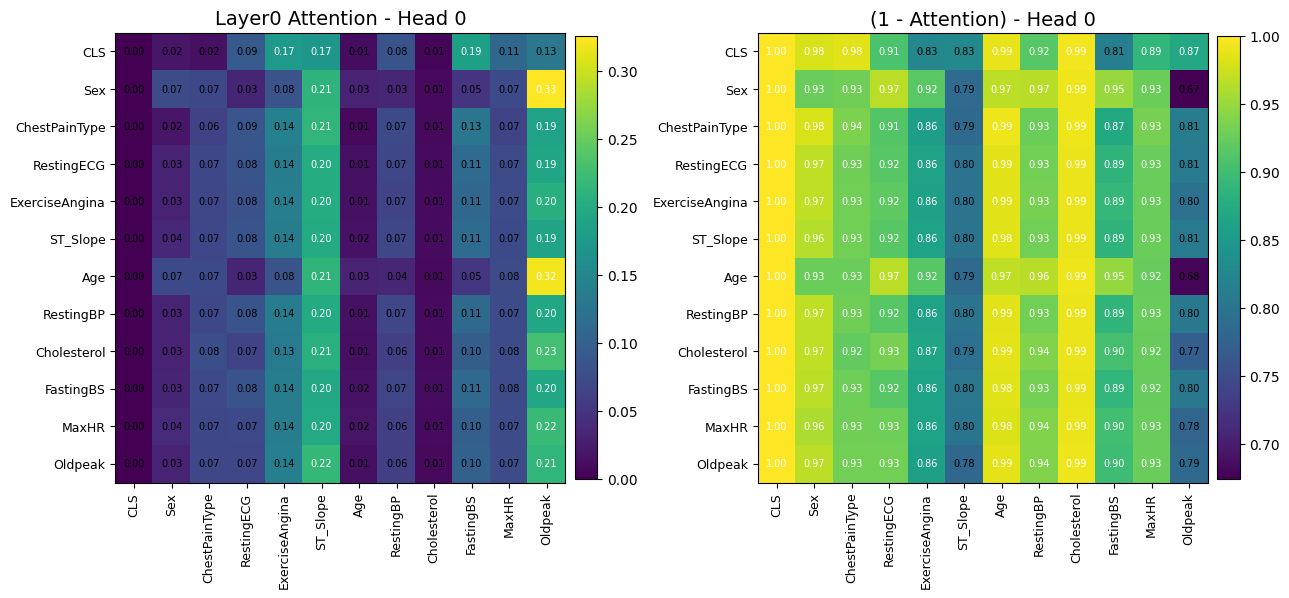

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=0.0085 | std=0.1320
            Sex  | mean=0.0721 | std=2.5919
  ChestPainType  | mean=0.0768 | std=2.6088
     RestingECG  | mean=0.0595 | std=2.3827
 ExerciseAngina  | mean=0.0868 | std=2.7405
       ST_Slope  | mean=0.0699 | std=2.5756
            Age  | mean=-0.0019 | std=0.5382
      RestingBP  | mean=0.4499 | std=10.0962
    Cholesterol  | mean=-0.3215 | std=8.3556
      FastingBS  | mean=0.4935 | std=10.8011
          MaxHR  | mean=-0.1245 | std=3.0025
        Oldpeak  | mean=0.0697 | std=1.3618

=== Global embedding statistics ===
global mean: 0.0782
global std : 5.2714


In [5]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



### Affinity Two sample

In [6]:
import numpy as np
from collections import defaultdict
@torch.no_grad()
def collect_all_samples_from_source(model, loader, source_name):
    """
    한 source의 모든 샘플에 대해 node embedding과 affinity 추출
    
    Returns:
        all_embeddings: list of [N, D] arrays (CLS 제외한 variable nodes만)
        all_affinities: list of [N, N] arrays (1 - attention, Var-Var만)
        all_labels: list of labels
        all_feature_names: list of feature name lists
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []
    
    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        
        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None
        
        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            
            # attention shape: [B, H, T, T]
            last_att = att
            
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B, H, T, T]
        # Head 0 사용
        last_att = last_att[:, 0, :, :]  # [B, T, T]
        
        # Feature names
        var_names = extract_feature_names(batch)
        
        for b in range(B):
            # CLS 제외 (1:부터)
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N, D]
            
            # Var-Var attention만 (CLS 제외)
            var_att = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N, N]
            
            # 1 - attention = distance/affinity
            affinity = 1.0 - var_att
            
            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(batch['y'][b].item())
            all_feature_names.append(var_names)
    
    return all_embeddings, all_affinities, all_labels, all_feature_names

def compute_frobenius_distances(embeddings, affinities):
    """
    모든 샘플 쌍의 Frobenius distance 계산
    
    Returns:
        emb_distances: [n_samples, n_samples] embedding Frobenius distances
        aff_distances: [n_samples, n_samples] affinity Frobenius distances
    """
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            # Embedding Frobenius distance
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff
            
            # Affinity Frobenius distance
            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff
    
    return emb_distances, aff_distances

def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    """
    Reference 샘플과 같은/다른 레이블 내에서 가장 유사/상이한 샘플 찾기
    
    Returns:
        most_similar_same_label_idx: 같은 레이블 중 가장 유사
        most_different_other_label_idx: 다른 레이블 중 가장 상이
    """
    n = len(distances)
    ref_label = labels[reference_idx]
    
    # 같은 레이블 샘플들
    same_label_mask = np.array([labels[i] == ref_label for i in range(n)])
    same_label_mask[reference_idx] = False  # 자기자신 제외
    
    # 다른 레이블 샘플들
    other_label_mask = np.array([labels[i] != ref_label for i in range(n)])
    
    # 같은 레이블 중 가장 유사 (거리 최소)
    dist_same_label = distances[reference_idx].copy()
    dist_same_label[~same_label_mask] = np.inf
    most_similar_same_label_idx = np.argmin(dist_same_label)
    
    # 다른 레이블 중 가장 상이 (거리 최대)
    dist_other_label = distances[reference_idx].copy()
    dist_other_label[~other_label_mask] = -np.inf
    most_different_other_label_idx = np.argmax(dist_other_label)
    
    return most_similar_same_label_idx, most_different_other_label_idx

In [7]:
# 1. 데이터 수집
src = sources[1]  # 첫 번째 source
loader = loaders[src]

print(f"Collecting samples from source: {src}")
embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(model, loader, src)

print(f"Total samples collected: {len(embeddings)}")
print(f"Node embedding shape: {embeddings[0].shape}")
print(f"Affinity shape: {affinities[0].shape}")

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)


In [8]:
# 2. Frobenius distance 계산
print("Computing Frobenius distances...")
emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

print(f"Embedding distance matrix shape: {emb_distances.shape}")
print(f"Affinity distance matrix shape: {aff_distances.shape}")

Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)


In [9]:
# 3. Reference 샘플 선택 (예: 첫 번째 샘플)
reference_idx = 0

# Affinity 기준으로 같은 레이블에서 가장 유사, 다른 레이블에서 가장 상이한 샘플 찾기
similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, aff_distances, labels)

print(f"\n=== Analysis based on Affinity Frobenius Distance (Label-aware) ===")
print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")


=== Analysis based on Affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 1)

Most similar (SAME label): 389 (label: 1)
  → Affinity Frobenius distance: 0.1661

Most different (OTHER label): 475 (label: 0)
  → Affinity Frobenius distance: 1.6337



=== Reference Sample Affinity ===


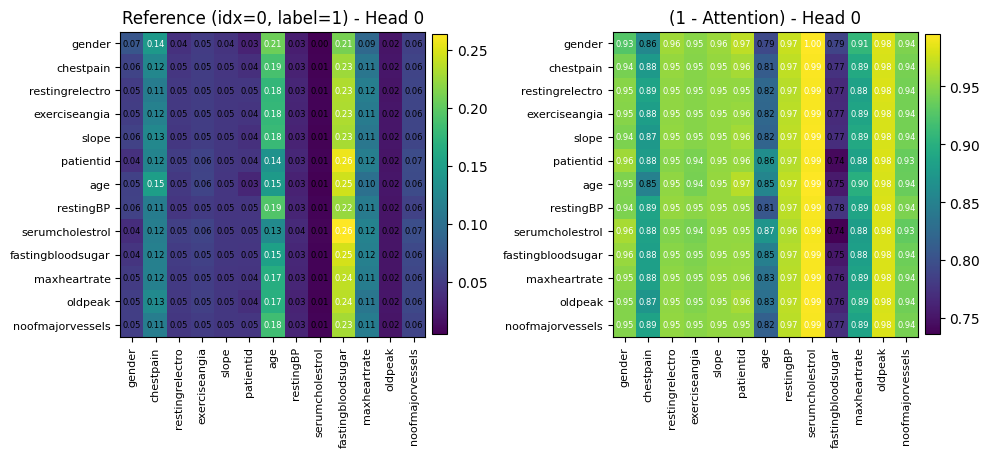


=== Most Similar Sample (SAME Label) Affinity ===
Frobenius distance: 0.1661


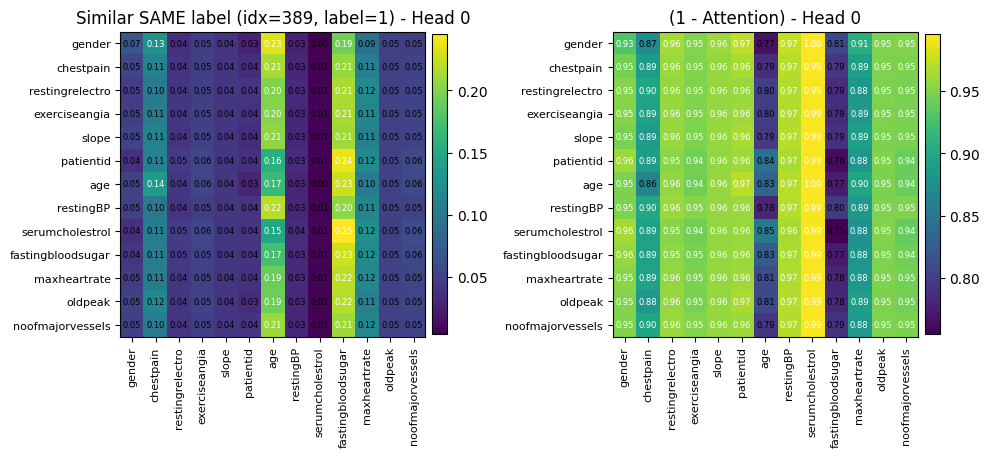


=== Most Different Sample (OTHER Label) Affinity ===
Frobenius distance: 1.6337


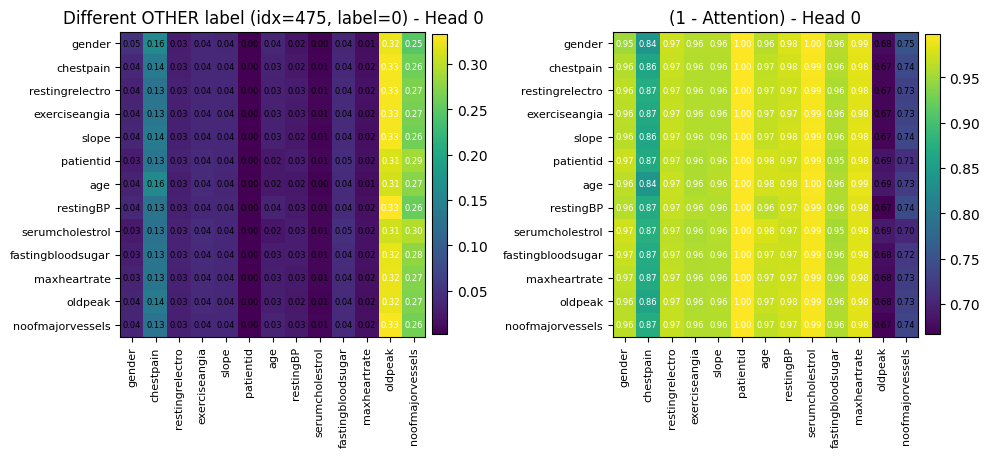

In [10]:
# 4. 시각화
feature_names = ["CLS"] + feature_names_list[0]
var_names = feature_names_list[0]

# Reference 샘플 affinity
ref_aff = affinities[reference_idx]
# Most similar (same label) 샘플 affinity
sim_aff = affinities[similar_idx]
# Most different (other label) 샘플 affinity
diff_aff = affinities[different_idx]

# 3D attention shape로 변환 (plot 함수 호환)
ref_aff_3d = ref_aff[np.newaxis, :, :]  # [1, N, N]
sim_aff_3d = sim_aff[np.newaxis, :, :]
diff_aff_3d = diff_aff[np.newaxis, :, :]

print("\n=== Reference Sample Affinity ===")
plot_attention_with_inverse(
    att=1.0 - ref_aff_3d,  # affinity를 다시 attention으로
    feature_names=var_names,
    title=f"Reference (idx={reference_idx}, label={labels[reference_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Similar Sample (SAME Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - sim_aff_3d,
    feature_names=var_names,
    title=f"Similar SAME label (idx={similar_idx}, label={labels[similar_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Different Sample (OTHER Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - diff_aff_3d,
    feature_names=var_names,
    title=f"Different OTHER label (idx={different_idx}, label={labels[different_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

In [11]:
# Joint 모델 로드


joint_ckpt_pretrain = torch.load(joint_ckpt_pretrain_path, map_location=device)
joint_args = joint_ckpt_pretrain['args']

# Joint 모델 초기화
joint_model_pretrain = Model(
    joint_args,
    joint_args.input_dim,
    joint_args.hidden_dim,
    joint_args.output_dim,
    joint_args.dropout_rate,
    joint_args.llm_model,
    experiment_id="joint_viz",
    mode="Full"
).to(device)

joint_sd = joint_ckpt_pretrain['model_state_dict']
missing, unexpected = joint_model_pretrain.load_state_dict(joint_sd, strict=False)
print("Joint Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

joint_model_pretrain.eval()

Joint Model Loaded
Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=192, bias=True)
    (k_proj): Linear(in_features=768, out_features=192, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.2, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_

In [12]:
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities):
    """
    3개 샘플 (ref, similar, different) x 8개 LCG = 24개 Transport Plan 계산
    
    Args:
        model: Joint trained model
        sample_indices: [ref_idx, similar_idx, different_idx]
        embeddings: list of node embeddings
        affinities: list of affinity matrices
    
    Returns:
        plans: [3, 8, N, K] Transport Plans
        distances: [3, 8] FGW distances
        coordinates: [3, 8] Soft assignments (pi)
    """
    # LCG 가져오기
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    n_samples = len(sample_indices)
    
    # 결과 저장
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        # Source 준비
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)  # [1, N, D]
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)   # [1, N, N]
        
        N = src_feat.shape[1]
        
        # Expand for M LCGs
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)  # [M, N, D]
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)    # [M, N, N]
        
        # LCG 준비
        lcg_feat_exp = lcg_feat  # [M, K, D]
        lcg_str_exp = lcg_struct  # [M, K, K]
        
        # FGW 계산 (GraphQuantizer의 compute_fgw 재현)
        dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = model.graph_quantizer.alpha
        reg = model.graph_quantizer.reg
        
        # Solve FGW
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach().cpu().numpy()  # [M]
        plans = result.plan.detach().cpu().numpy()       # [M, N, K]
        
        # Soft assignment (pi)
        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]
        
        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)
    
    all_plans = np.array(all_plans)           # [3, M, N, K]
    all_distances = np.array(all_distances)   # [3, M]
    all_coordinates = np.array(all_coordinates)  # [3, M]
    
    return all_plans, all_distances, all_coordinates

In [13]:
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    """
    3 x 8 Grid로 Transport Plan 시각화
    + 각 LCG별로 Reference vs Similar, Reference vs Different의 Frobenius norm 표시
    
    Args:
        plans: [3, 8, N, K]
        coordinates: [3, 8] (pi values)
        distances: [3, 8] (FGW distances)
        sample_indices: [ref_idx, similar_idx, different_idx]
        labels: list of all labels
        var_names: list of variable names
    """
    n_samples = 3
    n_lcgs = 8
    
    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    
    # 각 LCG별 Frobenius norm 계산
    frob_norms_similar = []  # Reference vs Similar
    frob_norms_different = []  # Reference vs Different
    
    for j in range(n_lcgs):
        plan_ref = plans[0, j]      # Reference
        plan_sim = plans[1, j]      # Similar
        plan_diff = plans[2, j]     # Different
        
        frob_ref_sim = np.linalg.norm(plan_ref - plan_sim, ord='fro')
        frob_ref_diff = np.linalg.norm(plan_ref - plan_diff, ord='fro')
        
        frob_norms_similar.append(frob_ref_sim)
        frob_norms_different.append(frob_ref_diff)
    
    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            
            plan = plans[i, j]  # [N, K]
            pi = coordinates[i, j]
            dist = distances[i, j]
            
            # Heatmap
            im = ax.imshow(plan, cmap='viridis', aspect='auto')
            
            # Title
            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)
            
            # Y-axis (Source variables)
            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})', 
                             fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])
            
            # X-axis (LCG nodes)
            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])
            
            # Frobenius norm 표시 (Different row의 맨 아래)
            if i == n_samples - 1:
                frob_sim = frob_norms_similar[j]
                frob_diff = frob_norms_different[j]
                
                # X-axis label 아래에 Frobenius norm 추가
                ax.text(0.5, -0.5, f'Frob: Sim={frob_sim:.3f} vs Diff={frob_diff:.3f}',
                       transform=ax.transAxes,
                       ha='center', va='top',
                       fontsize=10, color='red',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            
            # Colorbar
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)  # Frobenius norm 텍스트 공간 확보
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)', 
                 fontsize=14, y=0.99)
    plt.show()

In [14]:
# 실행
print("Computing Transport Plans for 3 samples x 8 LCGs...")
sample_indices = [reference_idx, similar_idx, different_idx]

plans, distances, coordinates = compute_transport_plans_for_samples(
    joint_model_pretrain, sample_indices, embeddings, affinities
)

print(f"Plans shape: {plans.shape}")  # [3, 8, N, K]
print(f"Distances shape: {distances.shape}")  # [3, 8]
print(f"Coordinates shape: {coordinates.shape}")  # [3, 8]

print("\n=== Coordinates (pi) ===")
print("Reference:", coordinates[0])
print("Similar:", coordinates[1])
print("Different:", coordinates[2])

print("\n=== FGW Distances ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

Computing Transport Plans for 3 samples x 8 LCGs...
Plans shape: (3, 8, 13, 8)
Distances shape: (3, 8)
Coordinates shape: (3, 8)

=== Coordinates (pi) ===
Reference: [0.13284145 0.14203598 0.12168868 0.07598499 0.1058449  0.12807724
 0.14147305 0.1520537 ]
Similar: [0.13374019 0.14274882 0.12217722 0.07657571 0.1041666  0.1266397
 0.14239775 0.15155399]
Different: [0.13247027 0.13613923 0.12719218 0.09321026 0.11333766 0.131265
 0.13777474 0.12861064]

=== FGW Distances ===
Reference: [0.27621728 0.2748788  0.2779711  0.2873897  0.2807609  0.27694774
 0.27495822 0.27351573]
Similar: [0.30260548 0.30130172 0.304414   0.31375787 0.30760363 0.30369654
 0.30135098 0.30010462]
Different: [0.286279   0.2857326  0.28709218 0.293309   0.28939873 0.2864618
 0.28549376 0.28687036]


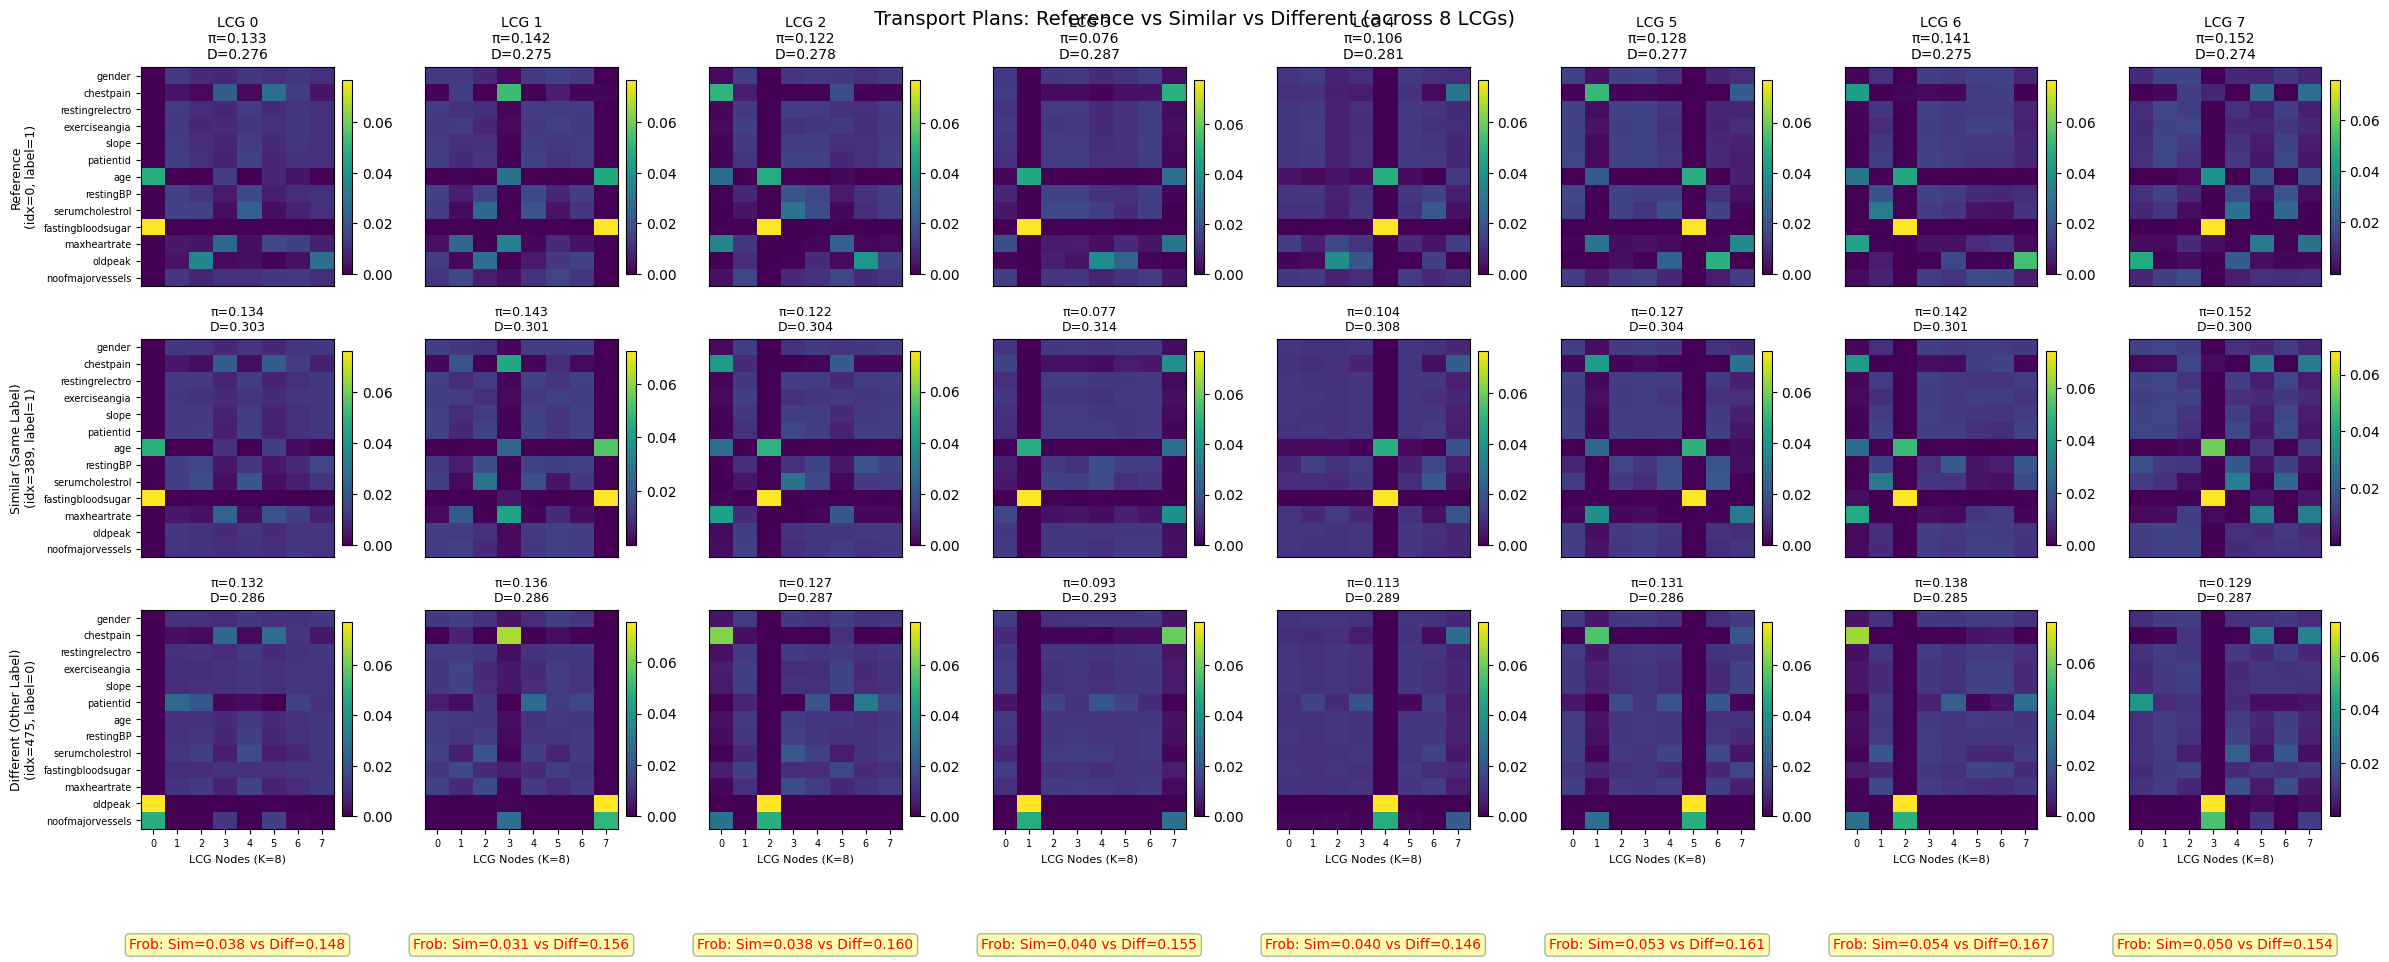

In [15]:
# 시각화
plot_transport_plans_grid(
    plans, coordinates, distances, 
    sample_indices, labels, var_names
)

In [16]:
# Pi (coordinates) 출력
print("=== Pi (Soft Assignment Probabilities) ===")
print("\nReference sample (idx={}, label={}):".format(reference_idx, labels[reference_idx]))
print(coordinates[0])
print(f"Sum: {coordinates[0].sum():.6f}")
print(f"Max: {coordinates[0].max():.4f}, Min: {coordinates[0].min():.4f}")
print(f"Std: {coordinates[0].std():.6f}")

print("\nSimilar sample (idx={}, label={}):".format(similar_idx, labels[similar_idx]))
print(coordinates[1])
print(f"Sum: {coordinates[1].sum():.6f}")
print(f"Max: {coordinates[1].max():.4f}, Min: {coordinates[1].min():.4f}")
print(f"Std: {coordinates[1].std():.6f}")

print("\nDifferent sample (idx={}, label={}):".format(different_idx, labels[different_idx]))
print(coordinates[2])
print(f"Sum: {coordinates[2].sum():.6f}")
print(f"Max: {coordinates[2].max():.4f}, Min: {coordinates[2].min():.4f}")
print(f"Std: {coordinates[2].std():.6f}")

print("\n=== Pi Comparison ===")
print("Reference vs Similar - Frobenius: {:.6f}".format(
    np.linalg.norm(coordinates[0] - coordinates[1])
))
print("Reference vs Different - Frobenius: {:.6f}".format(
    np.linalg.norm(coordinates[0] - coordinates[2])
))

# Raw distances (softmax 전)
print("\n=== Raw FGW Distances (before softmax) ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

print("\n=== Distance Comparison ===")
print("Reference vs Similar - Frobenius: {:.6f}".format(
    np.linalg.norm(distances[0] - distances[1])
))
print("Reference vs Different - Frobenius: {:.6f}".format(
    np.linalg.norm(distances[0] - distances[2])
))

=== Pi (Soft Assignment Probabilities) ===

Reference sample (idx=0, label=1):
[0.13284145 0.14203598 0.12168868 0.07598499 0.1058449  0.12807724
 0.14147305 0.1520537 ]
Sum: 1.000000
Max: 0.1521, Min: 0.0760
Std: 0.022762

Similar sample (idx=389, label=1):
[0.13374019 0.14274882 0.12217722 0.07657571 0.1041666  0.1266397
 0.14239775 0.15155399]
Sum: 1.000000
Max: 0.1516, Min: 0.0766
Std: 0.022882

Different sample (idx=475, label=0):
[0.13247027 0.13613923 0.12719218 0.09321026 0.11333766 0.131265
 0.13777474 0.12861064]
Sum: 1.000000
Max: 0.1378, Min: 0.0932
Std: 0.013905

=== Pi Comparison ===
Reference vs Similar - Frobenius: 0.002809
Reference vs Different - Frobenius: 0.031488

=== Raw FGW Distances (before softmax) ===
Reference: [0.27621728 0.2748788  0.2779711  0.2873897  0.2807609  0.27694774
 0.27495822 0.27351573]
Similar: [0.30260548 0.30130172 0.304414   0.31375787 0.30760363 0.30369654
 0.30135098 0.30010462]
Different: [0.286279   0.2857326  0.28709218 0.293309   0.289

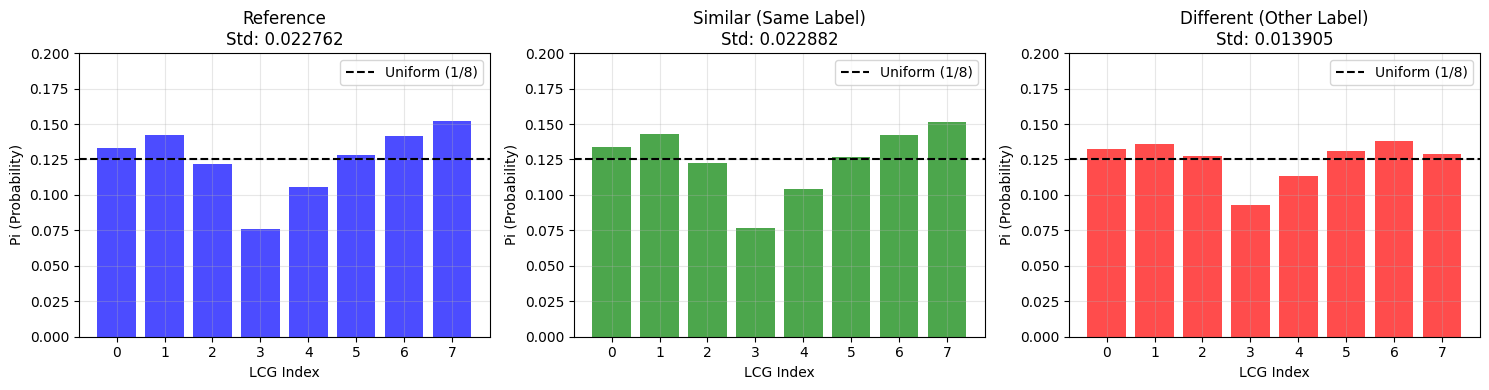

In [17]:
# 시각화: Pi 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

@torch.no_grad()
def collect_all_source_assignments(model, loaders, sources, device):
    """
    모든 source의 모든 샘플에 대해 LCG assignment 수집
    
    Returns:
        assignments: [N_total] - 각 샘플이 어느 LCG node에 할당되었는지
        source_labels: [N_total] - 각 샘플이 어느 source에서 왔는지
    """
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    all_assignments = []
    all_source_labels = []
    
    for src_idx, src in enumerate(sources):
        loader = loaders[src]
        
        for batch in loader:
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                    for k, v in batch.items()}
            
            # desc/name/value gather
            desc_embeddings, name_embeddings, value_embeddings = [], [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                desc_embeddings.append(batch['cat_desc_embeddings'])
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                desc_embeddings.append(batch['num_desc_embeddings'])
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name = torch.cat(name_embeddings, dim=1)
            value = torch.cat(value_embeddings, dim=1)
            
            B = value.size(0)
            N = value.size(1)

            # CLS + value
            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

            # GAT forward
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            # Source features (CLS 제외)
            src_feat = x_basis[:, 1:, :]  # [B, N, D]
            
            # Affinity (Var-Var, CLS 제외)
            src_str = 1.0 - last_att[:, 0, 1:, 1:]  # [B, N, N]
            
            # Expand for M LCGs
            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
            
            # FGW 계산
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            tau = model.graph_quantizer.tau
            M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
            
            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            
            alpha = model.graph_quantizer.alpha
            reg = model.graph_quantizer.reg
            
            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
                a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
            )
            
            # Transport Plan: [B*M, N, K] → [B, M, N, K]
            plan = result.plan.reshape(B, M, N, K)
            
            # 각 샘플의 각 node가 어느 LCG node에 가장 많이 할당되었는지
            # Plan shape: [B, M, N, K]
            # Max over (M, K) → 어느 (LCG, Node)에 가장 많이?
            plan_flat = plan.reshape(B, M*K, N)  # [B, M*K, N]
            
            for b in range(B):
                for n in range(N):
                    # 이 node의 transport plan: [M*K]
                    transport = plan_flat[b, :, n].detach().cpu().numpy()
                    
                    # 가장 높은 할당을 받은 (LCG, Node)
                    best_idx = np.argmax(transport)
                    
                    all_assignments.append(best_idx)
                    all_source_labels.append(src_idx)
    
    return np.array(all_assignments), np.array(all_source_labels)

In [19]:
def plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8):
    """
    Argmax 기반 codebook usage 시각화
    
    Args:
        assignments: [N_total] - LCG*K index (0~63)
        source_labels: [N_total] - source index (0~3)
        sources: list of source names
        M: number of LCGs
        K: number of nodes per LCG
    """
    # 무지개 색상 (8개 LCG)
    colors = plt.cm.rainbow(np.linspace(0, 1, M))
    
    # LCG별, Node별 카운트
    counts = np.zeros((M, K))
    
    for assignment in assignments:
        lcg_idx = assignment // K
        node_idx = assignment % K
        if lcg_idx < M and node_idx < K:
            counts[lcg_idx, node_idx] += 1
    
    # Plot
    fig, ax = plt.subplots(figsize=(18, 6))
    
    x_positions = []
    bar_colors = []
    bar_heights = []
    
    current_x = 0
    for m in range(M):
        for k in range(K):
            x_positions.append(current_x)
            bar_colors.append(colors[m])
            bar_heights.append(counts[m, k])
            current_x += 1
    
    bars = ax.bar(x_positions, bar_heights, color=bar_colors, edgecolor='black', linewidth=0.5)
    
    # X-axis labels
    ax.set_xlabel('LCG Node Index (Color=Graph ID)', fontsize=14)
    ax.set_ylabel('Selection Count', fontsize=14)
    ax.set_title('Best Init: Codebook Usage (Count of Argmax)', fontsize=16)
    
    # X-ticks
    ax.set_xticks(range(0, M*K, 5))
    ax.set_xticklabels(range(0, M*K, 5))
    
    # Grid
    ax.grid(axis='y', alpha=0.3)
    
    # LCG 경계선
    for m in range(1, M):
        ax.axvline(x=m*K - 0.5, color='black', linewidth=2, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\n=== Codebook Usage Statistics (Argmax) ===")
    total_assignments = len(assignments)
    print(f"Total assignments: {total_assignments}")
    
    for m in range(M):
        lcg_count = counts[m].sum()
        print(f"LCG {m}: {int(lcg_count):5d} ({lcg_count/total_assignments*100:.1f}%)")
        
        # 가장 많이 사용된 node
        max_node = np.argmax(counts[m])
        max_count = counts[m, max_node]
        print(f"  → Most used node: {max_node} ({int(max_count)} times)")

Total samples collected: 40556
Assignment range: [0, 63]


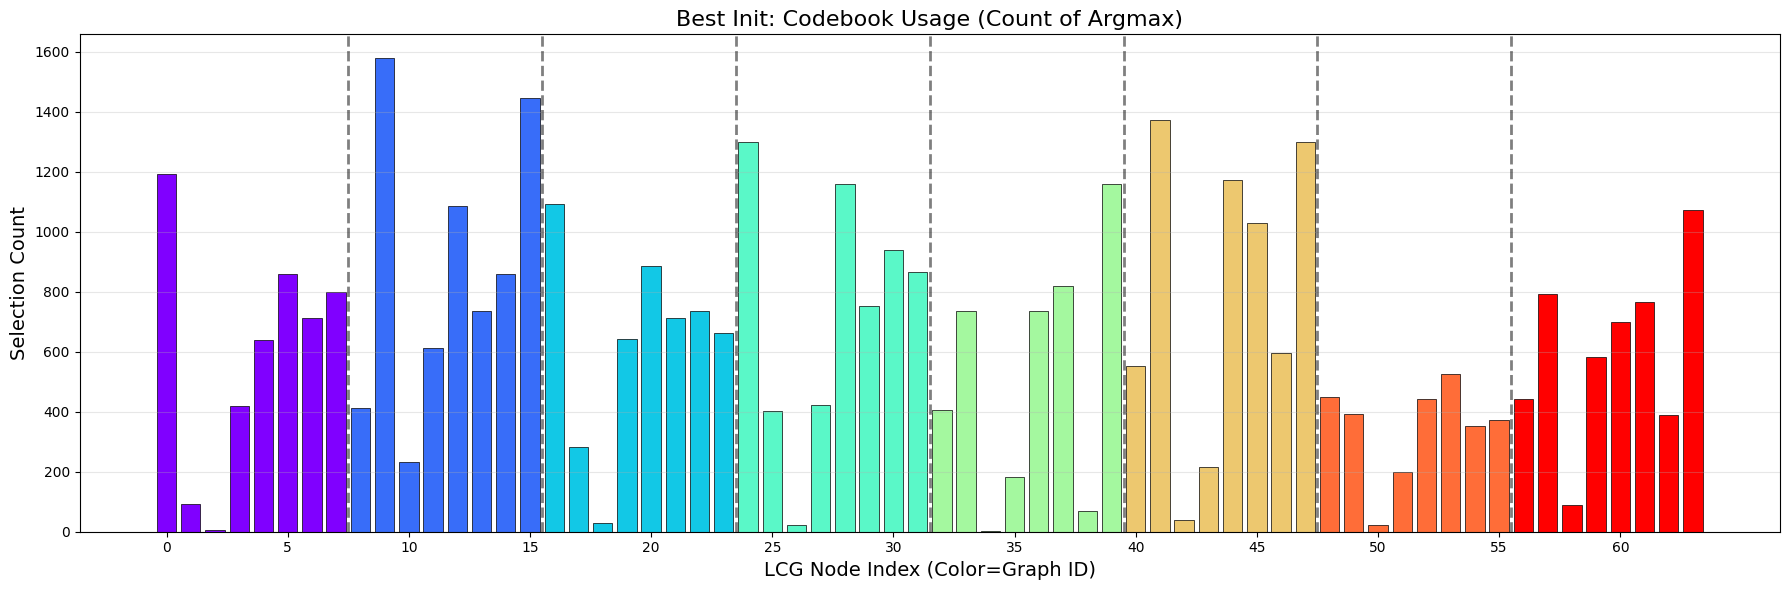


=== Codebook Usage Statistics (Argmax) ===
Total assignments: 40556
LCG 0:  4716 (11.6%)
  → Most used node: 0 (1192 times)
LCG 1:  6960 (17.2%)
  → Most used node: 1 (1579 times)
LCG 2:  5040 (12.4%)
  → Most used node: 0 (1092 times)
LCG 3:  5865 (14.5%)
  → Most used node: 0 (1298 times)
LCG 4:  4111 (10.1%)
  → Most used node: 7 (1160 times)
LCG 5:  6275 (15.5%)
  → Most used node: 1 (1373 times)
LCG 6:  2757 (6.8%)
  → Most used node: 5 (526 times)
LCG 7:  4832 (11.9%)
  → Most used node: 7 (1074 times)


In [20]:
# 실행
print("Collecting assignments from all sources...")
assignments, source_labels = collect_all_source_assignments(
    joint_model_pretrain, loaders, sources, device
)

print(f"Total samples collected: {len(assignments)}")
print(f"Assignment range: [{assignments.min()}, {assignments.max()}]")

# 시각화
plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8)

## coordinates

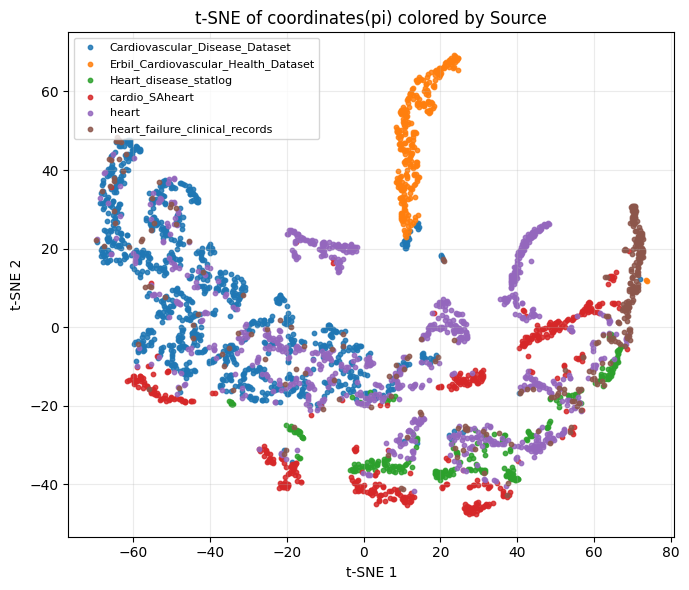

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

@torch.no_grad()
def collect_all_coordinates(model, loaders, device):
    model.eval()
    coords, labels, sources = [], [], []

    for src_name, loader in loaders.items():
        for batch in loader:
            batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            # LCG 경로를 타면서 pi 계산되게
            _ = model.predict(batch, return_all=True)

            pi = model.graph_quantizer.last_pi  # [B, M]
            if pi is None:
                raise RuntimeError("last_pi가 None임. use_lcg=True인지 확인해.")

            coords.append(pi.detach().cpu().numpy())
            sources.extend([src_name] * pi.shape[0])

            if "y" in batch:
                labels.extend(batch["y"].detach().cpu().numpy().reshape(-1).tolist())
            else:
                labels.extend([-1] * pi.shape[0])

    coords = np.concatenate(coords, axis=0)  # [N_total, M]
    labels = np.array(labels)
    sources = np.array(sources, dtype=object)
    return coords, labels, sources


# 1) collect
coords, labels, sources = collect_all_coordinates(model, loaders, device)
N = coords.shape[0]

# 2) t-SNE
perp = max(5, min(30, (N - 1) // 3))
tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=42)
xy = tsne.fit_transform(coords)  # [N,2]

# 3) plot: color by SOURCE (no KMeans)
uniq_sources = sorted(list(set(sources.tolist())))

plt.figure(figsize=(7, 6))
for s in uniq_sources:
    mask = (sources == s)
    plt.scatter(
        xy[mask, 0], xy[mask, 1],
        s=10, alpha=0.85, label=str(s)
    )

plt.title("t-SNE of coordinates(pi) colored by Source")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, frameon=True, loc="best")
plt.tight_layout()
plt.show()


[heart] collected: N=918, M=8, labels=Counter({1: 508, 0: 410})


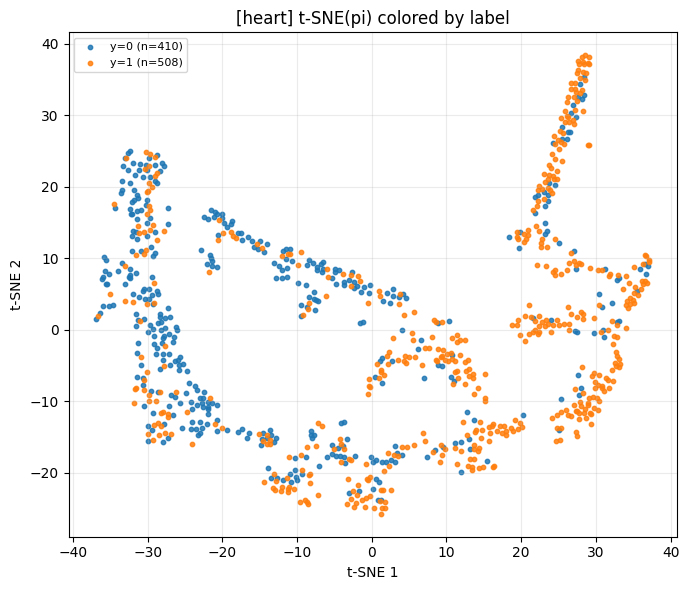

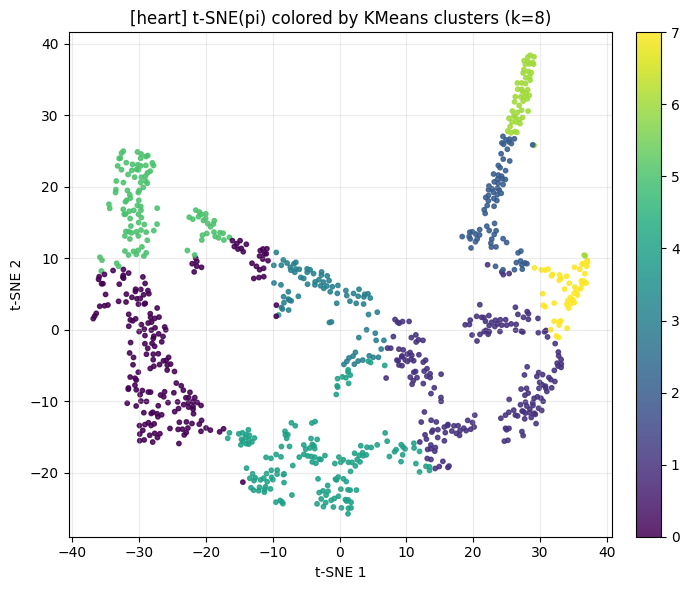


[Cluster x Label counts]
cluster | y=0 | y=1 | total
---------------------------
      0 |   147 |    46 |   193
      1 |    27 |   172 |   199
      2 |    21 |    54 |    75
      3 |    50 |    30 |    80
      4 |    64 |    97 |   161
      5 |    77 |    33 |   110
      6 |    11 |    41 |    52
      7 |    13 |    35 |    48


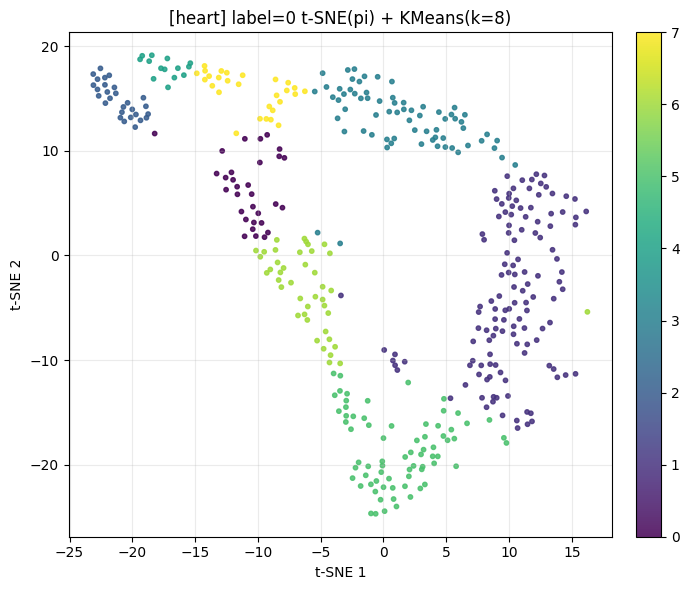


[label=0] farthest centroids: (4, 5), L2=0.059356


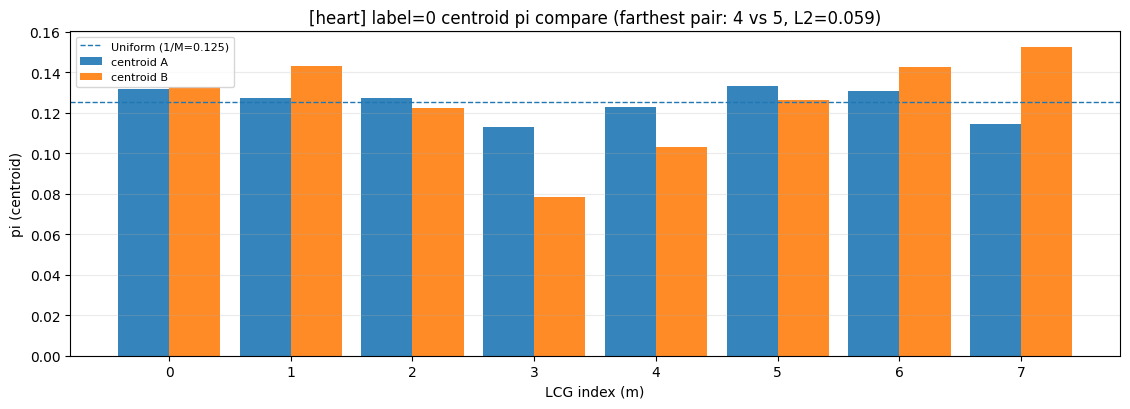

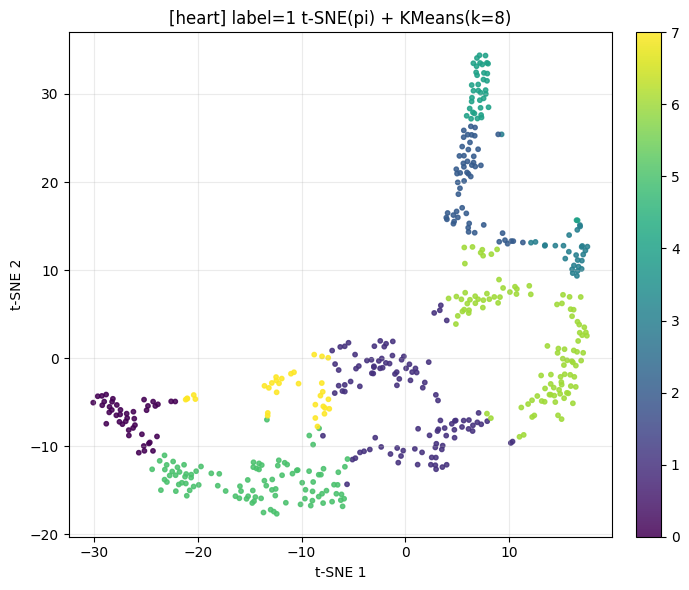


[label=1] farthest centroids: (0, 4), L2=0.069653


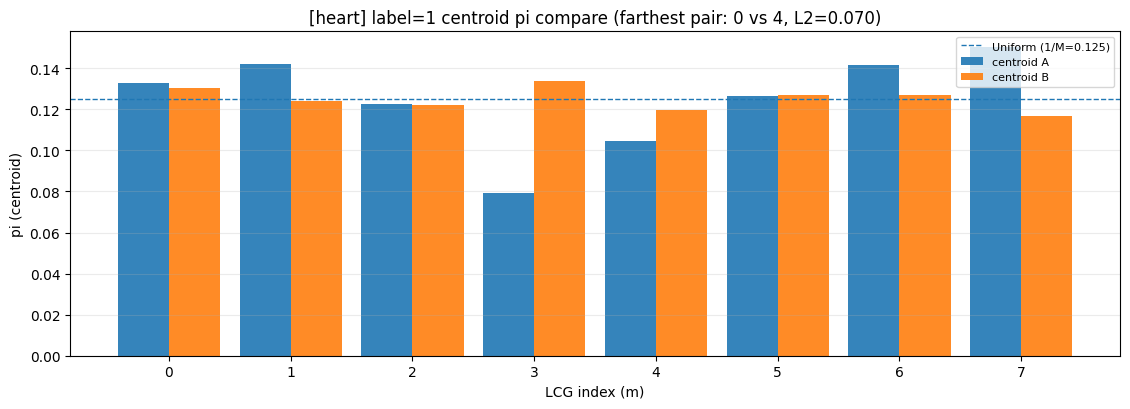

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from collections import Counter

# -----------------------------
# 0) Collect pi for ONE source
# -----------------------------
@torch.no_grad()
def collect_pi_for_one_source(model, loader, device):
    model.eval()
    pis, ys = [], []
    for batch in loader:
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        _ = model.predict(batch, return_all=True)  # last_pi 계산
        pi = model.graph_quantizer.last_pi
        if pi is None:
            raise RuntimeError("last_pi is None. use_lcg=True / predict 경로 확인.")
        pis.append(pi.detach().cpu().numpy())
        ys.append(batch["y"].detach().cpu().numpy().reshape(-1).astype(int))
    pi_all = np.concatenate(pis, axis=0)  # [N, M]
    y_all  = np.concatenate(ys, axis=0)   # [N]
    return pi_all, y_all


# -----------------------------
# 1) t-SNE helper
# -----------------------------
def tsne_2d(X, seed=42):
    N = X.shape[0]
    perp = max(5, min(30, (N - 1) // 3))  # 안전
    tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=seed)
    return tsne.fit_transform(X)


# -----------------------------
# 2) Plot helpers
# -----------------------------
def plot_tsne_by_label(xy, y, title):
    plt.figure(figsize=(7, 6))
    for lab in sorted(set(y.tolist())):
        idx = np.where(y == lab)[0]
        plt.scatter(xy[idx, 0], xy[idx, 1], s=10, alpha=0.85, label=f"y={lab} (n={len(idx)})")
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8, frameon=True, loc="best")
    plt.tight_layout()
    plt.show()

def plot_tsne_by_cluster(xy, cid, title):
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(xy[:, 0], xy[:, 1], c=cid, s=10, alpha=0.85)
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.colorbar(sc, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def print_cluster_label_table(cid, y):
    # cluster x label count 출력
    clusters = sorted(set(cid.tolist()))
    labels   = sorted(set(y.tolist()))
    table = {c: {lab: 0 for lab in labels} for c in clusters}
    for c, lab in zip(cid, y):
        table[int(c)][int(lab)] += 1

    print("\n[Cluster x Label counts]")
    header = "cluster | " + " | ".join([f"y={lab}" for lab in labels]) + " | total"
    print(header)
    print("-" * len(header))
    for c in clusters:
        row = [table[c][lab] for lab in labels]
        print(f"{c:>7} | " + " | ".join([f"{v:>5}" for v in row]) + f" | {sum(row):>5}")

def farthest_centroid_pair(centroids):
    K = centroids.shape[0]
    dmat = np.linalg.norm(centroids[:, None, :] - centroids[None, :, :], axis=2)
    np.fill_diagonal(dmat, -np.inf)
    a, b = np.unravel_index(np.argmax(dmat), dmat.shape)
    return int(a), int(b), float(dmat[a, b])

def plot_centroid_pi_compare(cA, cB, title):
    cA = np.asarray(cA); cB = np.asarray(cB)
    M = cA.shape[0]
    x = np.arange(M)
    w = 0.42
    uniform = 1.0 / M

    plt.figure(figsize=(max(9, 0.8*M + 5), 4.2))
    plt.bar(x - w/2, cA, width=w, label="centroid A", alpha=0.9)
    plt.bar(x + w/2, cB, width=w, label="centroid B", alpha=0.9)
    plt.axhline(uniform, linestyle="--", linewidth=1, label=f"Uniform (1/M={uniform:.3f})")
    plt.xticks(x, [str(i) for i in x])
    plt.xlabel("LCG index (m)")
    plt.ylabel("pi (centroid)")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(fontsize=8, frameon=True, loc="best")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 3) Main routine (Medicaldataset only)
# -----------------------------
source_name = "heart"  # <- 너가 말한 걸로 고정
loader = loaders[source_name]

# (A) collect
pi_all, y_all = collect_pi_for_one_source(model, loader, device)
N, M = pi_all.shape
print(f"[{source_name}] collected: N={N}, M={M}, labels={Counter(y_all.tolist())}")

# (1) 전체 pi로 clustering + label로 어떻게 보이는지
k_all = min(8, N)  # 일단 8, 샘플 적으면 자동 축소
km_all = KMeans(n_clusters=k_all, random_state=42, n_init=20)
cid_all = km_all.fit_predict(pi_all)

xy_all = tsne_2d(pi_all, seed=42)
plot_tsne_by_label(xy_all, y_all, title=f"[{source_name}] t-SNE(pi) colored by label")
plot_tsne_by_cluster(xy_all, cid_all, title=f"[{source_name}] t-SNE(pi) colored by KMeans clusters (k={k_all})")
print_cluster_label_table(cid_all, y_all)

# (2) label 내부에서 clustering + centroid 비교
def within_label_clustering_and_compare(pi_all, y_all, lab, k=8):
    idx = np.where(y_all == lab)[0]
    X = pi_all[idx]
    n = X.shape[0]
    if n < 2:
        print(f"\n[label={lab}] samples too few: n={n}")
        return
    k_lab = min(k, n)  # 샘플 수보다 클러스터 많으면 안됨
    if k_lab < 2:
        print(f"\n[label={lab}] clusters too few: k={k_lab}")
        return

    km = KMeans(n_clusters=k_lab, random_state=42, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_  # [k_lab, M]

    # label 내부 t-SNE (cluster로 색)
    xy = tsne_2d(X, seed=42)
    plot_tsne_by_cluster(xy, cid, title=f"[{source_name}] label={lab} t-SNE(pi) + KMeans(k={k_lab})")

    # (2-1/2-2) farthest centroid pair 비교
    a, b, dist = farthest_centroid_pair(C)
    print(f"\n[label={lab}] farthest centroids: ({a}, {b}), L2={dist:.6f}")
    plot_centroid_pi_compare(
        C[a], C[b],
        title=f"[{source_name}] label={lab} centroid pi compare (farthest pair: {a} vs {b}, L2={dist:.3f})"
    )

# label 0
within_label_clustering_and_compare(pi_all, y_all, lab=0, k=8)
# label 1
within_label_clustering_and_compare(pi_all, y_all, lab=1, k=8)


In [23]:
import numpy as np
import torch
import pandas as pd
from sklearn.cluster import KMeans

@torch.no_grad()
def collect_coords_one_source(model, loader, device):
    model.eval()
    coords = []
    ys = []

    for batch in loader:
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        # pi 계산되게 (use_lcg=True여야 last_pi가 채워짐)
        _ = model.predict(batch, return_all=True)

        pi = model.graph_quantizer.last_pi  # [B, M]
        if pi is None:
            raise RuntimeError("last_pi가 None임. args.use_lcg=True인지, model.predict가 LCG 경로 타는지 확인.")

        coords.append(pi.detach().cpu().numpy())

        if "y" not in batch:
            raise RuntimeError("batch에 'y'가 없음.")
        ys.append(batch["y"].detach().cpu().numpy().reshape(-1))

    coords = np.concatenate(coords, axis=0)  # [N, M]
    ys = np.concatenate(ys, axis=0).astype(int)  # [N]
    return coords, ys


def kmeans_purity_table(coords, ys, k=8, seed=42):
    """
    coords: [N, M] (pi)
    ys: [N] (0/1)
    """
    km = KMeans(n_clusters=k, random_state=seed, n_init=20)
    cid = km.fit_predict(coords)

    # cluster x label count
    ct = pd.crosstab(cid, ys)  # rows=cluster, cols=label
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[[0, 1]]

    n = ct.sum(axis=1)
    p1 = (ct[1] / n).fillna(0.0)
    p0 = (ct[0] / n).fillna(0.0)
    purity = np.maximum(p0, p1)
    majority = np.where(p1 >= 0.5, 1, 0)

    summary = pd.DataFrame({
        "cluster": ct.index.astype(int),
        "n": n.values.astype(int),
        "y=0": ct[0].values.astype(int),
        "y=1": ct[1].values.astype(int),
        "p(y=1)": p1.values,
        "purity": purity.values,
        "majority_label": majority,
    }).sort_values("cluster").reset_index(drop=True)

    # 비율표(클러스터 내부에서 label 비율)
    ratio = ct.div(ct.sum(axis=1), axis=0).fillna(0.0)
    ratio.columns = [f"p(y={c})" for c in ratio.columns]
    ratio = ratio.reset_index().rename(columns={"row_0": "cluster", "index": "cluster"})

    return summary, ratio, ct


@torch.no_grad()
def run_sourcewise_purity(model, loaders, device, k=8, seed=42):
    out = {}
    for src_name, loader in loaders.items():
        coords, ys = collect_coords_one_source(model, loader, device)

        summary, ratio, ct = kmeans_purity_table(coords, ys, k=k, seed=seed)

        base_p1 = ys.mean()
        print(f"\n=== [{src_name}] ===")
        print(f"N={len(ys)} | base p(y=1)={base_p1:.4f} | KMeans(k={k}) on pi")
        print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
        print("\n[cluster-wise label ratio]")
        print(ratio.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        out[src_name] = {
            "coords": coords,
            "ys": ys,
            "summary": summary,
            "ratio": ratio,
            "count_table": ct
        }
    return out


# ---- 실행 예시 ----
# k=8은 너 LCG 개수(M)랑 맞추는 게 보통 자연스러움
results = run_sourcewise_purity(model, loaders, device, k=8, seed=42)



=== [heart] ===
N=918 | base p(y=1)=0.5534 | KMeans(k=8) on pi
 cluster   n  y=0  y=1  p(y=1)  purity  majority_label
       0 193  147   46  0.2383  0.7617               0
       1 199   27  172  0.8643  0.8643               1
       2  75   21   54  0.7200  0.7200               1
       3  80   50   30  0.3750  0.6250               0
       4 161   64   97  0.6025  0.6025               1
       5 110   77   33  0.3000  0.7000               0
       6  52   11   41  0.7885  0.7885               1
       7  48   13   35  0.7292  0.7292               1

[cluster-wise label ratio]
 cluster  p(y=0)  p(y=1)
       0  0.7617  0.2383
       1  0.1357  0.8643
       2  0.2800  0.7200
       3  0.6250  0.3750
       4  0.3975  0.6025
       5  0.7000  0.3000
       6  0.2115  0.7885
       7  0.2708  0.7292

=== [Cardiovascular_Disease_Dataset] ===
N=1000 | base p(y=1)=0.5800 | KMeans(k=8) on pi
 cluster   n  y=0  y=1  p(y=1)  purity  majority_label
       0 118   17  101  0.8559  0.8559     

Using source: heart


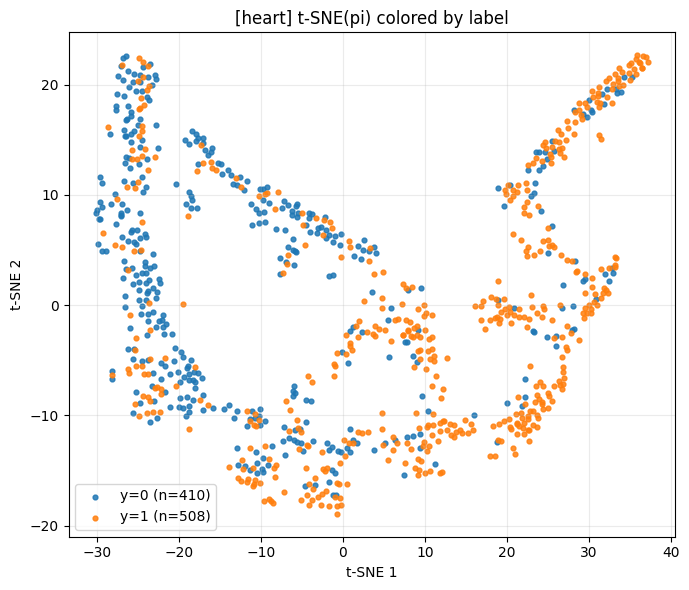

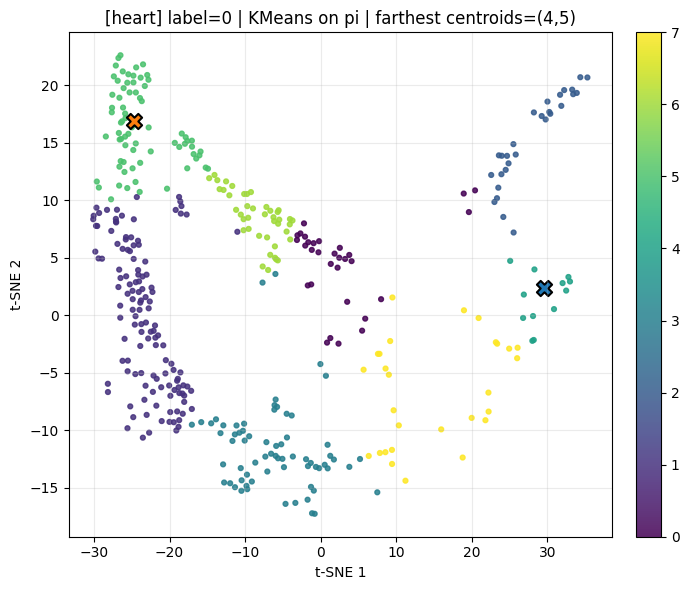

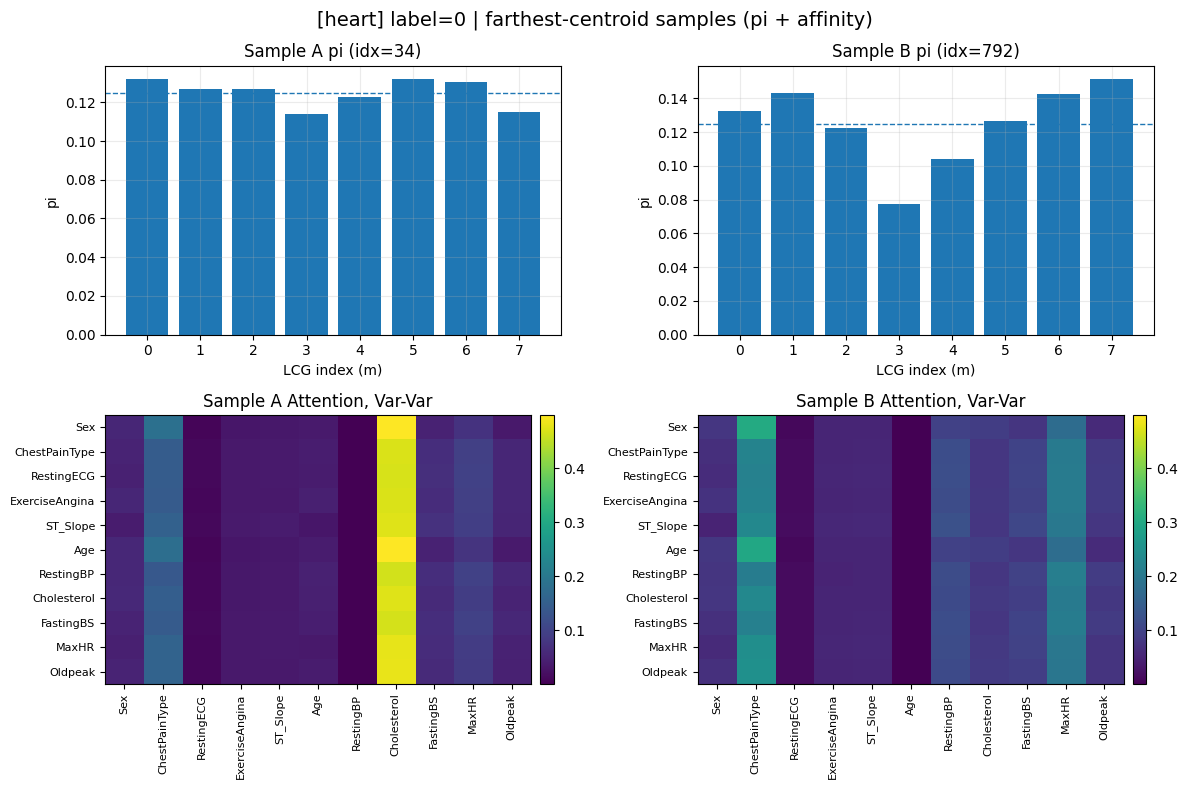

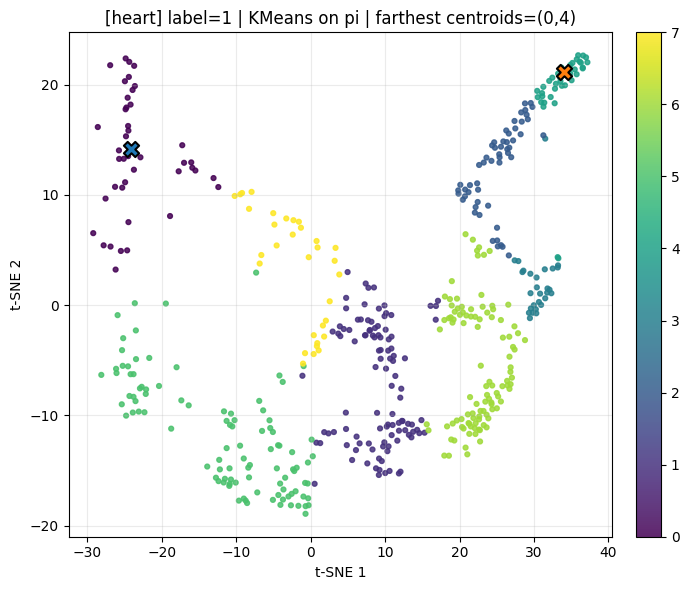

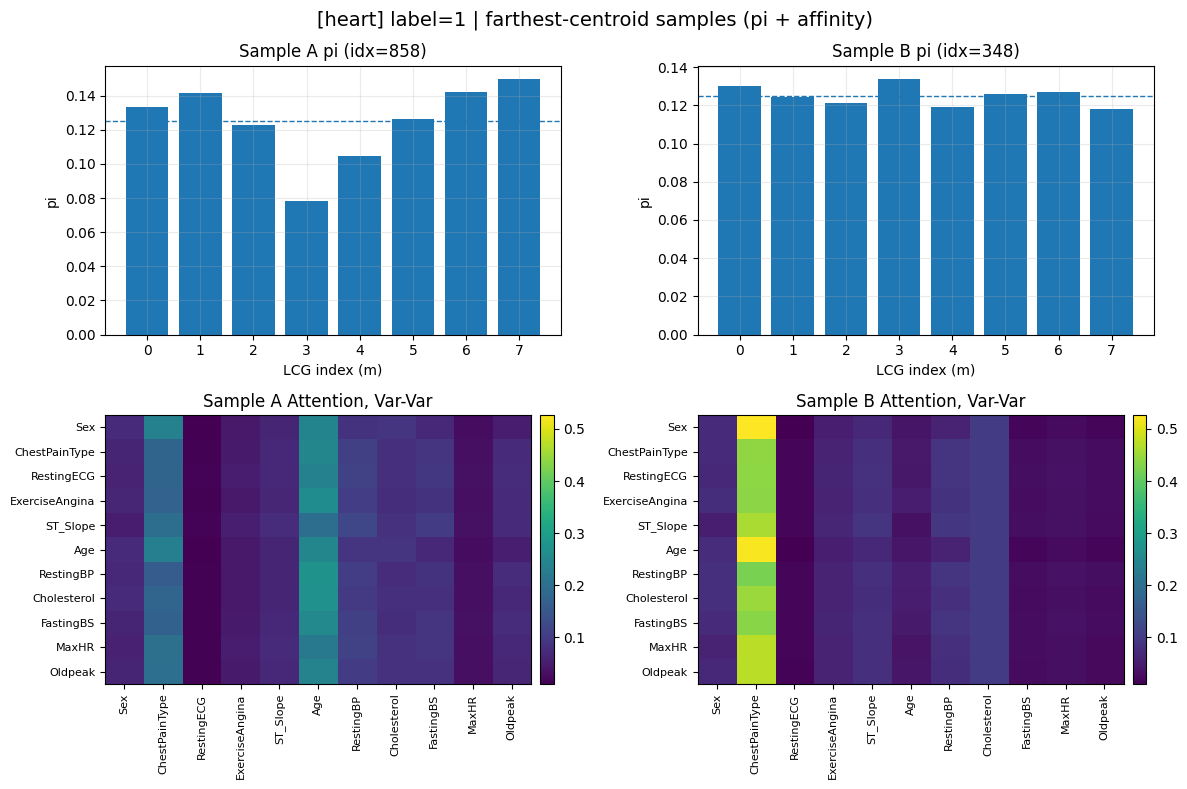

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ----------------------------
# 0) Medicaldataset loader 찾기
# ----------------------------
def get_loader_by_key(loaders, key="heart"):
    for k in loaders.keys():
        if str(k).lower() == str(key).lower():
            return k, loaders[k]
    # fallback: 부분매칭
    for k in loaders.keys():
        if str(key).lower() in str(k).lower():
            return k, loaders[k]
    raise KeyError(f"'{key}' loader not found. available={list(loaders.keys())}")

# ------------------------------------------------------
# 1) Medicaldataset 전체에서 pi + affinity(= _last_P_basis) 수집
# ------------------------------------------------------
@torch.no_grad()
def collect_pi_and_affinity_for_one_source(model, loader, device):
    model.eval()
    pis = []
    ys = []
    affs = []
    names = []

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        _ = model.predict(batch_t, return_all=True)

        pi = model.graph_quantizer.last_pi          # [B, M]
        P_1matt  = model._last_P_basis              # [B, N, N]  == (1 - att)

        if pi is None or P_1matt is None:
            raise RuntimeError("pi 또는 _last_P_basis가 None. args.use_lcg=True인지 확인.")

        # >>> 여기 핵심: attention 자체로 변환
        att = 1.0 - P_1matt
        att = torch.clamp(att, 0.0, 1.0)  # 혹시 수치 튀면 안정화

        var_names = extract_feature_names(batch)

        B = pi.shape[0]
        for b in range(B):
            pis.append(pi[b].detach().cpu().numpy())              # [M]
            ys.append(int(batch_t["y"][b].item()))
            affs.append(att[b].detach().cpu().numpy())            # [N,N]  <-- 이제 att 저장
            names.append(var_names)

    pis = np.stack(pis, axis=0)
    ys  = np.array(ys, dtype=int)
    return pis, ys, affs, names

# ------------------------------------------------------
# 2) label 내부 KMeans + "가장 먼 centroid 2개" + 대표 샘플 선택
# ------------------------------------------------------
def kmeans_farthest_centroids_pick_samples(pis, ys, label, k=8, seed=42):
    idx = np.where(ys == label)[0]
    if len(idx) < 2:
        raise ValueError(f"label={label} samples too few: {len(idx)}")

    X = pis[idx]  # [n_lab, M]
    k_eff = min(k, len(idx))
    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_  # [k_eff, M]

    # centroid pairwise distance -> farthest pair
    dist = np.linalg.norm(C[:, None, :] - C[None, :, :], axis=-1)  # [k,k]
    np.fill_diagonal(dist, -np.inf)
    a, b = np.unravel_index(np.argmax(dist), dist.shape)

    # 각 centroid에 가장 가까운 "원 샘플" 1개씩
    def pick_nearest(centroid):
        d = np.linalg.norm(X - centroid[None, :], axis=1)
        return idx[int(np.argmin(d))]

    samp_a = pick_nearest(C[a])
    samp_b = pick_nearest(C[b])

    return {
        "idx_lab": idx,          # label subset indices (global)
        "X_lab": X,              # pi subset
        "cid": cid,              # cluster id per subset sample
        "km": km,
        "centroid_pair": (a, b),
        "sample_pair": (samp_a, samp_b),  # global sample indices
    }

# ------------------------------------------------------
# 3) Plot: (i) label별 전체 tSNE, (ii) label 내부 cluster tSNE, (iii) 대표 2샘플 비교(pi+aff)
# ------------------------------------------------------
def plot_tsne_by_label(pis, ys, title_prefix="[heart]", seed=42):
    N = pis.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=seed).fit_transform(pis)

    plt.figure(figsize=(7, 6))
    for lab in [0, 1]:
        m = (ys == lab)
        plt.scatter(xy[m, 0], xy[m, 1], s=12, alpha=0.85, label=f"y={lab} (n={m.sum()})")
    plt.title(f"{title_prefix} t-SNE(pi) colored by label")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()
    return xy

def plot_label_clusters_and_pick(xy_all, result, ys, label, title_prefix="[heart]"):
    idx = result["idx_lab"]
    cid = result["cid"]
    samp_a, samp_b = result["sample_pair"]

    xy = xy_all[idx]  # subset coords in tSNE space

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(xy[:, 0], xy[:, 1], c=cid, s=12, alpha=0.85)
    # highlight picked samples
    ia = np.where(idx == samp_a)[0][0]
    ib = np.where(idx == samp_b)[0][0]
    plt.scatter(xy[ia, 0], xy[ia, 1], s=120, marker="X", edgecolors="black", linewidths=1.5)
    plt.scatter(xy[ib, 0], xy[ib, 1], s=120, marker="X", edgecolors="black", linewidths=1.5)

    a, b = result["centroid_pair"]
    plt.title(f"{title_prefix} label={label} | KMeans on pi | farthest centroids=({a},{b})")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.colorbar(sc, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def plot_two_samples_pi_and_affinity(pis, affs, names, samp_a, samp_b, title):
    pi_a = pis[samp_a]
    pi_b = pis[samp_b]
    A_a  = affs[samp_a]
    A_b  = affs[samp_b]

    M = pi_a.shape[0]
    uniform = 1.0 / M

    # affinity color scale 통일
    vmin = min(A_a.min(), A_b.min())
    vmax = max(A_a.max(), A_b.max())

    # var names (y축 라벨용)
    var_names_a = names[samp_a]
    var_names_b = names[samp_b]
    # 보통 동일하겠지만, 혹시 달라도 각자 사용
    N_a = A_a.shape[0]
    N_b = A_b.shape[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # (1) pi bars
    ax = axes[0, 0]
    ax.bar(np.arange(M), pi_a)
    ax.axhline(uniform, linestyle="--", linewidth=1)
    ax.set_title(f"Sample A pi (idx={samp_a})")
    ax.set_xlabel("LCG index (m)"); ax.set_ylabel("pi")
    ax.grid(True, alpha=0.25)

    ax = axes[0, 1]
    ax.bar(np.arange(M), pi_b)
    ax.axhline(uniform, linestyle="--", linewidth=1)
    ax.set_title(f"Sample B pi (idx={samp_b})")
    ax.set_xlabel("LCG index (m)"); ax.set_ylabel("pi")
    ax.grid(True, alpha=0.25)

    # (2) affinity heatmaps (Var-Var)
    ax = axes[1, 0]
    im1 = ax.imshow(A_a, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title("Sample A Attention, Var-Var")
    ax.set_xticks(range(N_a)); ax.set_yticks(range(N_a))
    ax.set_xticklabels(var_names_a, rotation=90, fontsize=8)
    ax.set_yticklabels(var_names_a, fontsize=8)
    fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.02)

    ax = axes[1, 1]
    im2 = ax.imshow(A_b, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title("Sample B Attention, Var-Var")
    ax.set_xticks(range(N_b)); ax.set_yticks(range(N_b))
    ax.set_xticklabels(var_names_b, rotation=90, fontsize=8)
    ax.set_yticklabels(var_names_b, fontsize=8)
    fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.02)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# ============================
# RUN (Medicaldataset only)
# ============================
src_key, medical_loader = get_loader_by_key(loaders, "heart")
print("Using source:", src_key)

pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, medical_loader, device)

# (A) 전체: tSNE(pi) colored by label
xy_all = plot_tsne_by_label(pis, ys, title_prefix=f"[{src_key}]")

# (B)(C) label 내부: KMeans(pi) + farthest centroid pair 비교
for lab in [0, 1]:
    res = kmeans_farthest_centroids_pick_samples(pis, ys, label=lab, k=8, seed=42)
    plot_label_clusters_and_pick(xy_all, res, ys, label=lab, title_prefix=f"[{src_key}]")

    samp_a, samp_b = res["sample_pair"]
    plot_two_samples_pi_and_affinity(
        pis, affs, names,
        samp_a, samp_b,
        title=f"[{src_key}] label={lab} | farthest-centroid samples (pi + affinity)"
    )


Using source: heart


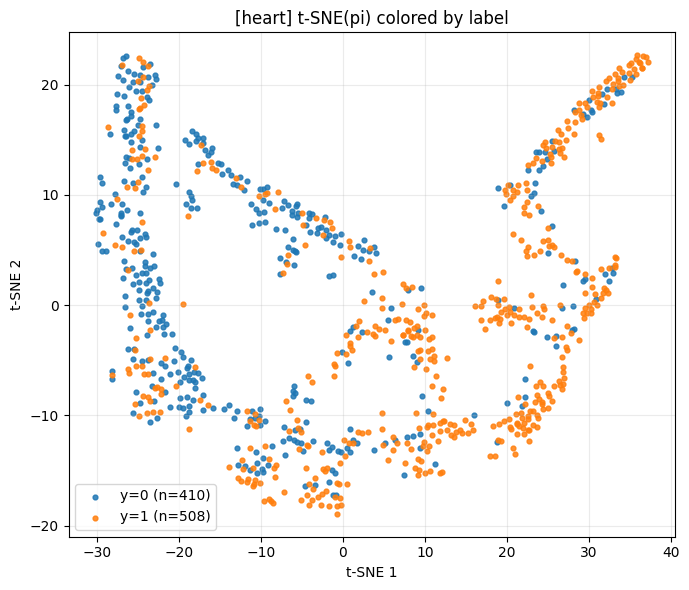

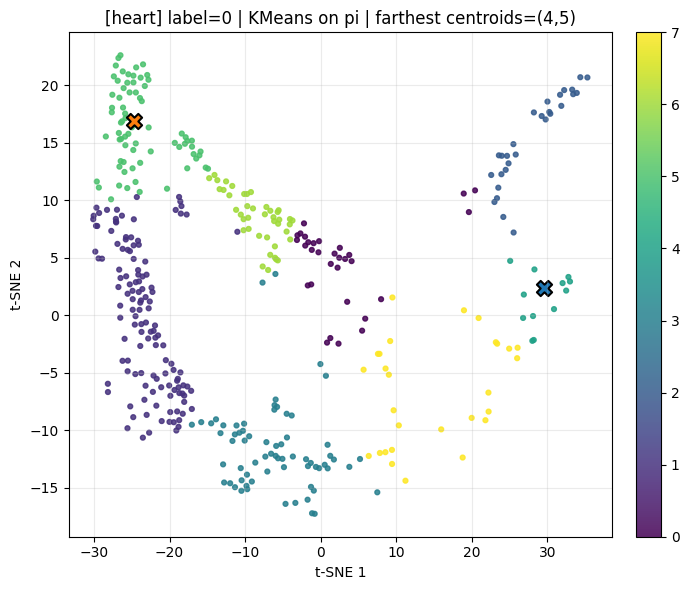

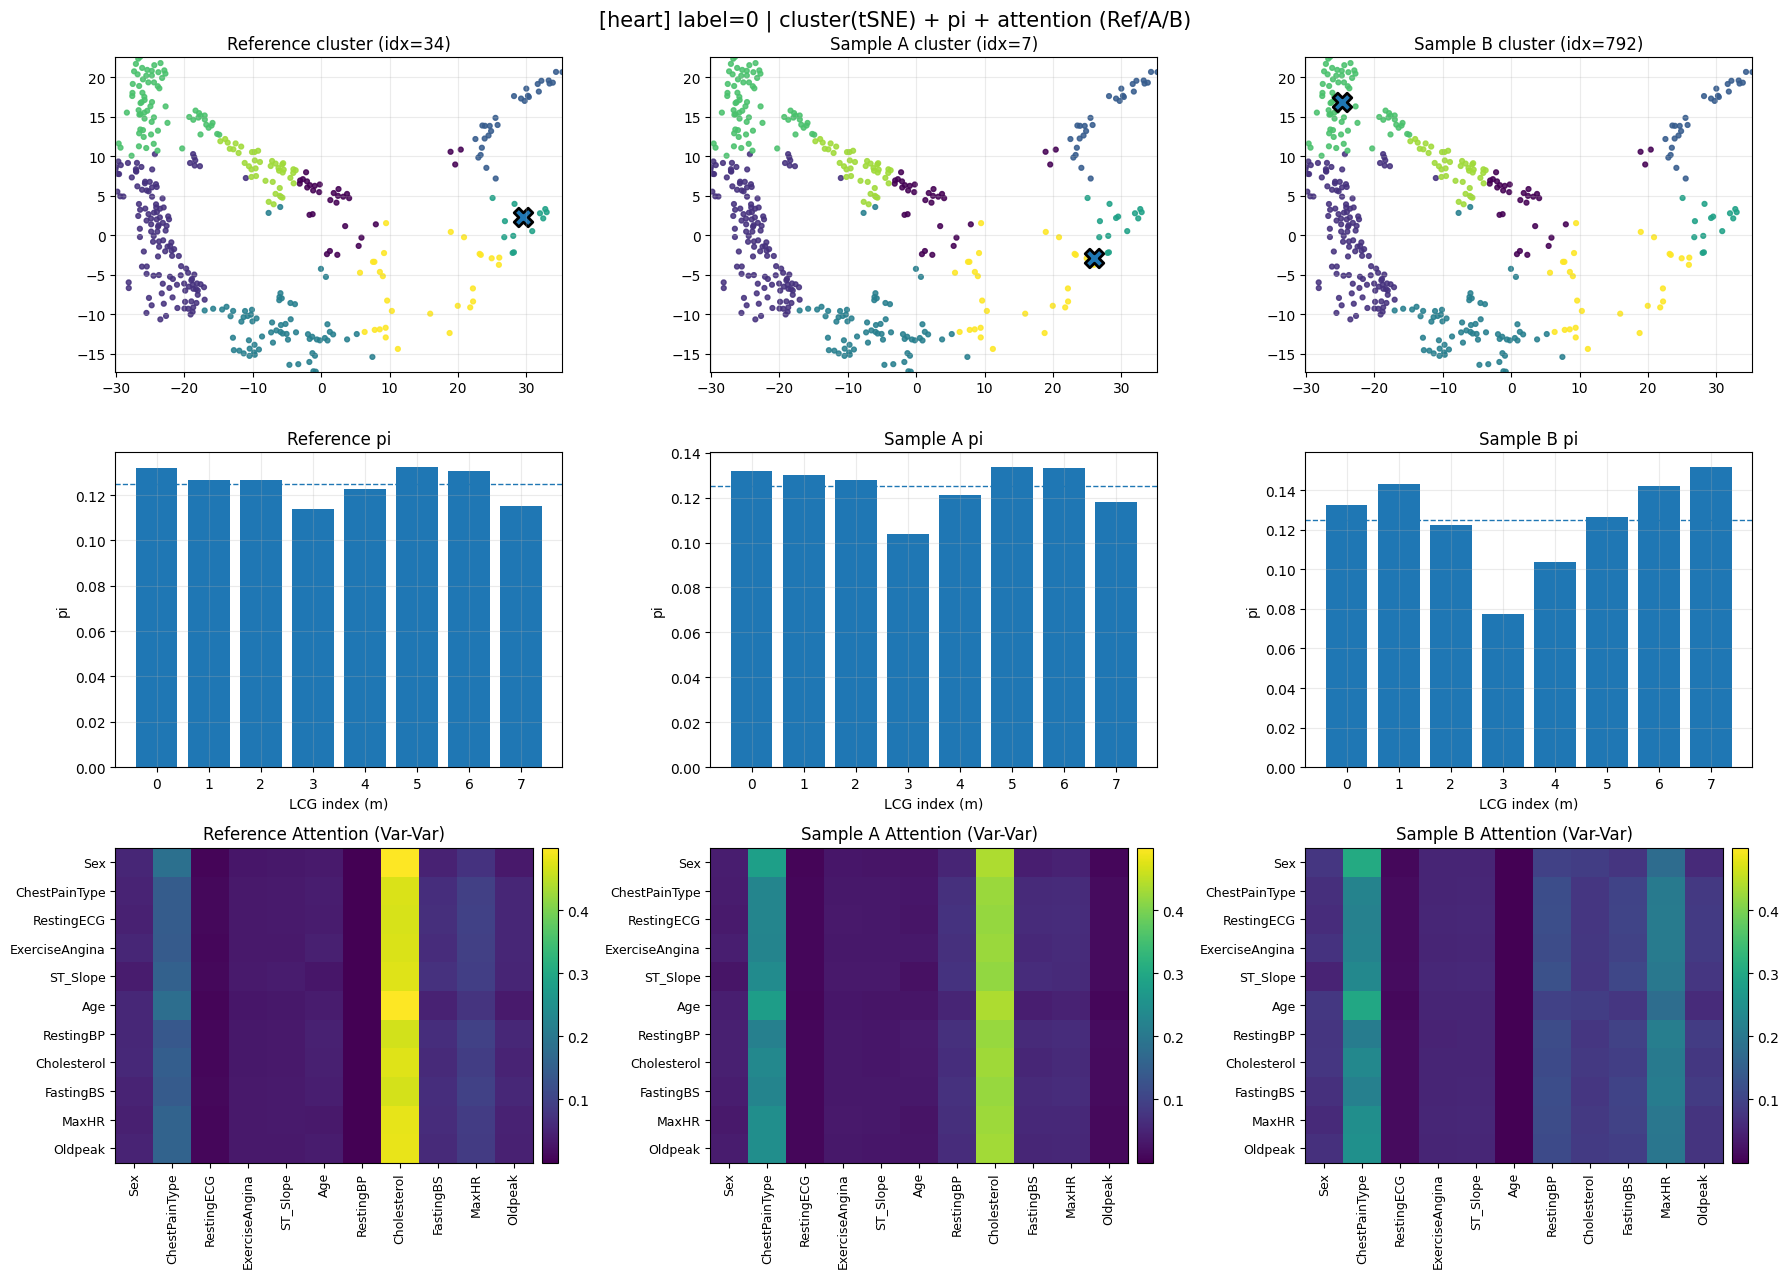

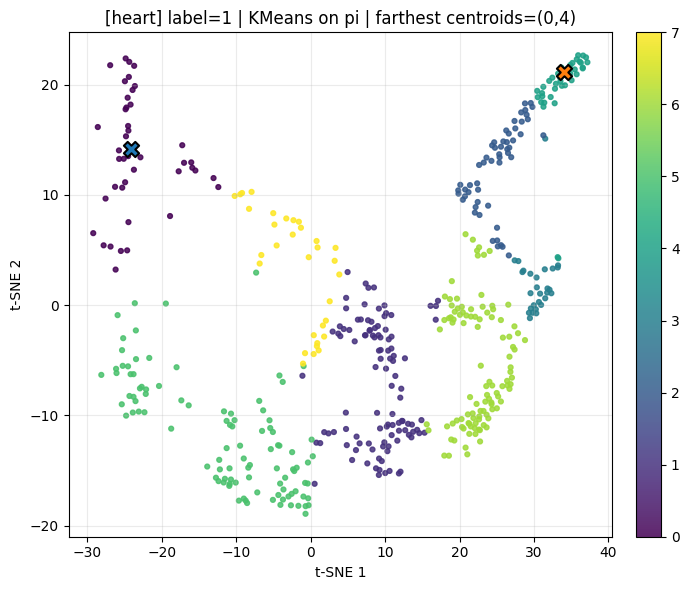

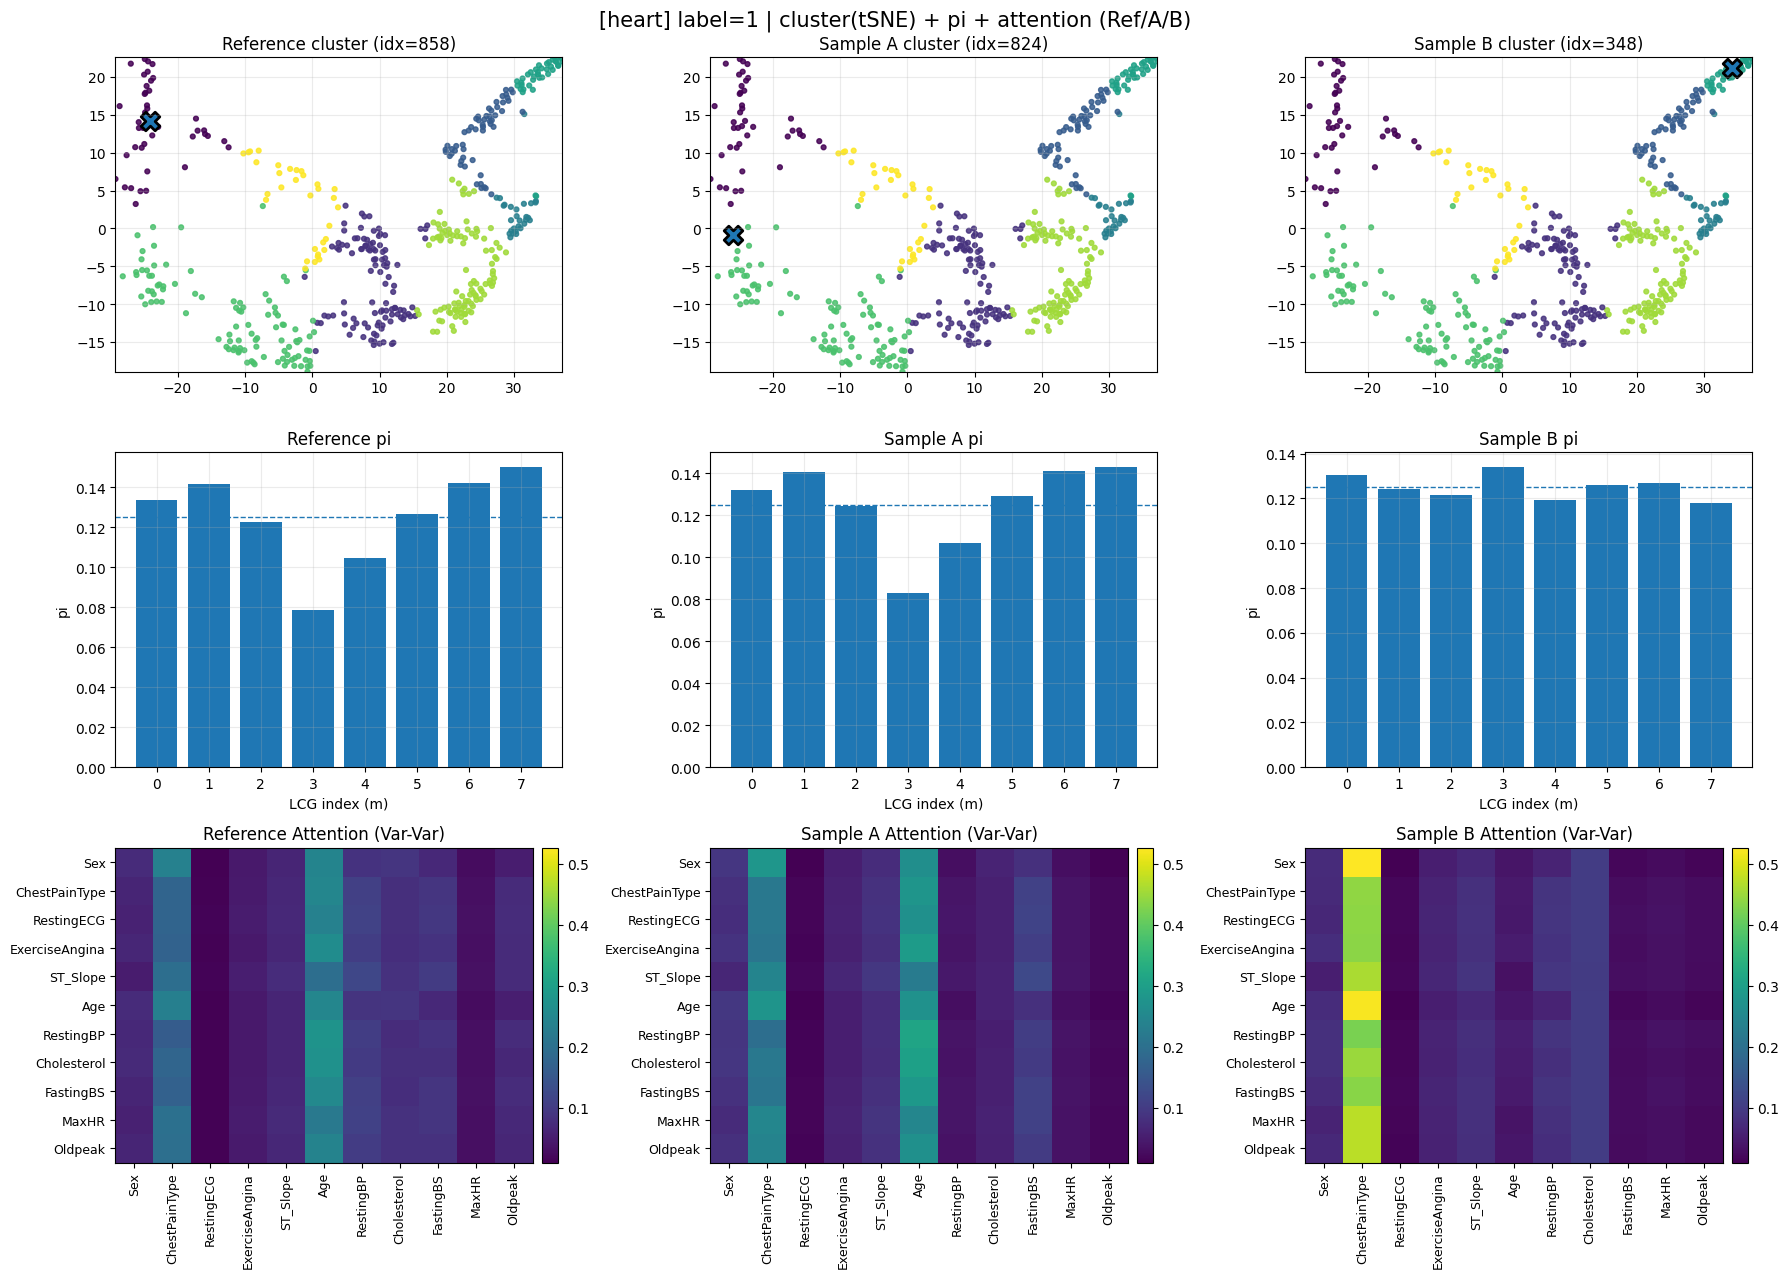

In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ----------------------------
# 0) Medicaldataset loader 찾기
# ----------------------------
def get_loader_by_key(loaders, key="heart"):
    for k in loaders.keys():
        if str(k).lower() == str(key).lower():
            return k, loaders[k]
    for k in loaders.keys():
        if str(key).lower() in str(k).lower():
            return k, loaders[k]
    raise KeyError(f"'{key}' loader not found. available={list(loaders.keys())}")

# ----------------------------
# 0.5) 변수 이름 추출 (중복 제거 X, 길이 최대한 유지)
# ----------------------------
def extract_feature_names(batch):
    names = []

    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            v = t[0] if isinstance(t, (tuple, list)) and len(t) > 0 else t
            names.append(str(v).split(",")[0].split("'")[0].strip())

    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            v = t[0] if isinstance(t, (tuple, list)) and len(t) > 0 else t
            names.append(str(v).split(",")[0].split("'")[0].strip())

    return names

# ------------------------------------------------------
# 1) Medicaldataset 전체에서 pi + attention 수집
# ------------------------------------------------------
@torch.no_grad()
def collect_pi_and_affinity_for_one_source(model, loader, device):
    model.eval()
    pis = []
    ys = []
    affs = []
    names = []

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        _ = model.predict(batch_t, return_all=True)

        pi = model.graph_quantizer.last_pi          # [B, M]
        P_1matt  = model._last_P_basis              # [B, N, N]  == (1 - att)

        if pi is None or P_1matt is None:
            raise RuntimeError("pi 또는 _last_P_basis가 None. args.use_lcg=True인지 확인.")

        # attention 자체로 변환
        att = 1.0 - P_1matt
        att = torch.clamp(att, 0.0, 1.0)

        # 변수명은 batch 기준으로 뽑음 (배치 내 샘플들 동일 전제)
        var_names = extract_feature_names(batch)

        B = pi.shape[0]
        for b in range(B):
            A = att[b].detach().cpu().numpy()
            N = A.shape[0]

            # 축 라벨 길이를 A 크기에 맞춤 (v0 같은 거 안 쓰고, 가능한 이름만 씀)
            if N == len(var_names) + 1:
                node_names = ["CLS"] + var_names
            elif N == len(var_names):
                node_names = var_names
            elif N < len(var_names):
                node_names = var_names[:N]
            else:
                node_names = var_names + [""] * (N - len(var_names))

            pis.append(pi[b].detach().cpu().numpy())              # [M]
            ys.append(int(batch_t["y"][b].item()))
            affs.append(A)                                        # [N,N]  (attention)
            names.append(node_names)                              # 길이 N 라벨

    pis = np.stack(pis, axis=0)
    ys  = np.array(ys, dtype=int)
    return pis, ys, affs, names

# ------------------------------------------------------
# 2) label 내부 KMeans + "가장 먼 centroid 2개"
# ------------------------------------------------------
def kmeans_farthest_centroids_pick_samples(pis, ys, label, k=8, seed=42):
    idx = np.where(ys == label)[0]
    if len(idx) < 2:
        raise ValueError(f"label={label} samples too few: {len(idx)}")

    X = pis[idx]  # [n_lab, M]
    k_eff = min(k, len(idx))
    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_  # [k_eff, M]

    dist = np.linalg.norm(C[:, None, :] - C[None, :, :], axis=-1)
    np.fill_diagonal(dist, -np.inf)
    a, b = np.unravel_index(np.argmax(dist), dist.shape)

    def pick_nearest(centroid):
        d = np.linalg.norm(X - centroid[None, :], axis=1)
        return idx[int(np.argmin(d))]

    samp_a = pick_nearest(C[a])
    samp_b = pick_nearest(C[b])

    return {
        "idx_lab": idx,
        "X_lab": X,
        "cid": cid,
        "km": km,
        "centroid_pair": (a, b),
        "sample_pair": (samp_a, samp_b),
    }

# ------------------------------------------------------
# 3) Plot: (i) label별 전체 tSNE, (ii) label 내부 cluster tSNE
# ------------------------------------------------------
def plot_tsne_by_label(pis, ys, title_prefix="[heart]", seed=42):
    N = pis.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=seed).fit_transform(pis)

    plt.figure(figsize=(7, 6))
    for lab in [0, 1]:
        m = (ys == lab)
        plt.scatter(xy[m, 0], xy[m, 1], s=12, alpha=0.85, label=f"y={lab} (n={m.sum()})")
    plt.title(f"{title_prefix} t-SNE(pi) colored by label")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()
    return xy

def plot_label_clusters_and_pick(xy_all, result, ys, label, title_prefix="[heart]"):
    idx = result["idx_lab"]
    cid = result["cid"]
    samp_a, samp_b = result["sample_pair"]

    xy = xy_all[idx]

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(xy[:, 0], xy[:, 1], c=cid, s=12, alpha=0.85)

    ia = np.where(idx == samp_a)[0][0]
    ib = np.where(idx == samp_b)[0][0]
    plt.scatter(xy[ia, 0], xy[ia, 1], s=120, marker="X", edgecolors="black", linewidths=1.5)
    plt.scatter(xy[ib, 0], xy[ib, 1], s=120, marker="X", edgecolors="black", linewidths=1.5)

    a, b = result["centroid_pair"]
    plt.title(f"{title_prefix} label={label} | KMeans on pi | farthest centroids=({a},{b})")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.colorbar(sc, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------
# (NEW) centroid(a0) 기준 ref / A / B 뽑기
# ------------------------------------------------------
def pick_ref_A_B_near_centroids(res):
    idx_lab = res["idx_lab"]          # global indices for this label
    X       = res["X_lab"]            # [n_lab, M]
    cid     = res["cid"]              # [n_lab]
    C       = res["km"].cluster_centers_
    a0, b0  = res["centroid_pair"]    # farthest centroid pair

    cent0   = C[a0]
    centfar = C[b0]

    d0   = np.linalg.norm(X - cent0[None, :], axis=1)
    dfar = np.linalg.norm(X - centfar[None, :], axis=1)

    # Reference: centroid(a0)에서 자기 cluster(a0) 내부 가장 가까운 샘플
    mask_ref = (cid == a0)
    ref_local = int(np.argmin(np.where(mask_ref, d0, np.inf)))
    ref_global = int(idx_lab[ref_local])

    # Sample A: centroid(a0)에서 다른 cluster 중 가장 가까운 샘플
    mask_A = (cid != a0)
    if mask_A.sum() == 0:
        A_local = ref_local
    else:
        A_local = int(np.argmin(np.where(mask_A, d0, np.inf)))
    A_global = int(idx_lab[A_local])

    # Sample B: farthest centroid(b0)에서 자기 cluster(b0) 내부 가장 가까운 샘플
    mask_B = (cid == b0)
    B_local = int(np.argmin(np.where(mask_B, dfar, np.inf)))
    B_global = int(idx_lab[B_local])

    return {
        "a0": a0, "b0": b0,
        "ref_global": ref_global, "A_global": A_global, "B_global": B_global,
        "ref_local": ref_local, "A_local": A_local, "B_local": B_local,
    }

# ------------------------------------------------------
# (NEW) 2x3 plot: coord(3) + attention(3) with 변수명
# ------------------------------------------------------
def plot_three_samples_cluster_pi_attention_3x3(
    xy_all, res, pis, affs, names,
    ref_global, A_global, B_global,
    ref_local, A_local, B_local,
    title
):
    """
    3x3 grid (requested order):
      row0: cluster(tSNE) scatter + highlight (Ref/A/B)
      row1: pi bar (Ref/A/B)
      row2: attention heatmap (Ref/A/B)
    """
    idx_lab = res["idx_lab"]
    cid     = res["cid"]
    xy_lab  = xy_all[idx_lab]   # [n_lab, 2]

    # --- data ---
    pi_ref = pis[ref_global]
    pi_A   = pis[A_global]
    pi_B   = pis[B_global]

    A_ref = affs[ref_global]
    A_A   = affs[A_global]
    A_B   = affs[B_global]

    n_ref = names[ref_global]
    n_A   = names[A_global]
    n_B   = names[B_global]

    # --- scales ---
    vmin = min(A_ref.min(), A_A.min(), A_B.min())
    vmax = max(A_ref.max(), A_A.max(), A_B.max())

    x_min, x_max = xy_lab[:, 0].min(), xy_lab[:, 0].max()
    y_min, y_max = xy_lab[:, 1].min(), xy_lab[:, 1].max()

    M = pi_ref.shape[0]
    uniform = 1.0 / M

    fig, axes = plt.subplots(3, 3, figsize=(18, 13))

    # ----------------
    # helpers
    # ----------------
    def draw_cluster(ax, highlight_local, panel_title):
        ax.scatter(xy_lab[:, 0], xy_lab[:, 1], c=cid, s=12, alpha=0.85)
        ax.scatter(
            xy_lab[highlight_local, 0], xy_lab[highlight_local, 1],
            s=180, marker="X", edgecolors="black", linewidths=2.0
        )
        ax.set_title(panel_title, fontsize=12)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.25)

    def draw_pi(ax, pi, panel_title):
        ax.bar(np.arange(len(pi)), pi)
        ax.axhline(uniform, linestyle="--", linewidth=1)
        ax.set_title(panel_title, fontsize=12)
        ax.set_xlabel("LCG index (m)")
        ax.set_ylabel("pi")
        ax.grid(True, alpha=0.25)

    def draw_att(ax, A, node_names, att_title):
        N = A.shape[0]
        labels = list(node_names)
        if len(labels) > N:
            labels = labels[:N]
        elif len(labels) < N:
            labels = labels + [""] * (N - len(labels))  # 빈칸 패딩

        im = ax.imshow(A, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(att_title, fontsize=12)
        ax.set_xticks(range(N)); ax.set_yticks(range(N))
        ax.set_xticklabels(labels, rotation=90, fontsize=9)
        ax.set_yticklabels(labels, fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    # ----------------
    # row 0: cluster(tSNE)
    # ----------------
    draw_cluster(
        axes[0, 0], ref_local,
        f"Reference cluster (idx={ref_global})"
    )
    draw_cluster(
        axes[0, 1], A_local,
        f"Sample A cluster (idx={A_global})"
    )
    draw_cluster(
        axes[0, 2], B_local,
        f"Sample B cluster (idx={B_global})"
    )

    # ----------------
    # row 1: pi bars
    # ----------------
    draw_pi(axes[1, 0], pi_ref, f"Reference pi")
    draw_pi(axes[1, 1], pi_A,   f"Sample A pi")
    draw_pi(axes[1, 2], pi_B,   f"Sample B pi")

    # ----------------
    # row 2: attention
    # ----------------
    draw_att(axes[2, 0], A_ref, n_ref, "Reference Attention (Var-Var)")
    draw_att(axes[2, 1], A_A,   n_A,   "Sample A Attention (Var-Var)")
    draw_att(axes[2, 2], A_B,   n_B,   "Sample B Attention (Var-Var)")

    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


# ============================
# RUN (Medicaldataset only)
# ============================
src_key, medical_loader = get_loader_by_key(loaders, "heart")
print("Using source:", src_key)

pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, medical_loader, device)

xy_all = plot_tsne_by_label(pis, ys, title_prefix=f"[{src_key}]")

for lab in [0, 1]:
    res = kmeans_farthest_centroids_pick_samples(pis, ys, label=lab, k=8, seed=42)
    plot_label_clusters_and_pick(xy_all, res, ys, label=lab, title_prefix=f"[{src_key}]")

    picked = pick_ref_A_B_near_centroids(res)

    plot_three_samples_cluster_pi_attention_3x3(
    xy_all=xy_all,
    res=res,
    pis=pis,
    affs=affs,
    names=names,
    ref_global=picked["ref_global"],
    A_global=picked["A_global"],
    B_global=picked["B_global"],
    ref_local=picked["ref_local"],
    A_local=picked["A_local"],
    B_local=picked["B_local"],
    title=f"[{src_key}] label={lab} | cluster(tSNE) + pi + attention (Ref/A/B)"
)


In [26]:
@torch.no_grad()
def collect_pi_y_phat(model, loader, device):
    model.eval()
    pis, ys, phats = [], [], []

    def _find_tensor(obj):
        """obj 안에서 [B], [B,1], [B,2] 같은 prediction 후보 tensor를 찾아서 반환"""
        # tensor
        if torch.is_tensor(obj):
            return obj
        # numpy
        if isinstance(obj, np.ndarray):
            return torch.from_numpy(obj)
        # dict: 먼저 흔한 키들 우선
        if isinstance(obj, dict):
            for k in ["prob", "probs", "p", "pred_prob", "y_prob", "logit", "logits", "y_logit", "pred", "preds", "y_pred"]:
                if k in obj and obj[k] is not None:
                    t = _find_tensor(obj[k])
                    if t is not None:
                        return t
            # 그래도 없으면 값들 중 tensor 찾아보기
            for v in obj.values():
                t = _find_tensor(v)
                if t is not None:
                    return t
            return None
        # tuple/list: 안을 훑어서 tensor 찾아보기
        if isinstance(obj, (list, tuple)):
            for v in obj:
                t = _find_tensor(v)
                if t is not None:
                    return t
            return None
        # 그 외는 실패
        return None

    def to_prob(out):
        """
        out: model.predict 반환값 (dict/tensor/tuple/list/np.ndarray...)
        return: p_hat in [0,1], shape [B]
        """
        t = _find_tensor(out)
        if t is None:
            raise RuntimeError(f"predict output에서 tensor를 못 찾음. type(out)={type(out)}")

        t = t.detach()
        # [B,2]면 binary class logits/prob로 해석
        if t.ndim == 2 and t.shape[1] == 2:
            # 이미 probability면(0~1이고 row sum ~1) 그대로
            if (t.min() >= 0.0) and (t.max() <= 1.0):
                row_sum = t.sum(dim=1)
                if torch.allclose(row_sum, torch.ones_like(row_sum), atol=1e-2, rtol=1e-2):
                    p = t[:, 1]
                else:
                    p = torch.softmax(t.float(), dim=1)[:, 1]
            else:
                p = torch.softmax(t.float(), dim=1)[:, 1]
            return torch.clamp(p.float(), 0.0, 1.0)

        # [B,1] -> [B]
        if t.ndim == 2 and t.shape[1] == 1:
            t = t[:, 0]

        # [B] 형태: 값 범위가 0~1이면 prob로 보고, 아니면 logit로 보고 sigmoid
        if t.ndim == 1:
            if (t.min() >= 0.0) and (t.max() <= 1.0):
                return torch.clamp(t.float(), 0.0, 1.0)
            else:
                return torch.clamp(torch.sigmoid(t.float()), 0.0, 1.0)

        raise RuntimeError(f"예상 못한 pred tensor shape={tuple(t.shape)}")

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        out = model.predict(batch_t, return_all=True)

        pi = model.graph_quantizer.last_pi  # [B, M]
        if pi is None:
            raise RuntimeError("last_pi가 None. use_lcg=True인지 확인.")

        p_hat = to_prob(out)  # [B]
        y = batch_t["y"].detach().view(-1).long()

        pis.append(pi.detach().cpu().numpy())
        phats.append(p_hat.detach().cpu().numpy())
        ys.append(y.detach().cpu().numpy())

    pis = np.concatenate(pis, axis=0)
    phats = np.concatenate(phats, axis=0)
    ys = np.concatenate(ys, axis=0)
    return pis, ys, phats


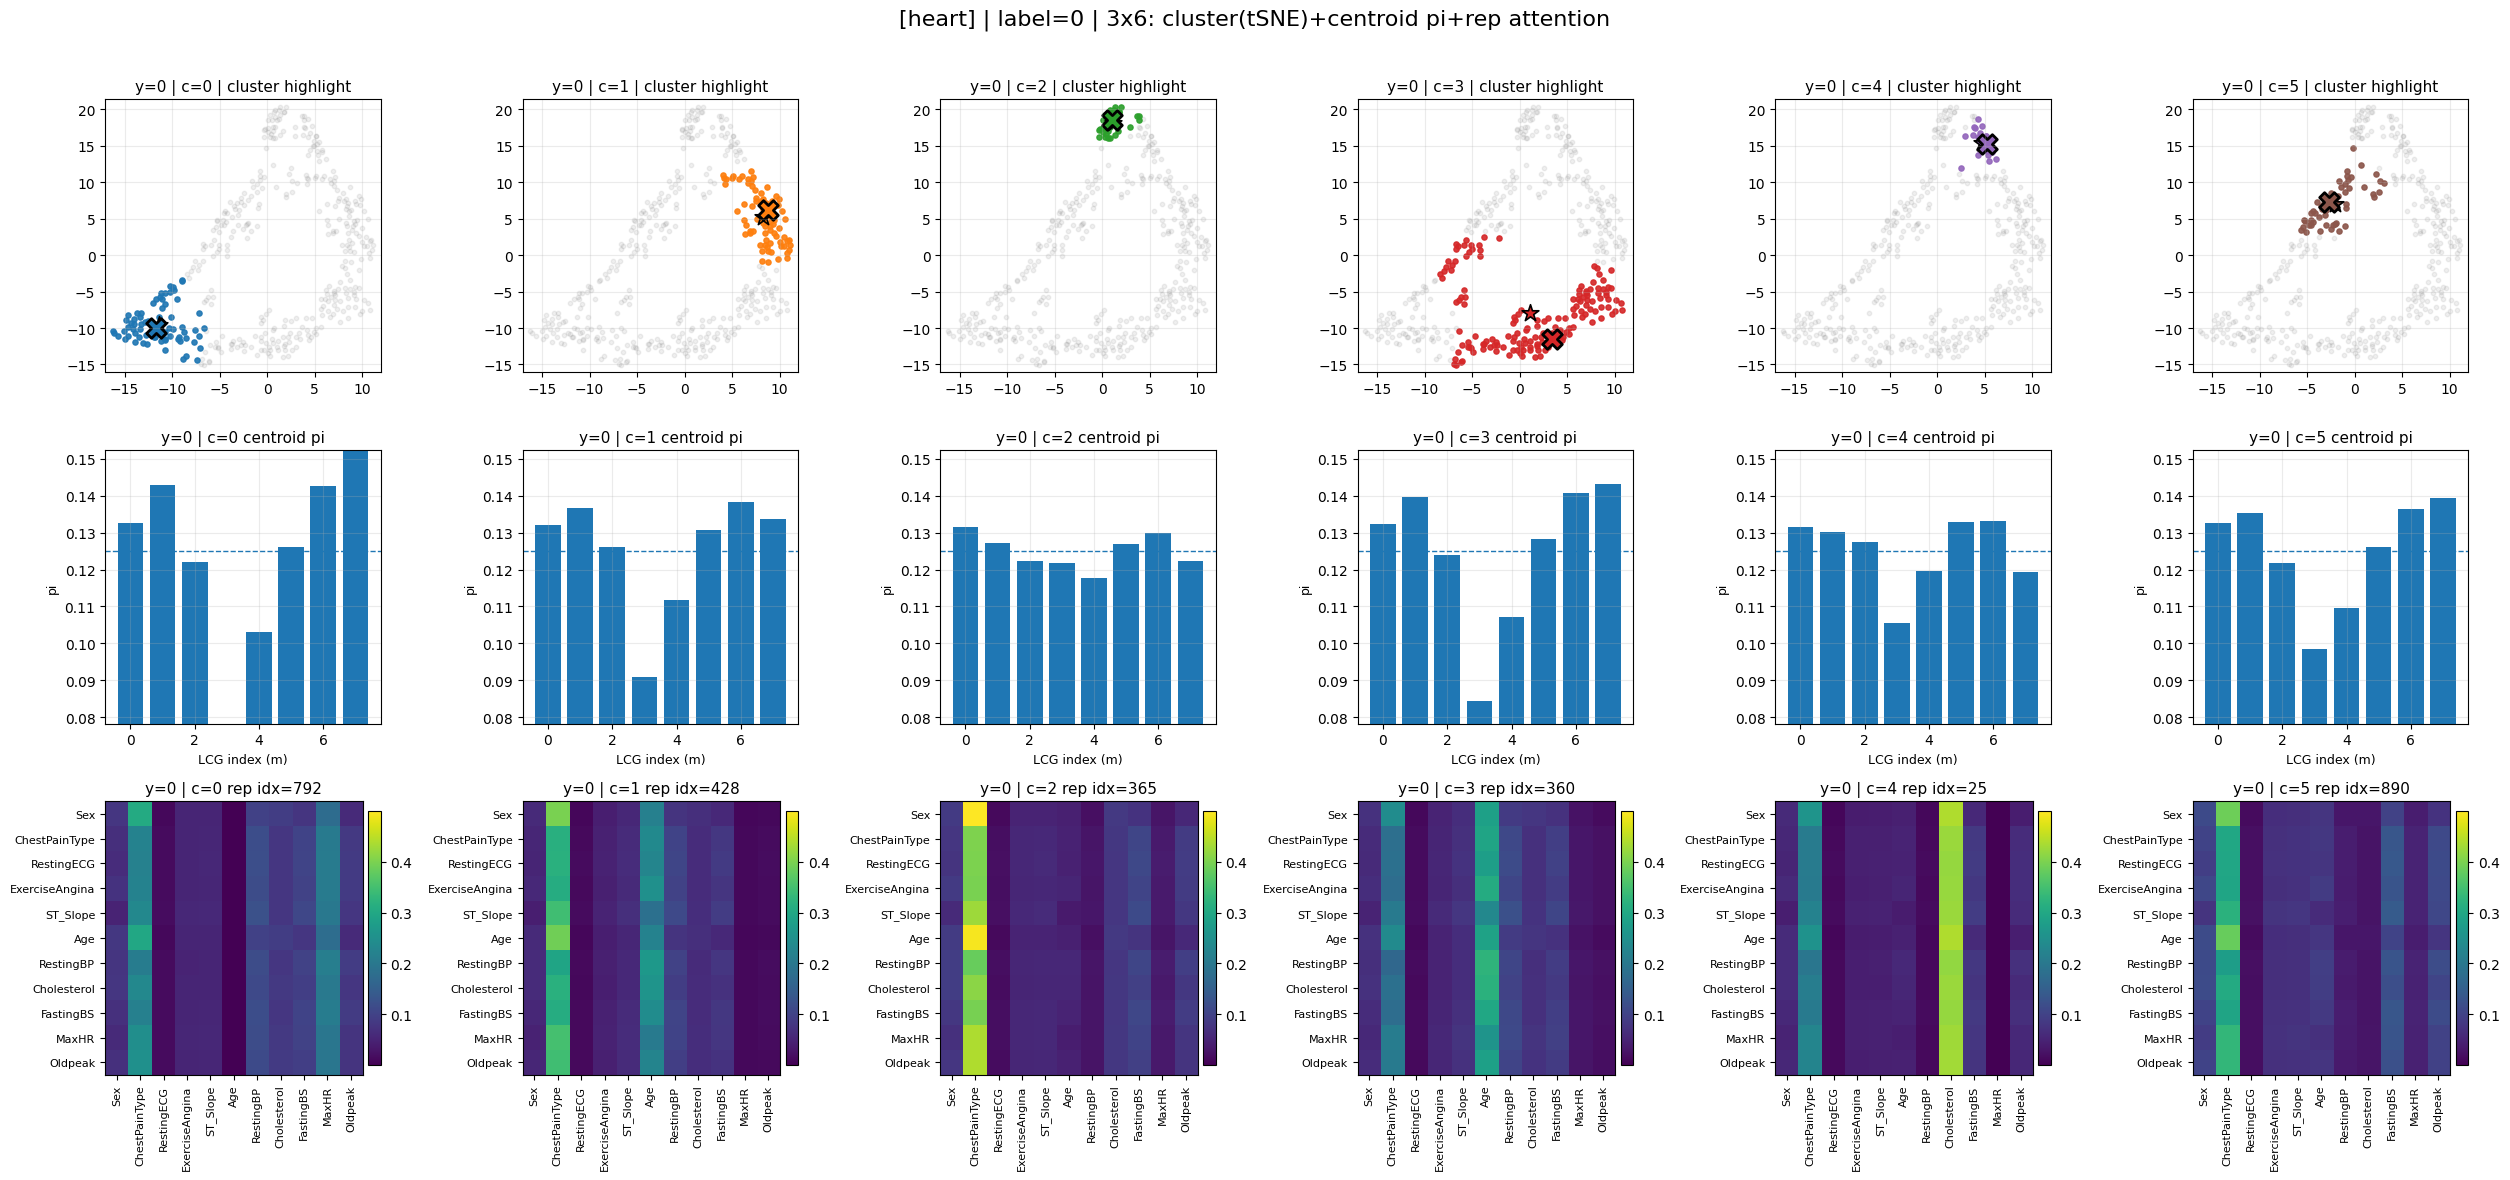

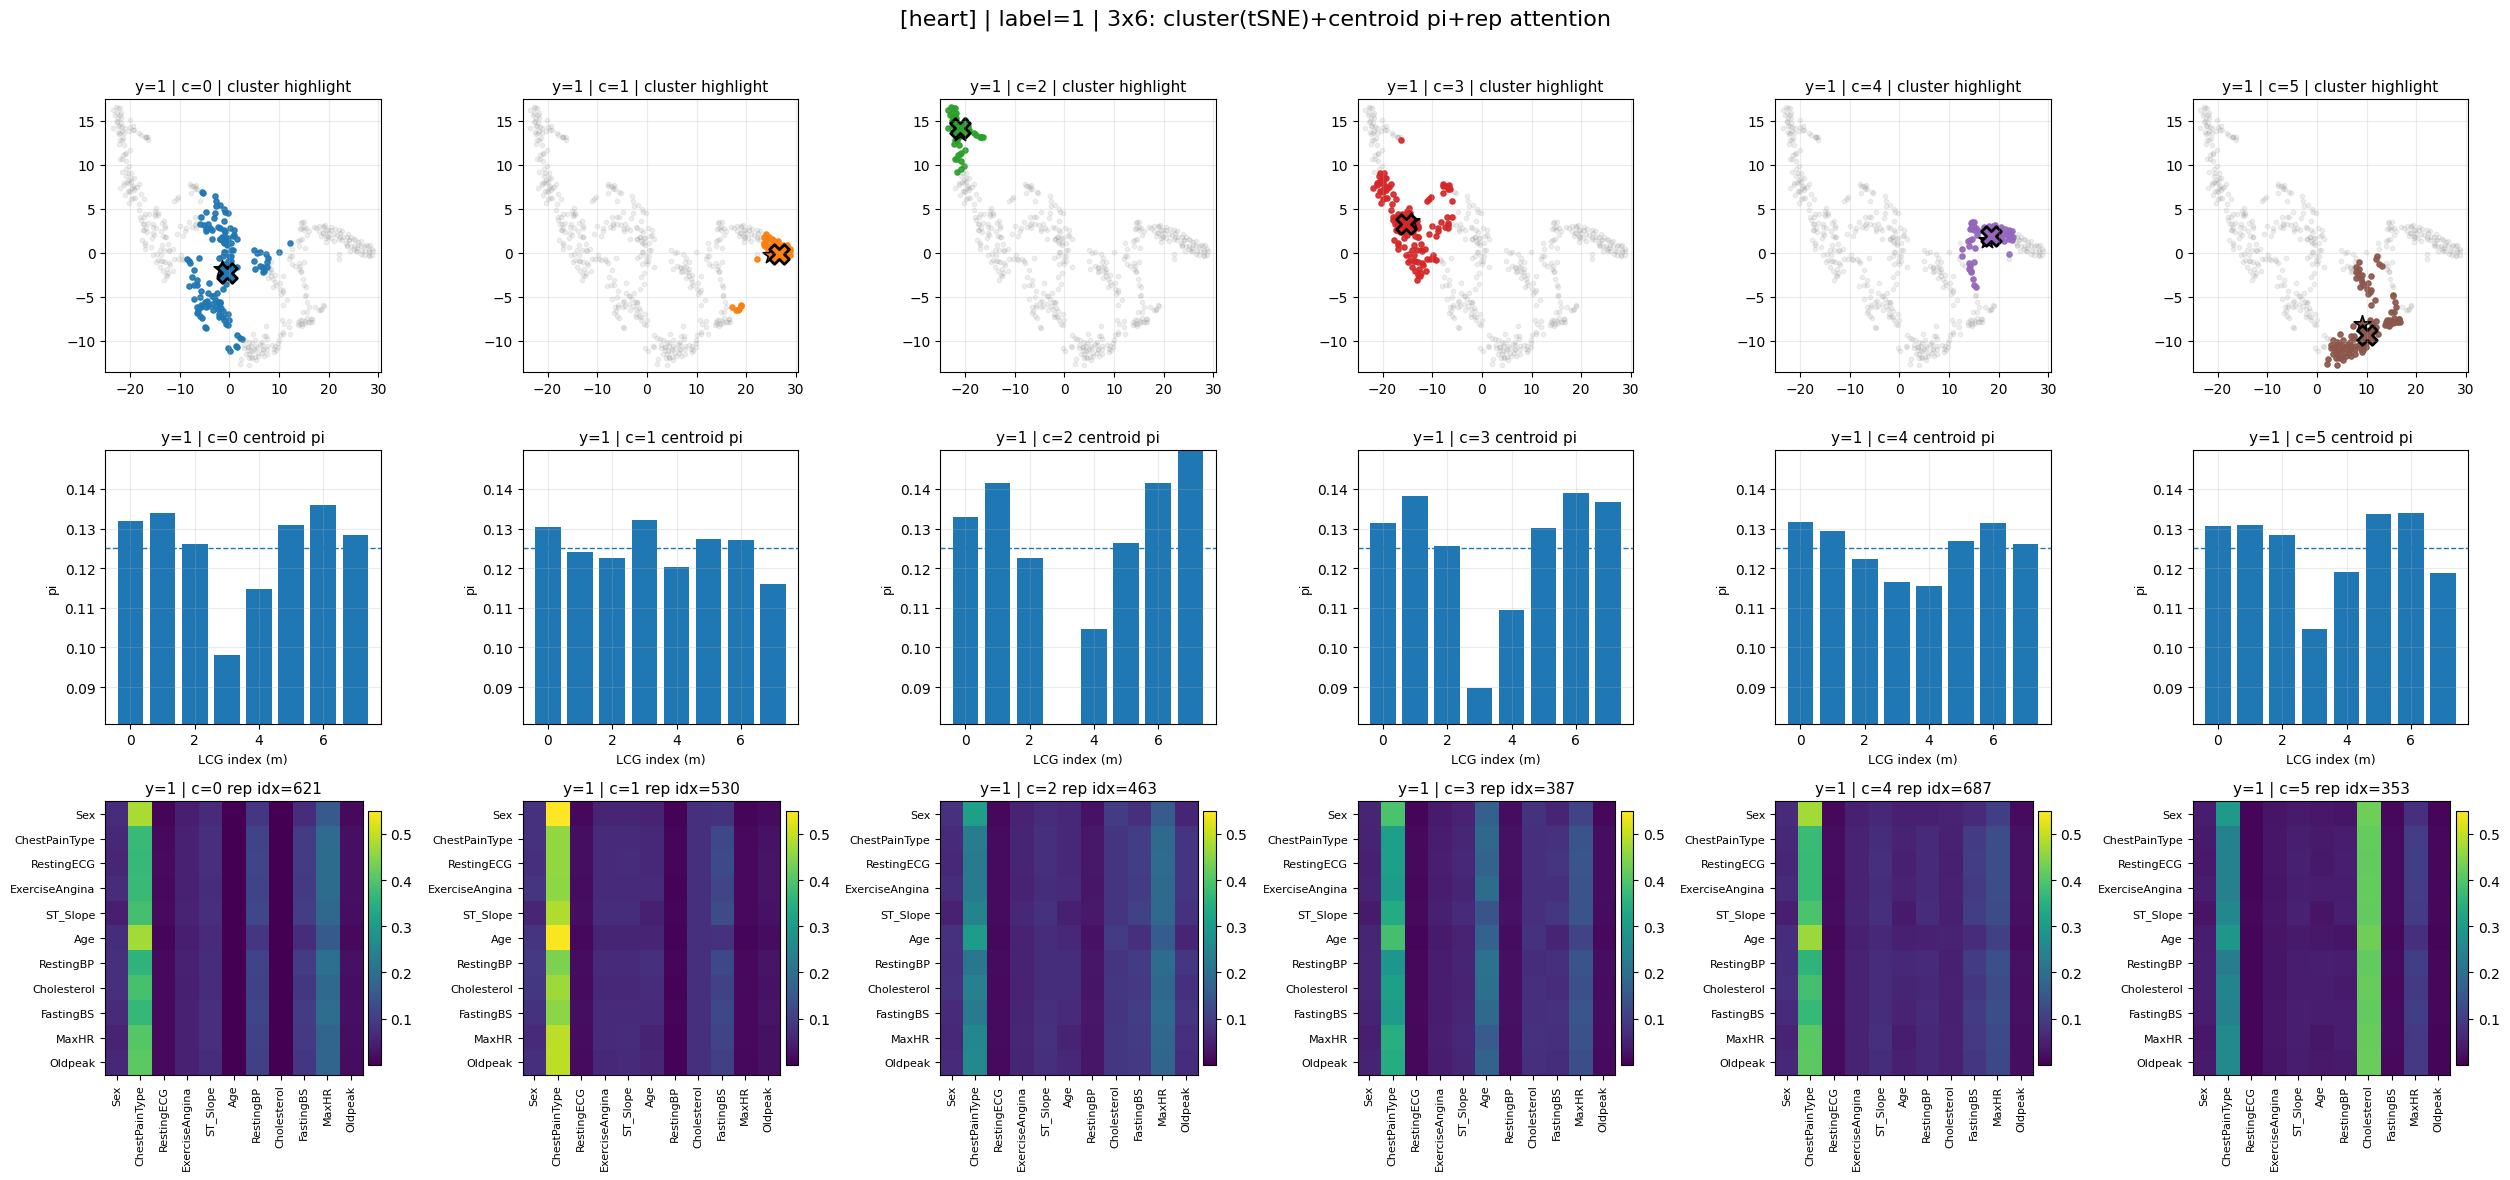

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ----------------------------
# t-SNE (subset용)
# ----------------------------
def compute_tsne_coords(pis, seed=42):
    N = pis.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate=200,
        init="pca",
        random_state=seed
    ).fit_transform(pis)
    return xy

# ----------------------------
# KMeans + cluster별 대표 샘플(representative) 뽑기
# ----------------------------
def fit_kmeans_and_pick_reps(pis, ys, label, K=8, seed=42):
    idx = np.where(ys == label)[0]
    if len(idx) == 0:
        return {"idx": idx, "X": None, "cid": None, "km": None, "reps_global": [], "k_eff": 0}

    X = pis[idx]
    k_eff = min(K, len(idx))
    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_

    reps_global = []
    for c in range(k_eff):
        mask = (cid == c)
        Xi = X[mask]
        d = np.linalg.norm(Xi - C[c][None, :], axis=1)
        within = int(np.argmin(d))
        local_candidates = np.where(mask)[0]
        local = int(local_candidates[within])
        reps_global.append(int(idx[local]))

    return {"idx": idx, "X": X, "cid": cid, "km": km, "reps_global": reps_global, "k_eff": k_eff}

# =========================================================
# NEW: label별로 3xK 그림을 1장씩 (총 2장: y=0, y=1)
#   Row1: cluster(tSNE) - 해당 cluster는 실색, 나머지는 회색+투명
#   Row2: centroid pi bar
#   Row3: rep sample attention heatmap
# =========================================================
def plot_3xK_per_label_centroid_pi_attention(
    pis, ys, affs, names,
    label, K=8, seed=42,
    title_prefix="[heart]",
    bg_alpha=0.12, fg_alpha=0.90,
    bg_size=10, fg_size=14
):
    res = fit_kmeans_and_pick_reps(pis, ys, label=label, K=K, seed=seed)
    k_eff = res["k_eff"]
    if k_eff == 0:
        print(f"[warn] label={label} has no samples.")
        return

    idx_lab = res["idx"]          # global idx list for this label
    X_lab   = res["X"]            # [n_lab, M]
    cid     = res["cid"]          # [n_lab]
    C       = res["km"].cluster_centers_
    reps_g  = res["reps_global"]  # len=k_eff

    # (1) tSNE는 label subset에서만 계산
    xy_lab = compute_tsne_coords(X_lab, seed=seed)

    # axis limits (고정)
    x_min, x_max = xy_lab[:, 0].min(), xy_lab[:, 0].max()
    y_min, y_max = xy_lab[:, 1].min(), xy_lab[:, 1].max()
    # 약간 margin
    mx = 0.03 * (x_max - x_min + 1e-9)
    my = 0.03 * (y_max - y_min + 1e-9)
    x_min, x_max = x_min - mx, x_max + mx
    y_min, y_max = y_min - my, y_max + my

    # (2) pi y-limit: centroid들 기준으로 통일
    pi_ymin = float(C[:k_eff].min())
    pi_ymax = float(C[:k_eff].max())

    # (3) attention color scale: label 내 reps 기준으로 통일
    mats = [affs[g] for g in reps_g]
    vmin = min(m.min() for m in mats)
    vmax = max(m.max() for m in mats)

    fig, axes = plt.subplots(3, K, figsize=(4.2 * K, 12))
    if K == 1:
        axes = np.expand_dims(axes, 1)

    def draw_cluster(ax, c):
        # background: all points (grey + transparent)
        ax.scatter(xy_lab[:, 0], xy_lab[:, 1], s=bg_size, alpha=bg_alpha, color="gray")

        # foreground: this cluster only (solid color)
        m = (cid == c)
        if m.sum() > 0:
            # 색은 matplotlib 기본 cycle을 쓰되 cluster마다 다르게
            ax.scatter(xy_lab[m, 0], xy_lab[m, 1], s=fg_size, alpha=fg_alpha, color=f"C{c % 10}")

            # cluster center (tSNE 상에서의 평균 위치; “centroid”의 시각적 앵커)
            cx, cy = xy_lab[m, 0].mean(), xy_lab[m, 1].mean()
            ax.scatter([cx], [cy], s=160, marker="*", edgecolors="black", linewidths=1.2, color=f"C{c % 10}")

        # rep sample highlight (X)
        rep_g = reps_g[c]
        rep_local = int(np.where(idx_lab == rep_g)[0][0])  # subset-local index
        ax.scatter(
            [xy_lab[rep_local, 0]], [xy_lab[rep_local, 1]],
            s=200, marker="X", edgecolors="black", linewidths=2.0, color=f"C{c % 10}"
        )

        ax.set_title(f"y={label} | c={c} | cluster highlight", fontsize=11)
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.25)

    def draw_pi_bar(ax, c):
        centroid_pi = C[c]
        M = centroid_pi.shape[0]
        x = np.arange(M)
        ax.bar(x, centroid_pi)
        ax.axhline(1.0 / M, linestyle="--", linewidth=1)
        ax.set_ylim(pi_ymin, pi_ymax)
        ax.set_title(f"y={label} | c={c} centroid pi", fontsize=11)
        ax.set_xlabel("LCG index (m)", fontsize=9)
        ax.set_ylabel("pi", fontsize=9)
        ax.grid(True, alpha=0.25)

    def draw_att(ax, c):
        rep_g = reps_g[c]
        A = affs[rep_g]
        node_names = names[rep_g]

        N = A.shape[0]
        labels = list(node_names)
        # v0 같은 인위적 이름 생성 대신, 부족하면 빈칸으로 패딩
        if len(labels) > N:
            labels = labels[:N]
        elif len(labels) < N:
            labels = labels + [""] * (N - len(labels))

        im = ax.imshow(A, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(f"y={label} | c={c} rep idx={rep_g}", fontsize=11)
        ax.set_xticks(range(N)); ax.set_yticks(range(N))
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    for c in range(K):
        if c >= k_eff:
            axes[0, c].axis("off")
            axes[1, c].axis("off")
            axes[2, c].axis("off")
            continue

        # Row1: cluster highlight
        draw_cluster(axes[0, c], c)

        # Row2: centroid pi
        draw_pi_bar(axes[1, c], c)

        # Row3: rep attention
        draw_att(axes[2, c], c)

    fig.suptitle(f"{title_prefix} | label={label} | 3x{K}: cluster(tSNE)+centroid pi+rep attention", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.show()

# ----------------------------
# WRAPPER: 두 장 출력 (label=0, label=1)
# ----------------------------
def plot_3xK_two_pages_by_label(pis, ys, affs, names, K=8, seed=42, title_prefix="[heart]"):
    plot_3xK_per_label_centroid_pi_attention(
        pis, ys, affs, names, label=0, K=K, seed=seed, title_prefix=title_prefix
    )
    plot_3xK_per_label_centroid_pi_attention(
        pis, ys, affs, names, label=1, K=K, seed=seed, title_prefix=title_prefix
    )
plot_3xK_two_pages_by_label(pis, ys, affs, names, K=6, seed=42, title_prefix=f"[{src_key}]")


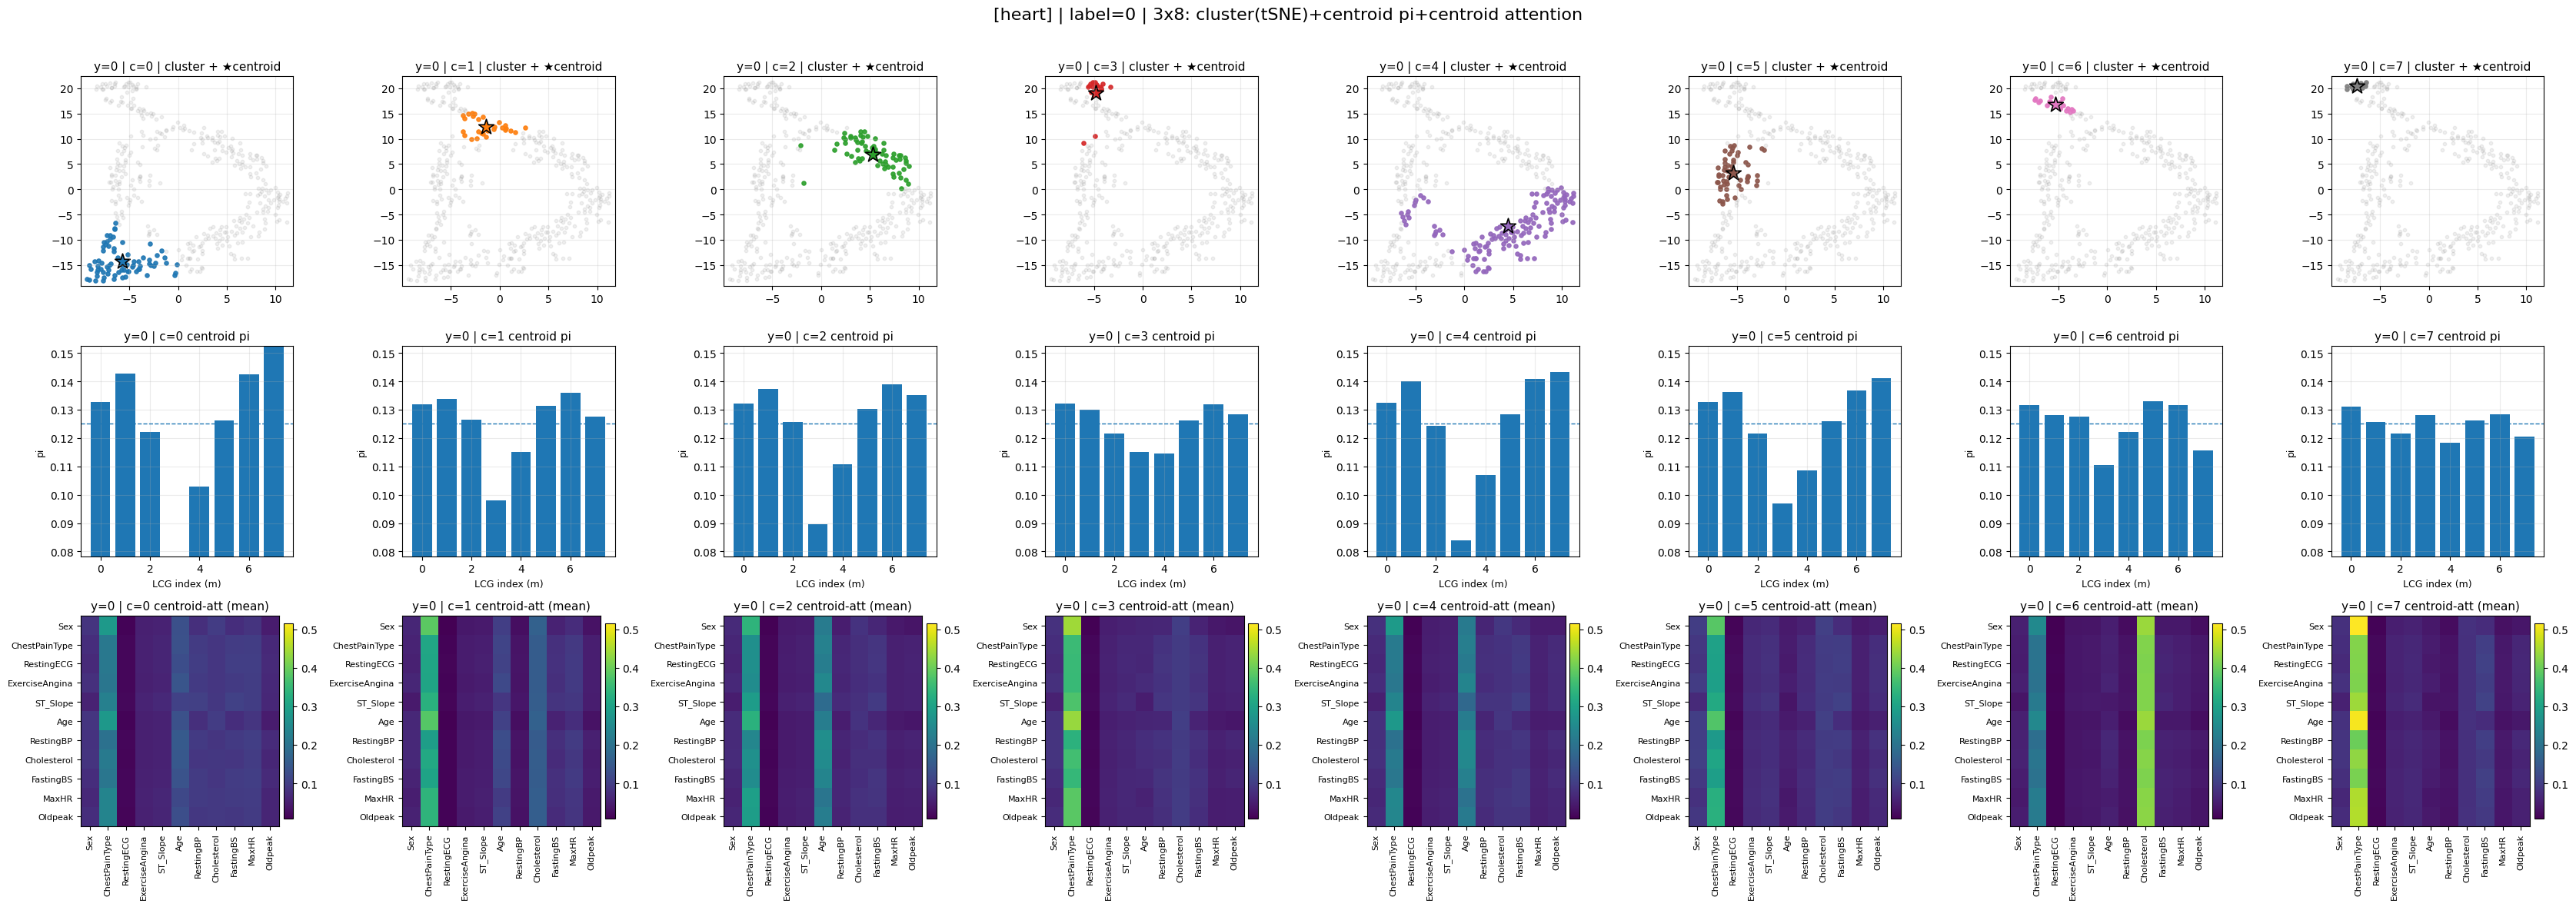

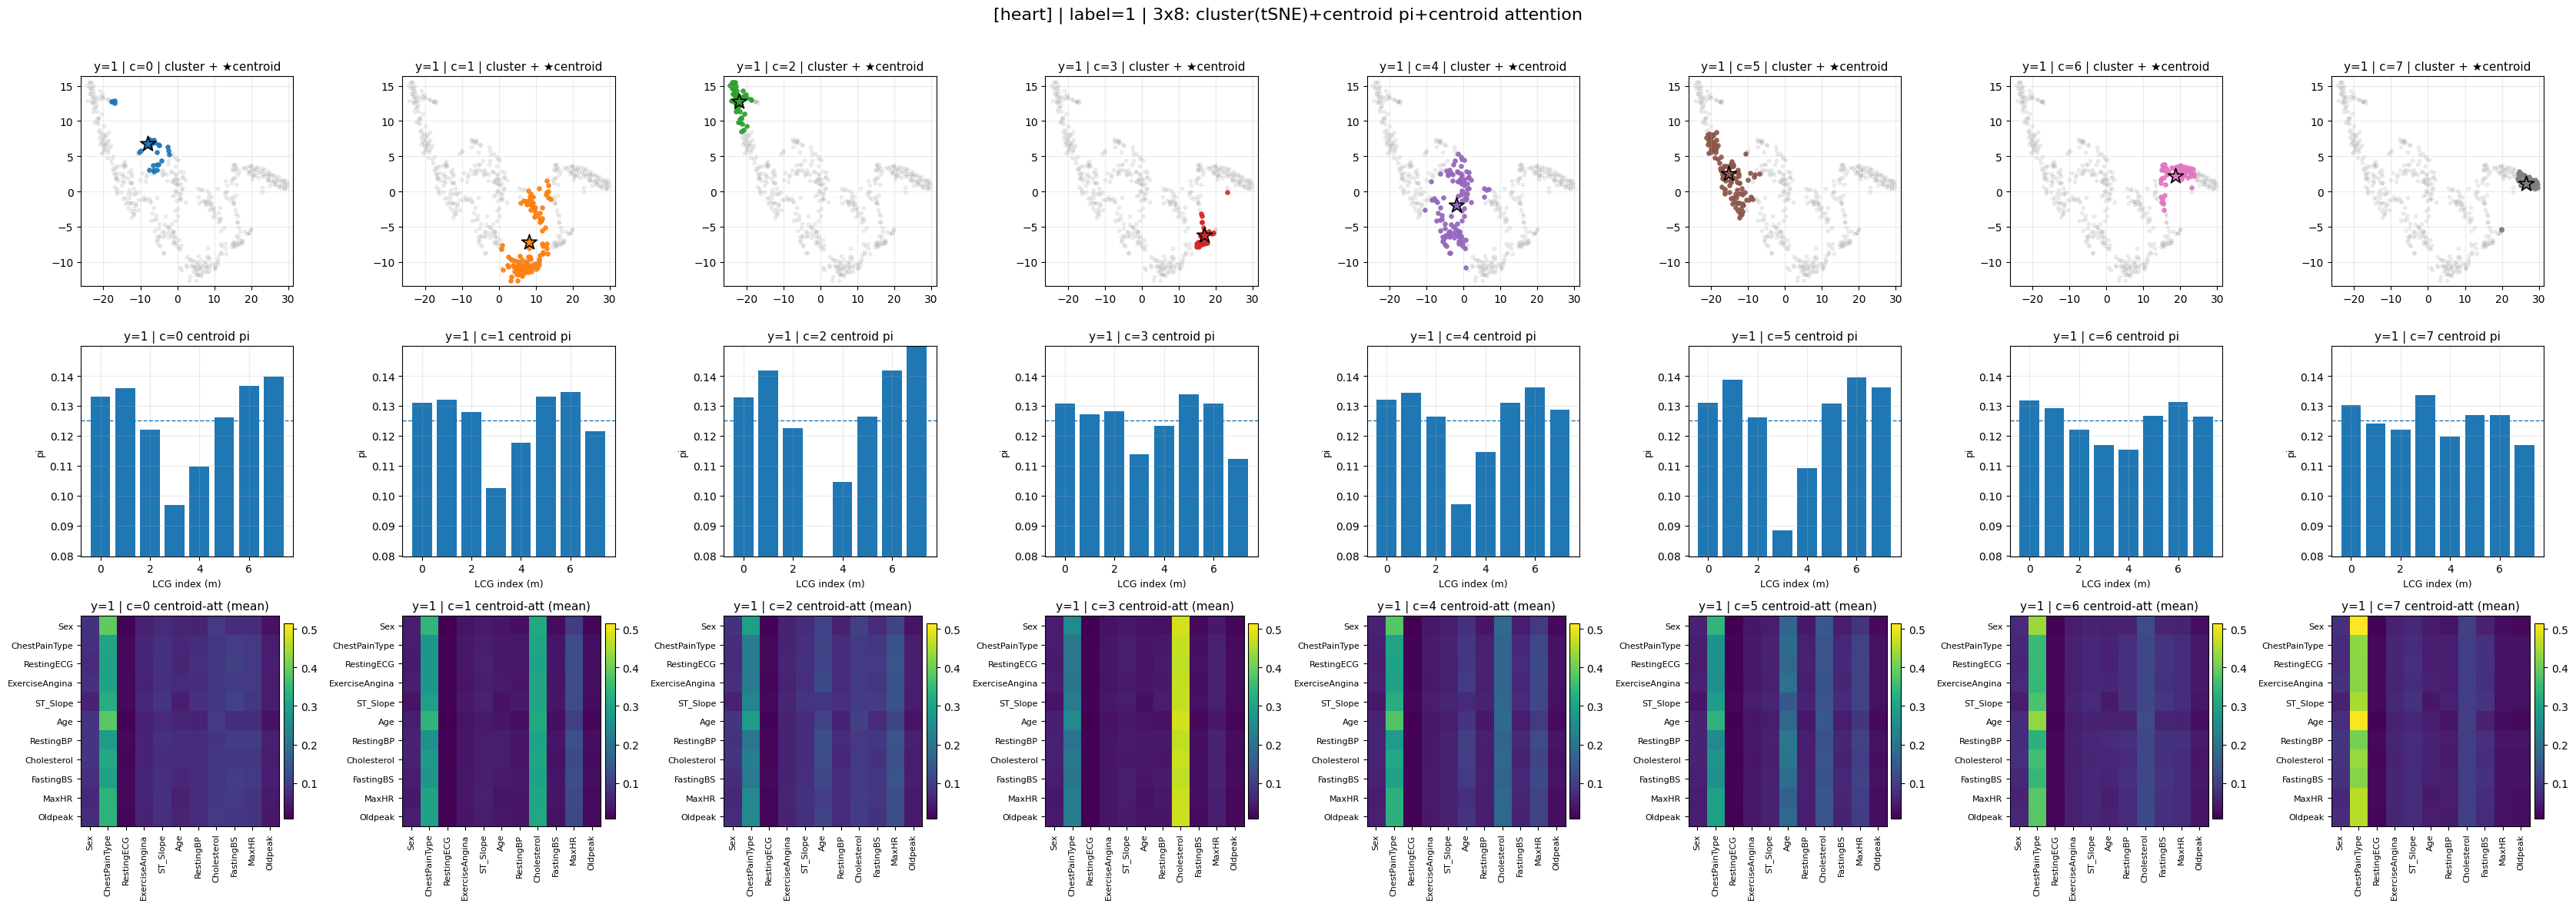

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ----------------------------
# t-SNE (subset용)
# ----------------------------
def compute_tsne_coords(pis, seed=42):
    N = pis.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate=200,
        init="pca",
        random_state=seed
    ).fit_transform(pis)
    return xy

# ----------------------------
# KMeans만 (rep 샘플은 안 뽑음)
# ----------------------------
def fit_kmeans_only(pis, ys, label, K=8, seed=42):
    idx = np.where(ys == label)[0]
    if len(idx) == 0:
        return {"idx": idx, "X": None, "cid": None, "km": None, "k_eff": 0}

    X = pis[idx]
    k_eff = min(K, len(idx))
    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)

    return {"idx": idx, "X": X, "cid": cid, "km": km, "k_eff": k_eff}

# =========================================================
# label별로 3xK 그림을 1장씩 (총 2장: y=0, y=1)
#   Row1: cluster(tSNE) - 해당 cluster는 실색, 나머지는 회색+투명 + ★(centroid only)
#   Row2: centroid pi bar
#   Row3: centroid attention heatmap (cluster mean/median)
# =========================================================
def plot_3xK_per_label_centroid_pi_attention(
    pis, ys, affs, names,
    label, K=8, seed=42,
    title_prefix="[heart]",
    att_reduce="mean",          # "mean" or "median"
    bg_alpha=0.12, fg_alpha=0.90,
    bg_size=10, fg_size=14
):
    res = fit_kmeans_only(pis, ys, label=label, K=K, seed=seed)
    k_eff = res["k_eff"]
    if k_eff == 0:
        print(f"[warn] label={label} has no samples.")
        return

    idx_lab = res["idx"]                      # global idx list for this label
    X_lab   = res["X"]                        # [n_lab, M]
    cid     = res["cid"]                      # [n_lab]
    C       = res["km"].cluster_centers_      # [k_eff, M]

    # (1) tSNE는 label subset에서만 계산
    xy_lab = compute_tsne_coords(X_lab, seed=seed)

    # axis limits (고정)
    x_min, x_max = xy_lab[:, 0].min(), xy_lab[:, 0].max()
    y_min, y_max = xy_lab[:, 1].min(), xy_lab[:, 1].max()
    mx = 0.03 * (x_max - x_min + 1e-9)
    my = 0.03 * (y_max - y_min + 1e-9)
    x_min, x_max = x_min - mx, x_max + mx
    y_min, y_max = y_min - my, y_max + my

    # (2) pi y-limit: centroid들 기준으로 통일
    pi_ymin = float(C[:k_eff].min())
    pi_ymax = float(C[:k_eff].max())

    # (3) centroid attention(클러스터 집계) 미리 계산 + vmin/vmax
    cent_att = [None] * k_eff
    cent_names = [None] * k_eff

    for c in range(k_eff):
        m = (cid == c)
        gidxs = idx_lab[m]  # global indices for samples in cluster c
        if len(gidxs) == 0:
            continue

        mats = [affs[int(g)] for g in gidxs]

        # shape이 혹시라도 섞이면 최소 크기로 자르고 집계(안전)
        h = min(A.shape[0] for A in mats)
        w = min(A.shape[1] for A in mats)
        mats = [A[:h, :w] for A in mats]
        stack = np.stack(mats, axis=0)  # [n,h,w]

        if att_reduce == "median":
            Acent = np.median(stack, axis=0)
        else:
            Acent = stack.mean(axis=0)

        cent_att[c] = Acent

        # 이름은 첫 샘플 기준(부족하면 빈칸 패딩, v0 같은 건 생성 안함)
        nn = names[int(gidxs[0])]
        labels = list(nn)
        N = Acent.shape[0]
        if len(labels) > N:
            labels = labels[:N]
        elif len(labels) < N:
            labels = labels + [""] * (N - len(labels))
        cent_names[c] = labels

    mats_ok = [A for A in cent_att if A is not None]
    vmin = float(min(A.min() for A in mats_ok)) if len(mats_ok) else 0.0
    vmax = float(max(A.max() for A in mats_ok)) if len(mats_ok) else 1.0

    fig, axes = plt.subplots(3, K, figsize=(4.2 * K, 12))
    if K == 1:
        axes = np.expand_dims(axes, 1)

    def draw_cluster(ax, c):
        # background: all points (grey + transparent)
        ax.scatter(xy_lab[:, 0], xy_lab[:, 1], s=bg_size, alpha=bg_alpha, color="gray")

        # foreground: this cluster only (solid color)
        m = (cid == c)
        col = f"C{c % 10}"
        if m.sum() > 0:
            ax.scatter(xy_lab[m, 0], xy_lab[m, 1], s=fg_size, alpha=fg_alpha, color=col)

            # ★ centroid anchor in tSNE space: mean of cluster points
            cx, cy = xy_lab[m, 0].mean(), xy_lab[m, 1].mean()
            ax.scatter([cx], [cy], s=220, marker="*", edgecolors="black", linewidths=1.2, color=col)

        ax.set_title(f"y={label} | c={c} | cluster + ★centroid", fontsize=11)
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.25)

    def draw_pi_bar(ax, c):
        centroid_pi = C[c]
        M = centroid_pi.shape[0]
        x = np.arange(M)
        ax.bar(x, centroid_pi)
        ax.axhline(1.0 / M, linestyle="--", linewidth=1)
        ax.set_ylim(pi_ymin, pi_ymax)
        ax.set_title(f"y={label} | c={c} centroid pi", fontsize=11)
        ax.set_xlabel("LCG index (m)", fontsize=9)
        ax.set_ylabel("pi", fontsize=9)
        ax.grid(True, alpha=0.25)

    def draw_att(ax, c):
        A = cent_att[c]
        if A is None:
            ax.axis("off")
            return

        labels = cent_names[c]
        N = A.shape[0]

        im = ax.imshow(A, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(f"y={label} | c={c} centroid-att ({att_reduce})", fontsize=11)
        ax.set_xticks(range(N)); ax.set_yticks(range(N))
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    for c in range(K):
        if c >= k_eff:
            axes[0, c].axis("off")
            axes[1, c].axis("off")
            axes[2, c].axis("off")
            continue

        draw_cluster(axes[0, c], c)   # Row1: cluster + ★centroid only
        draw_pi_bar(axes[1, c], c)    # Row2: centroid pi
        draw_att(axes[2, c], c)       # Row3: centroid attention (cluster agg)

    fig.suptitle(
        f"{title_prefix} | label={label} | 3x{K}: cluster(tSNE)+centroid pi+centroid attention",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.show()

# ----------------------------
# WRAPPER: 두 장 출력 (label=0, label=1)
# ----------------------------
def plot_3xK_two_pages_by_label(pis, ys, affs, names, K=8, seed=50, title_prefix="[heart]", att_reduce="mean"):
    plot_3xK_per_label_centroid_pi_attention(
        pis, ys, affs, names, label=0, K=K, seed=seed, title_prefix=title_prefix, att_reduce=att_reduce
    )
    plot_3xK_per_label_centroid_pi_attention(
        pis, ys, affs, names, label=1, K=K, seed=seed, title_prefix=title_prefix, att_reduce=att_reduce
    )

# 사용 예시
plot_3xK_two_pages_by_label(pis, ys, affs, names, K=8, seed=50, title_prefix=f"[{src_key}]", att_reduce="mean")


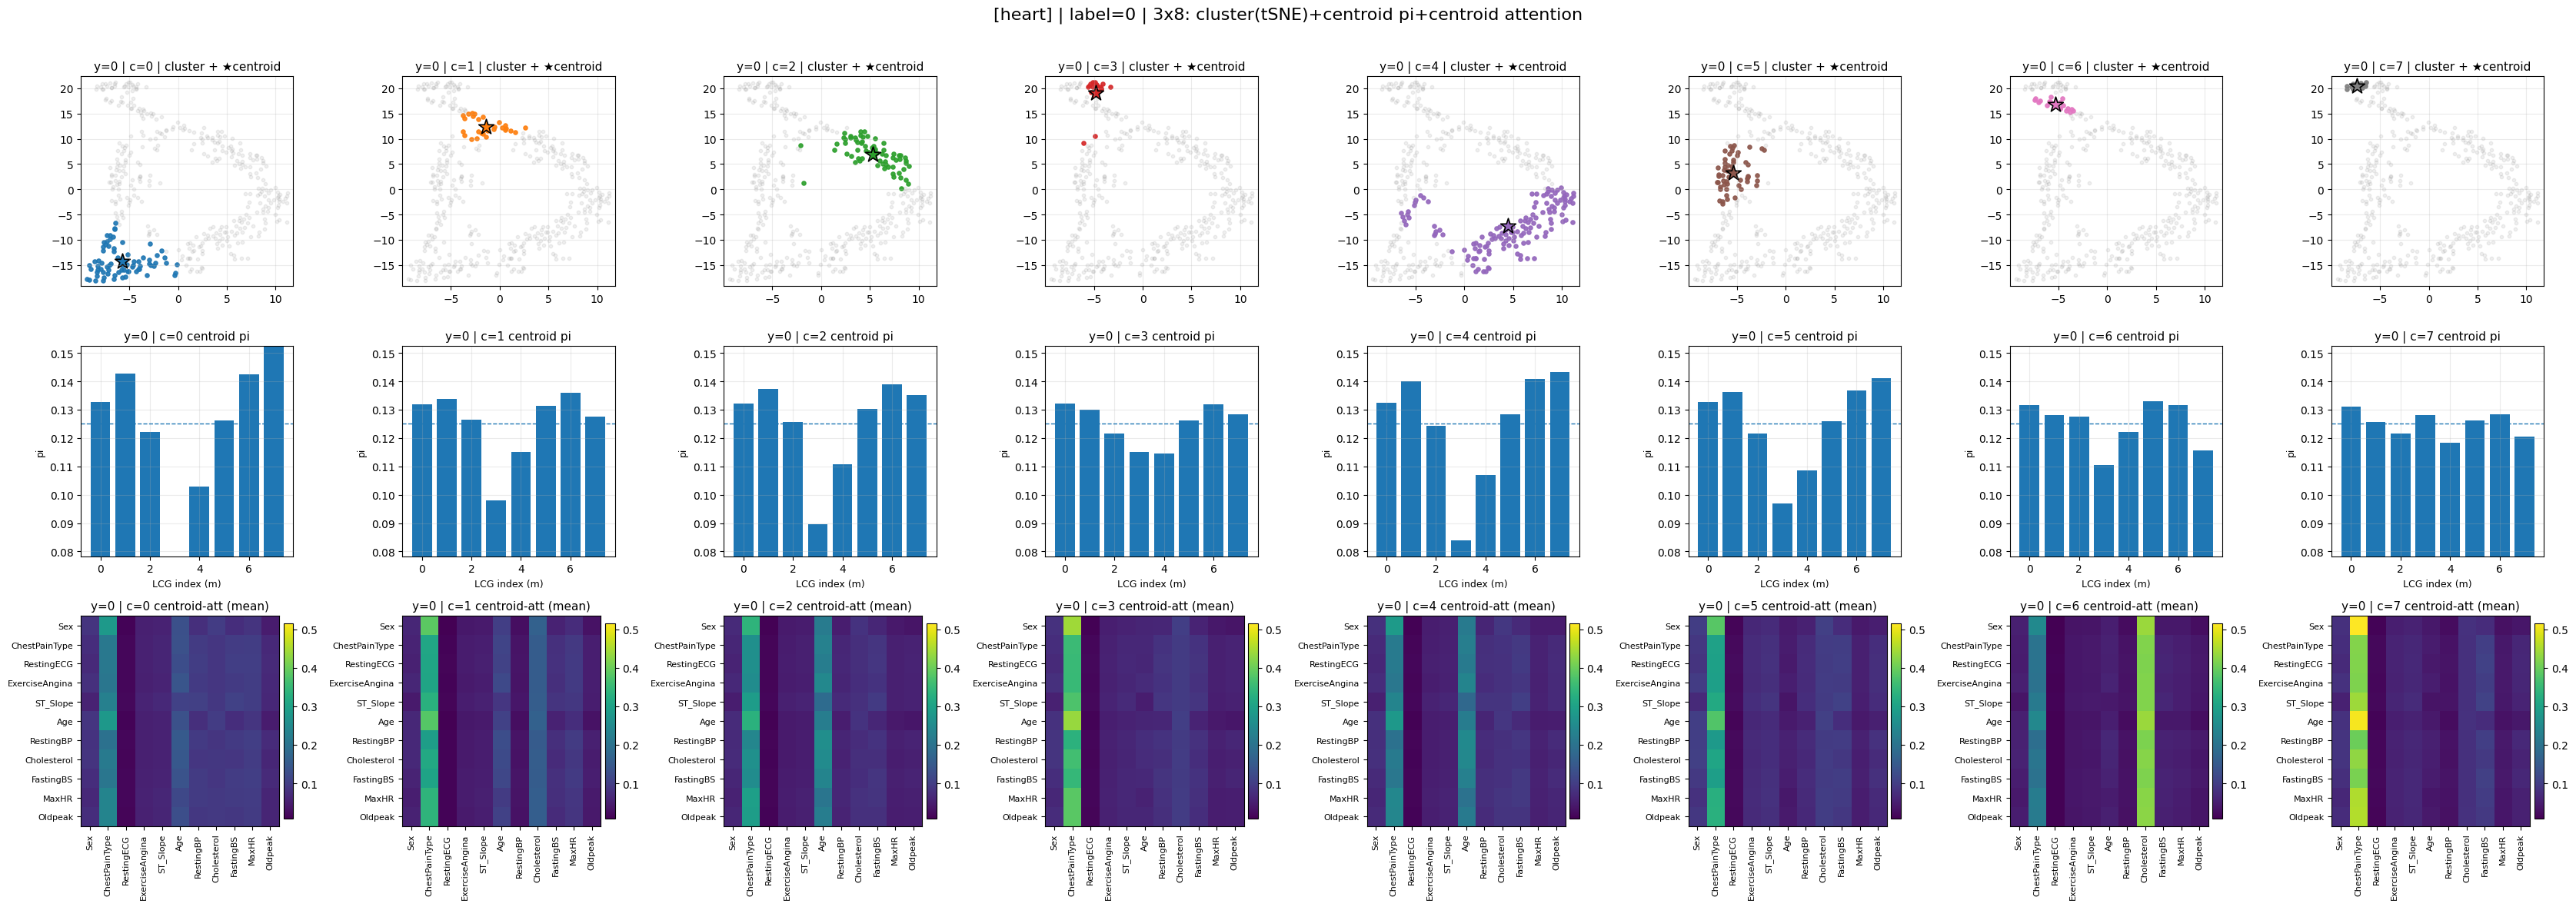

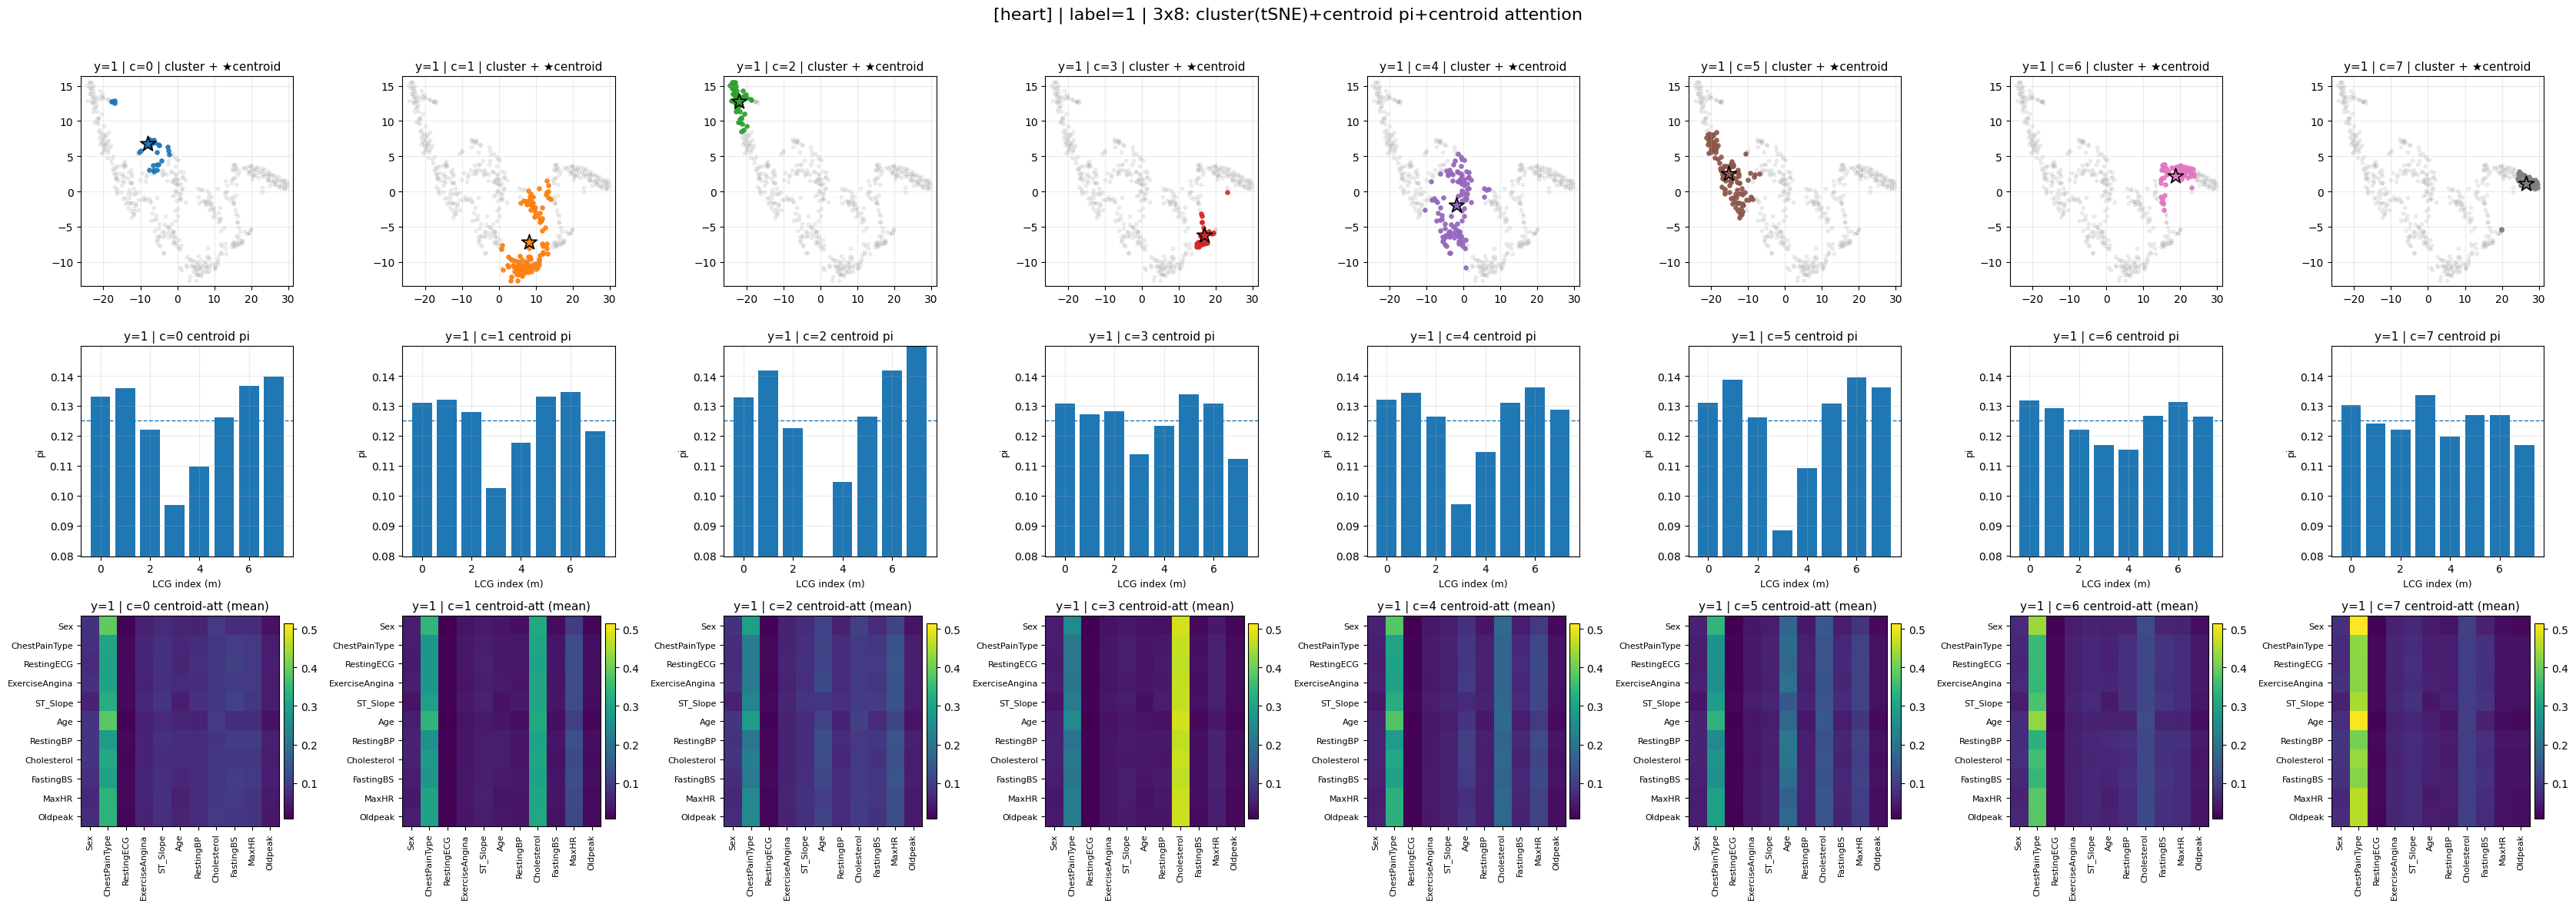

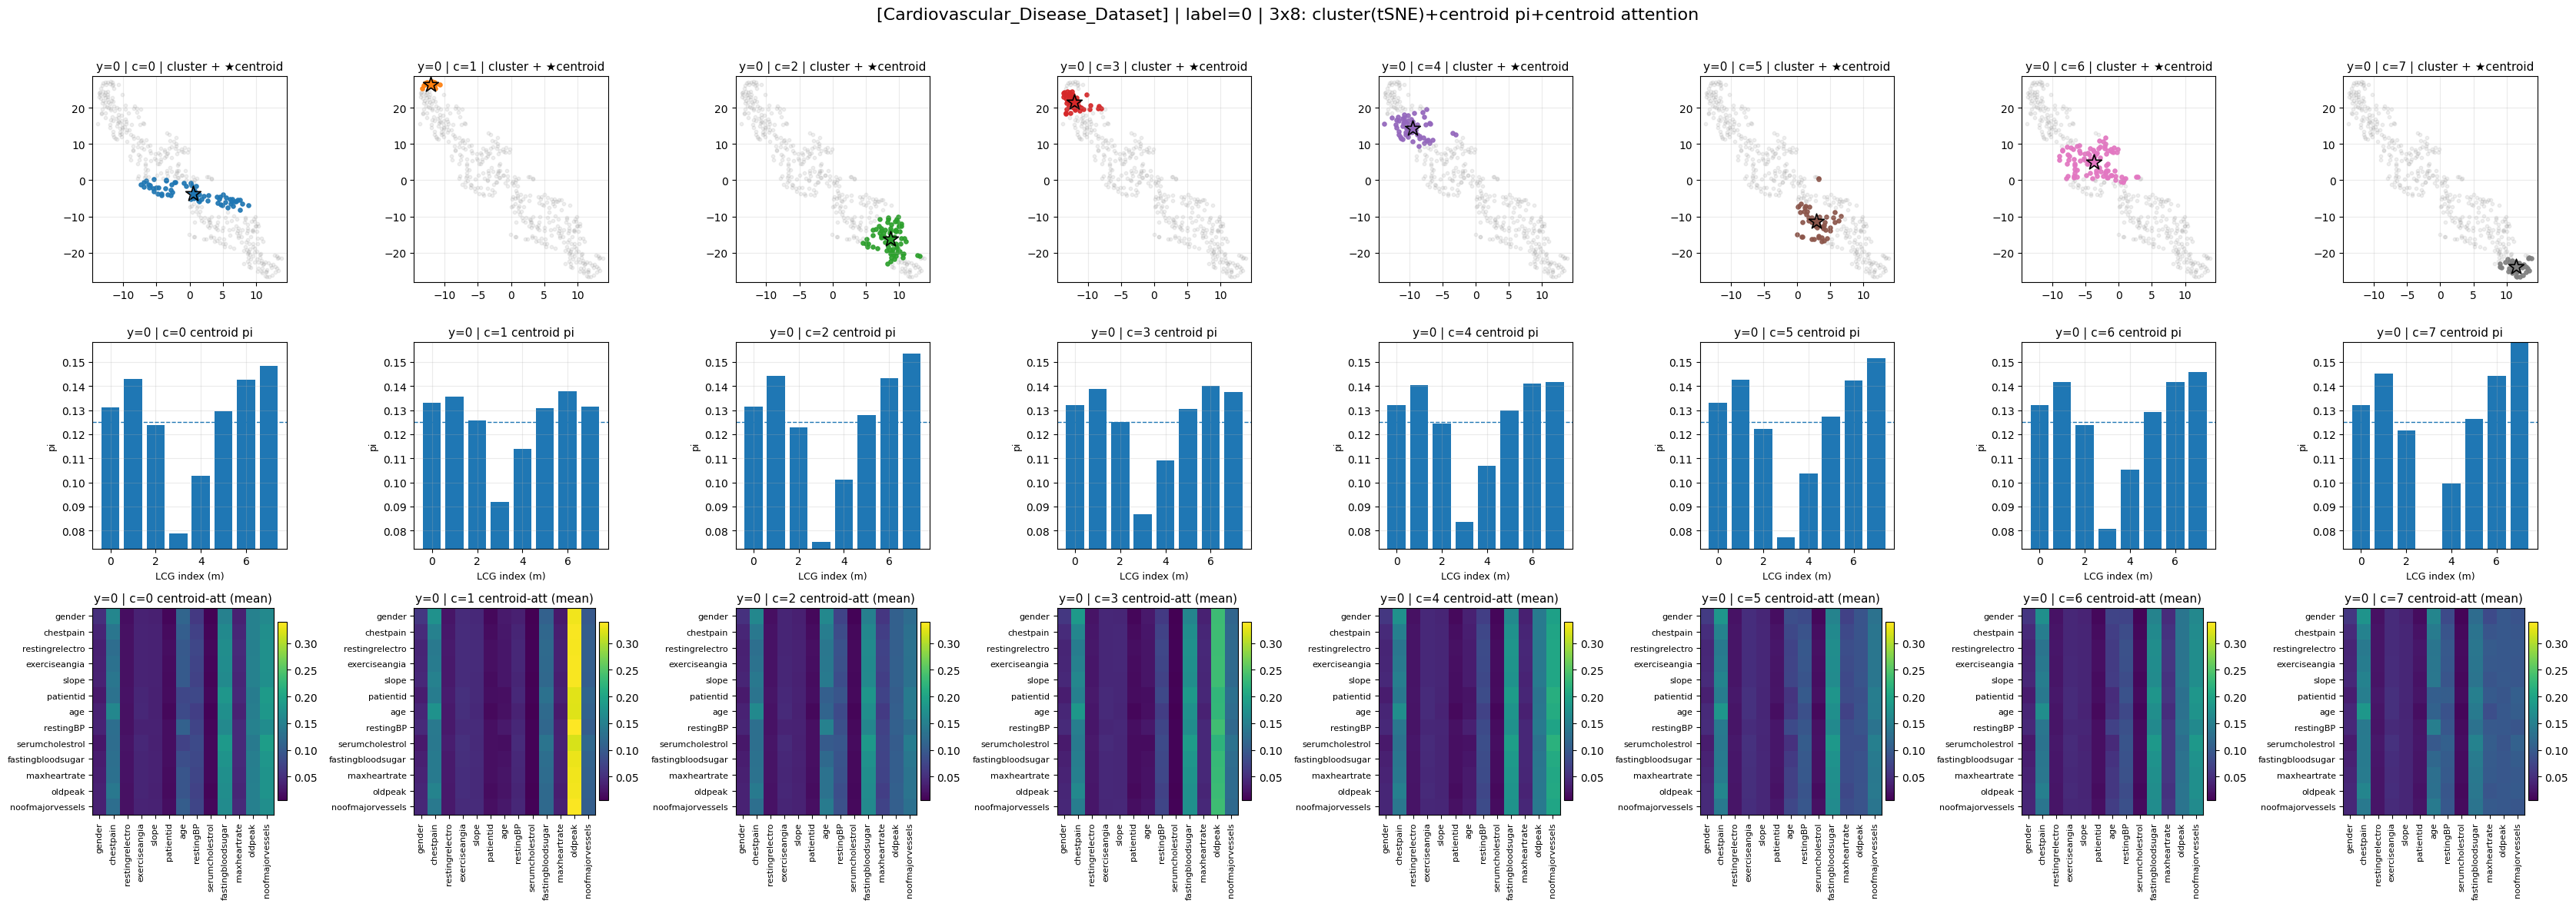

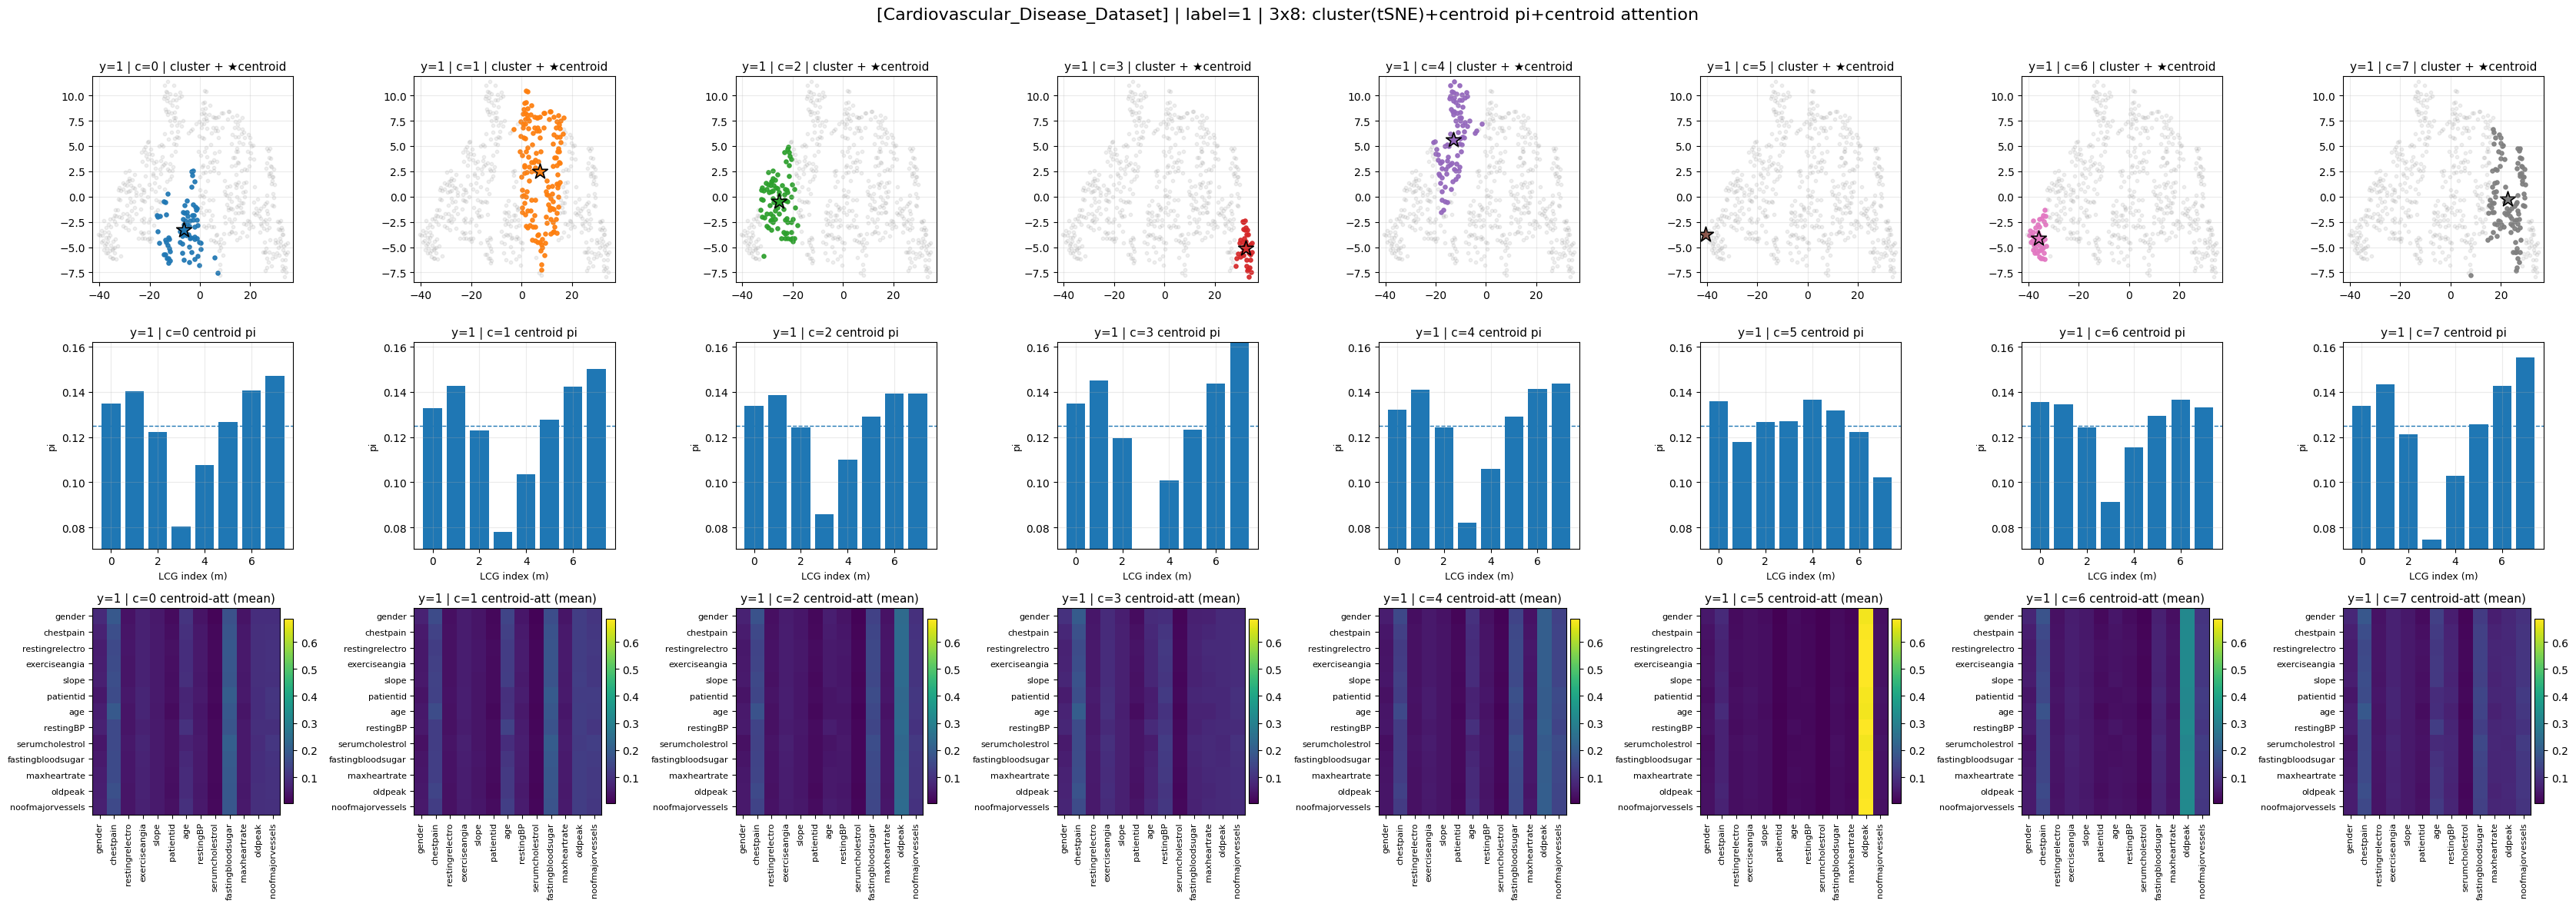

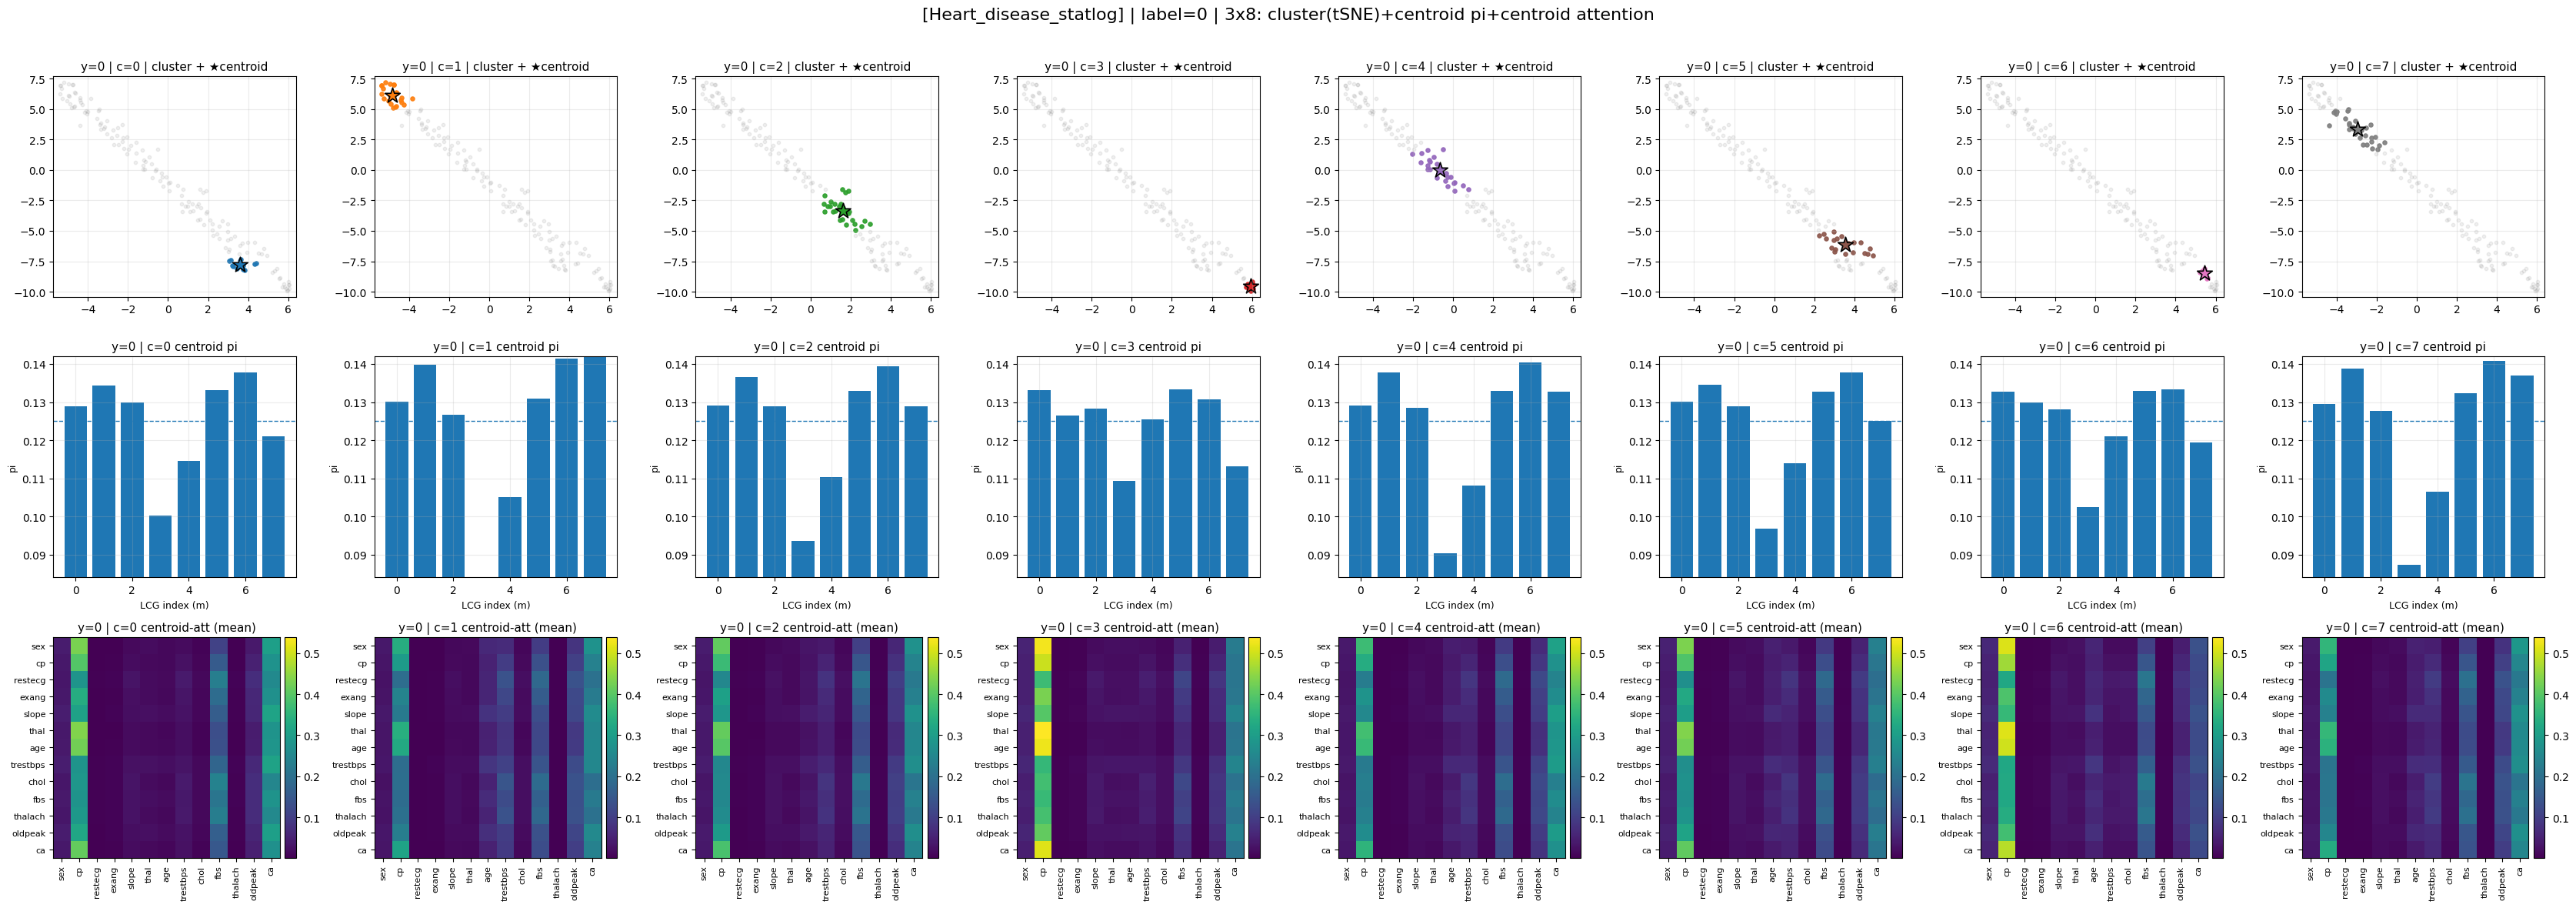

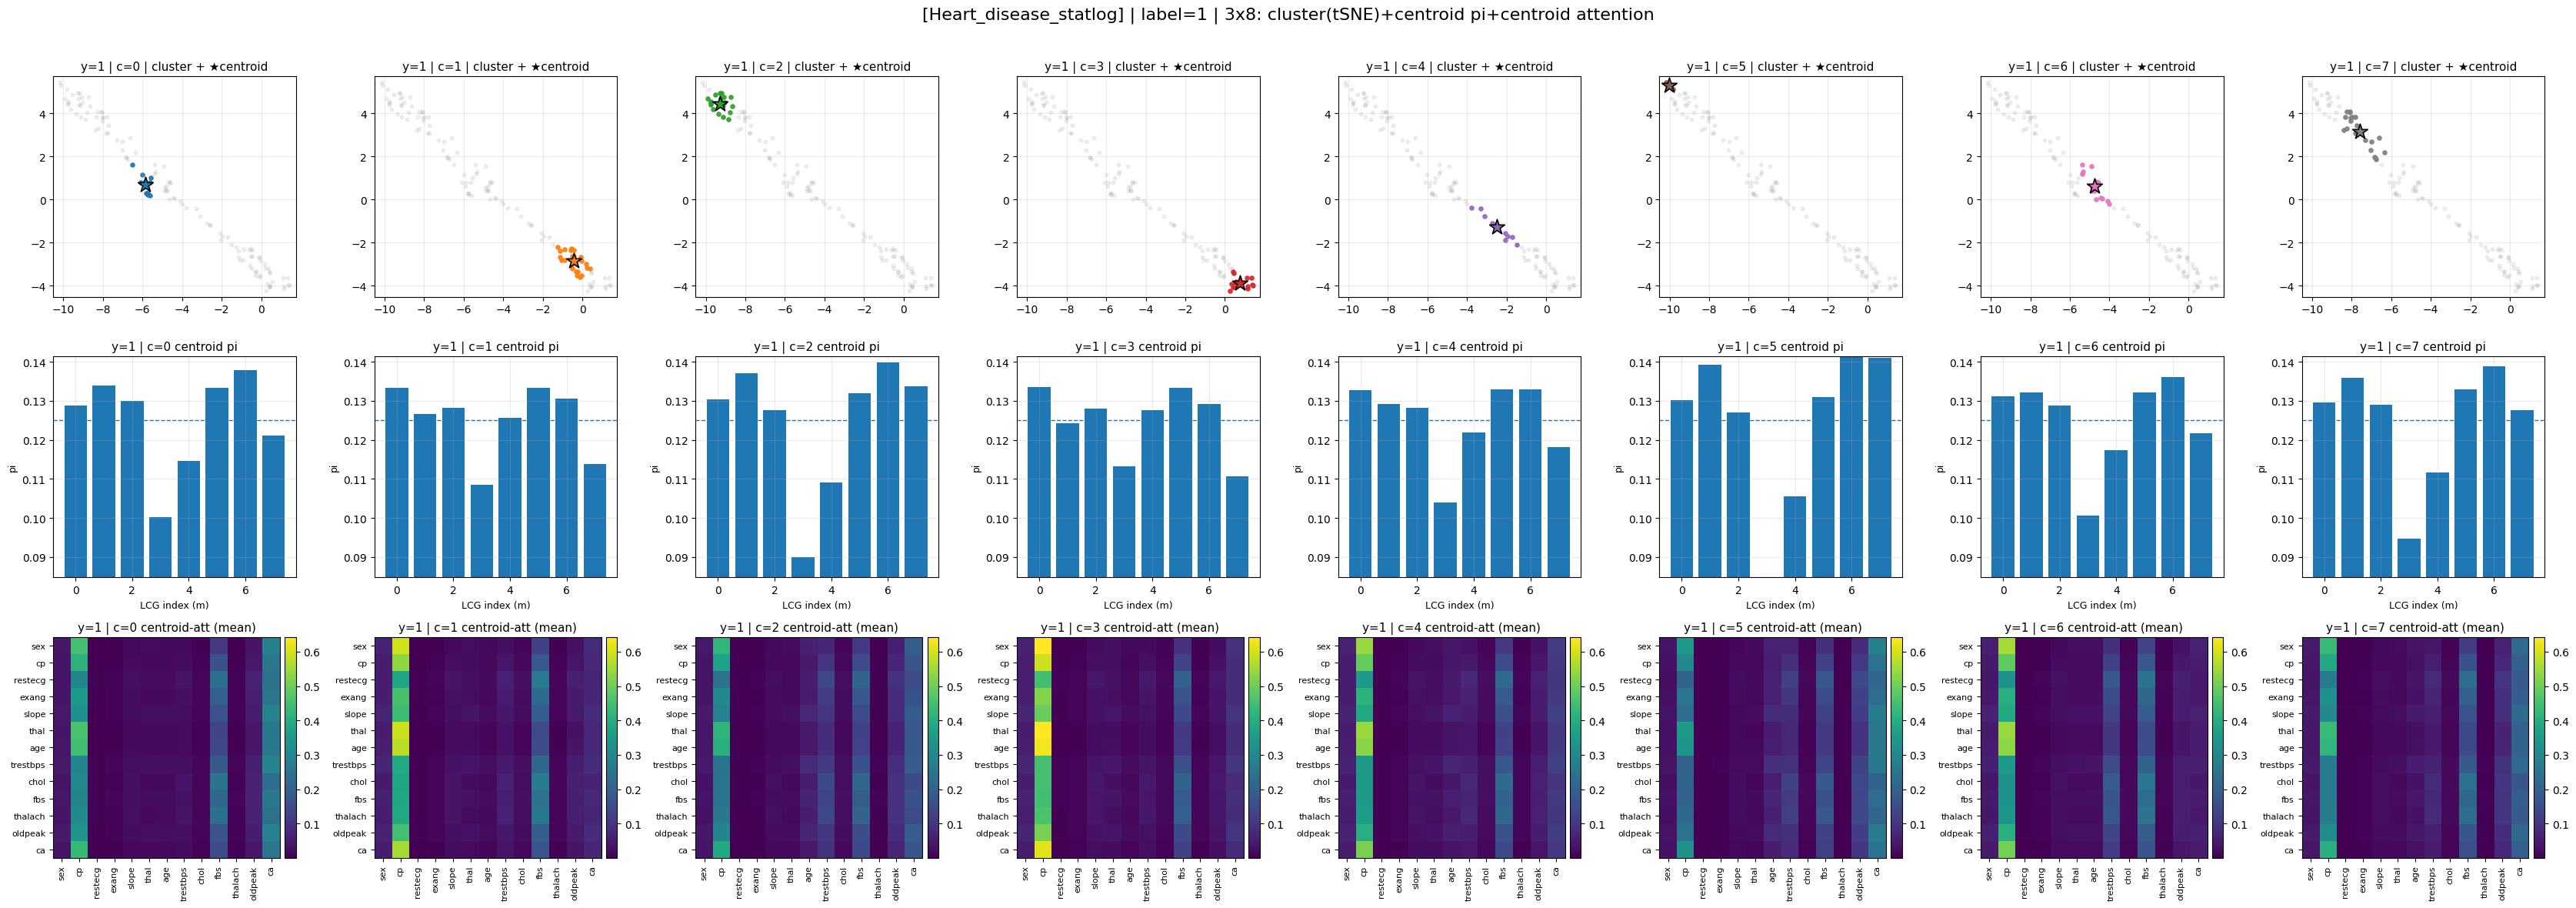

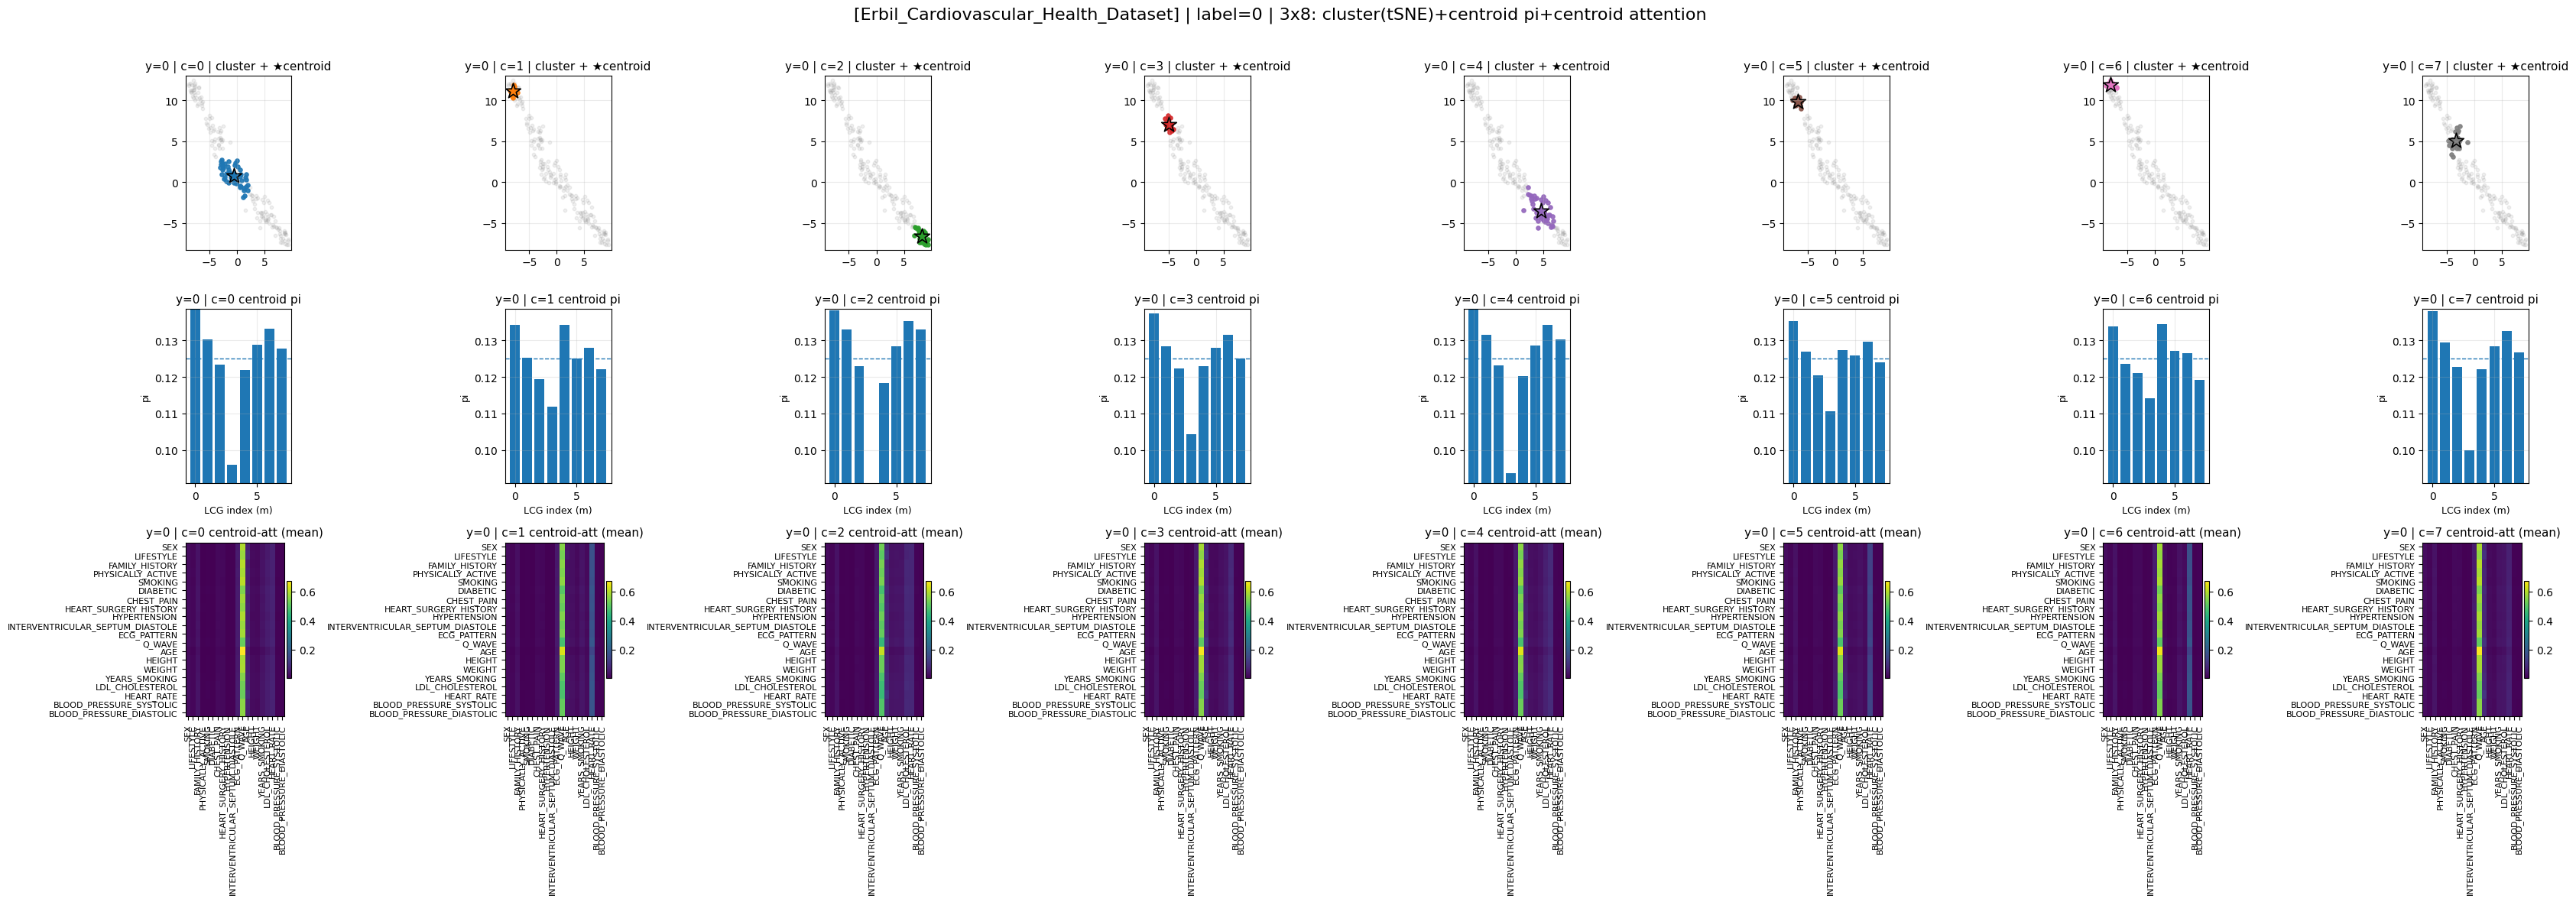

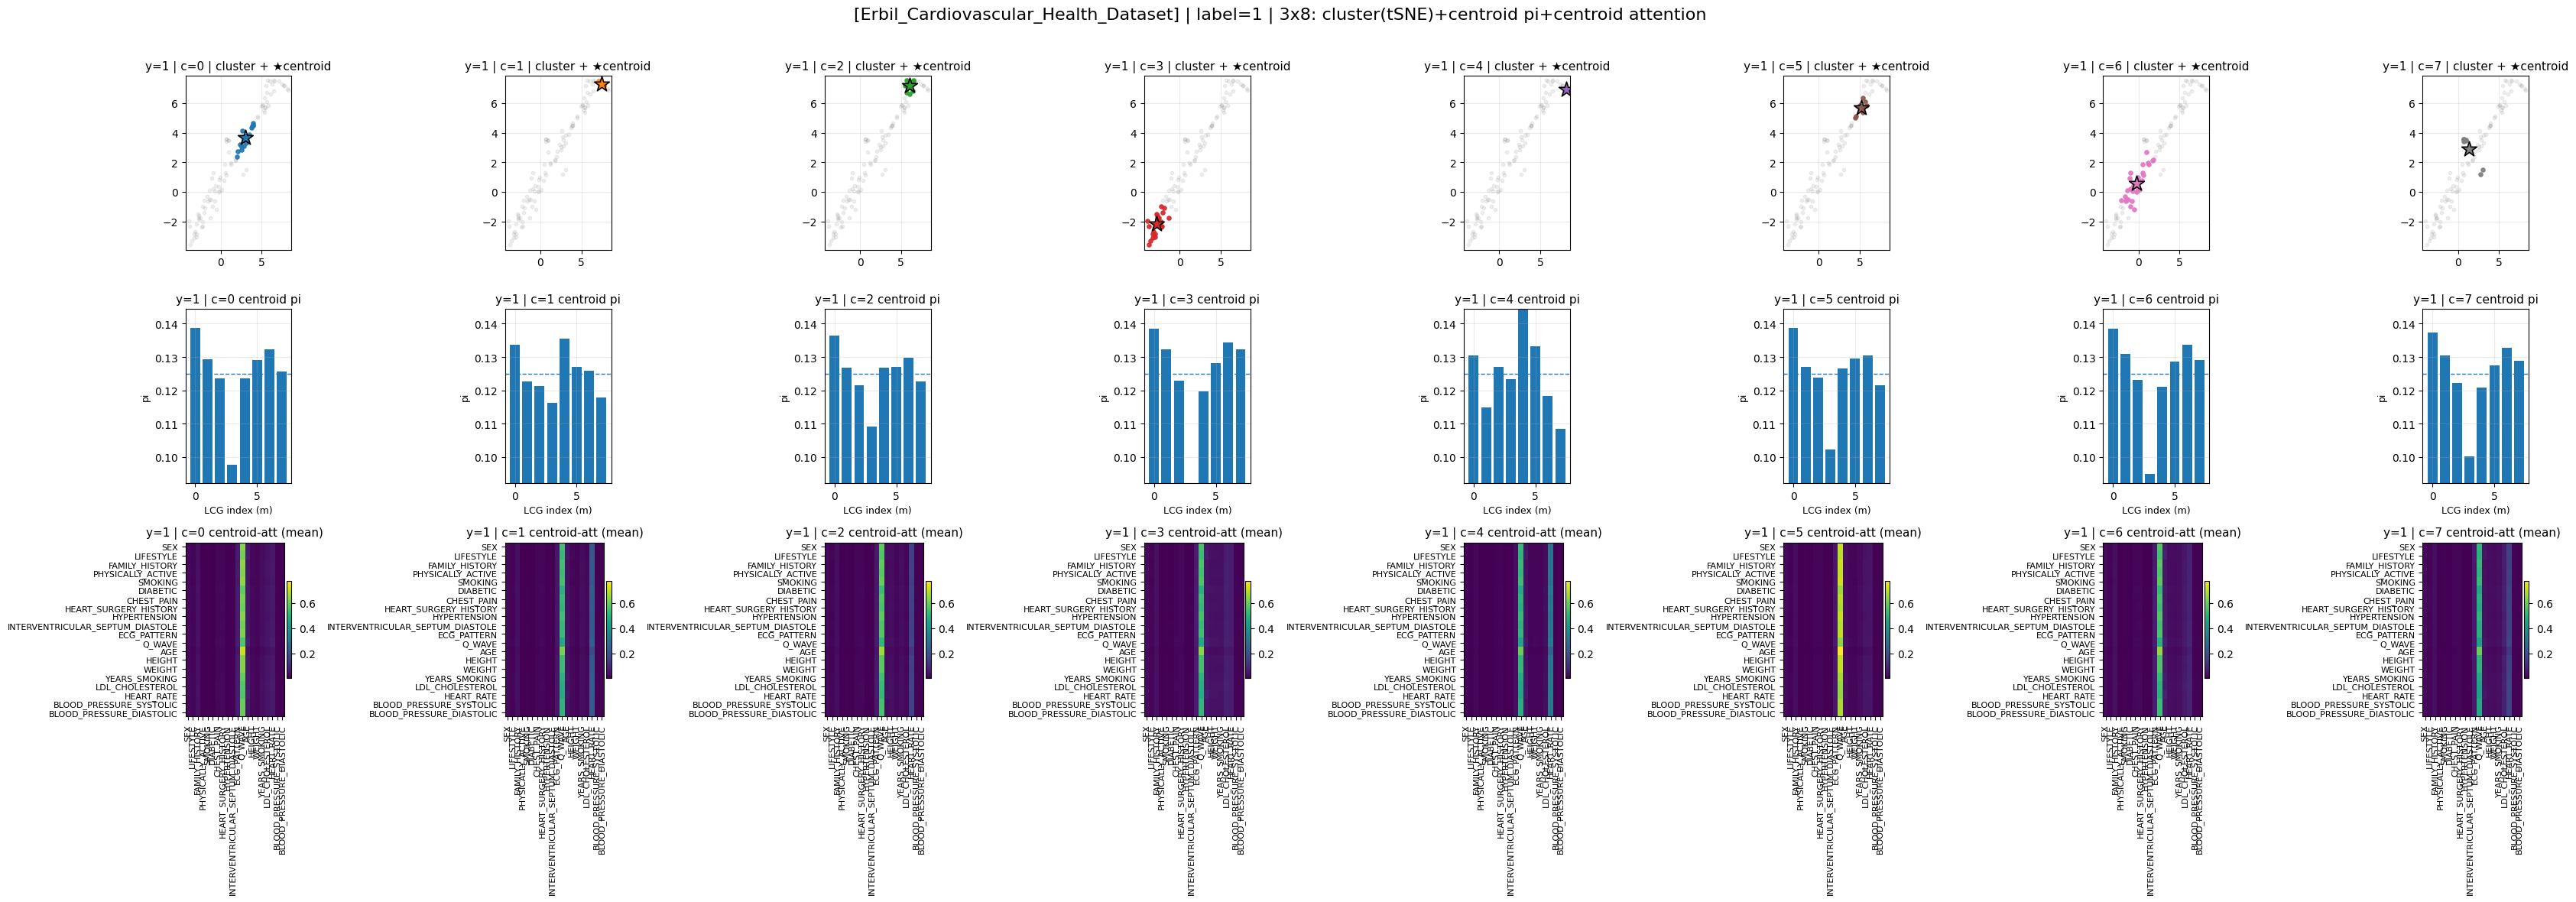

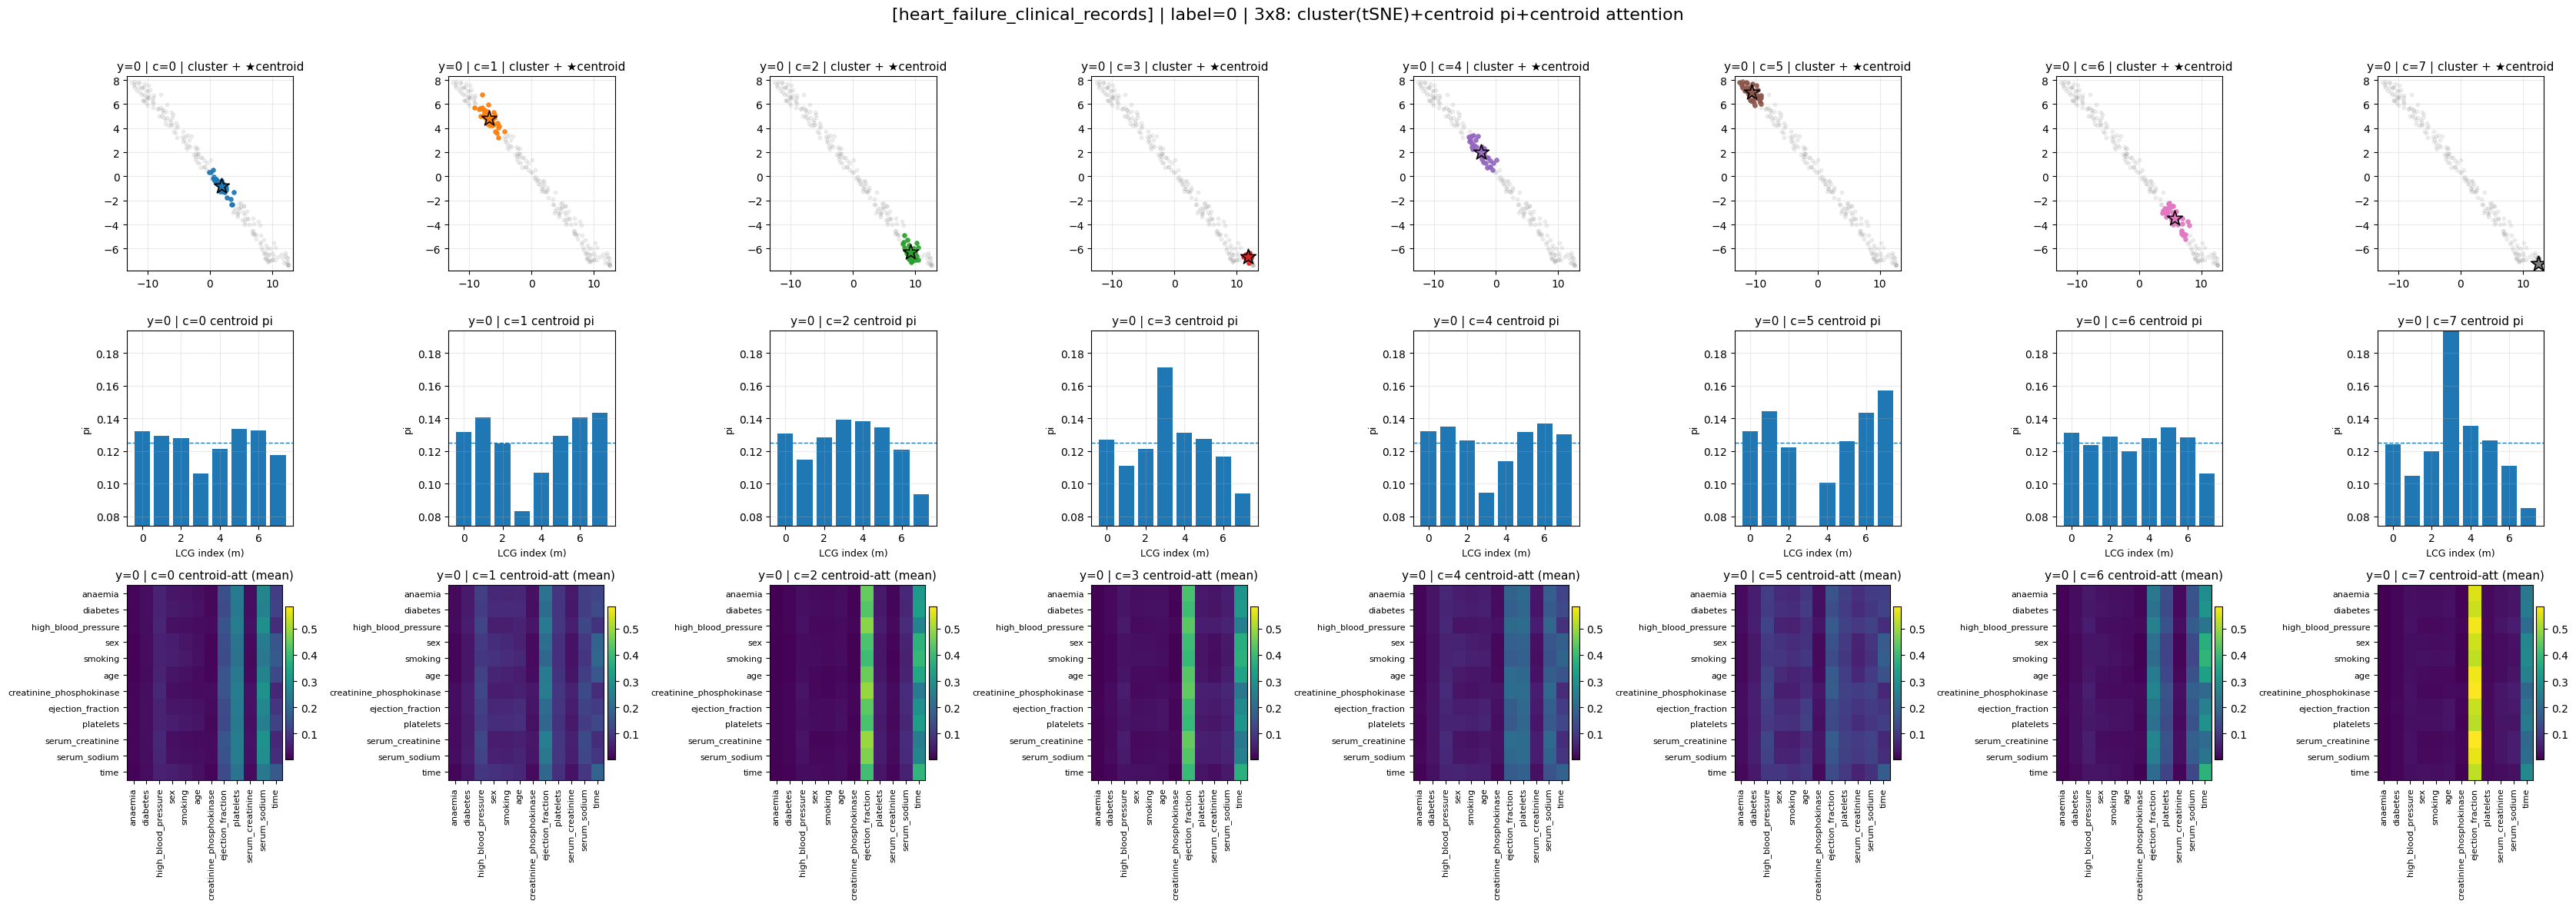

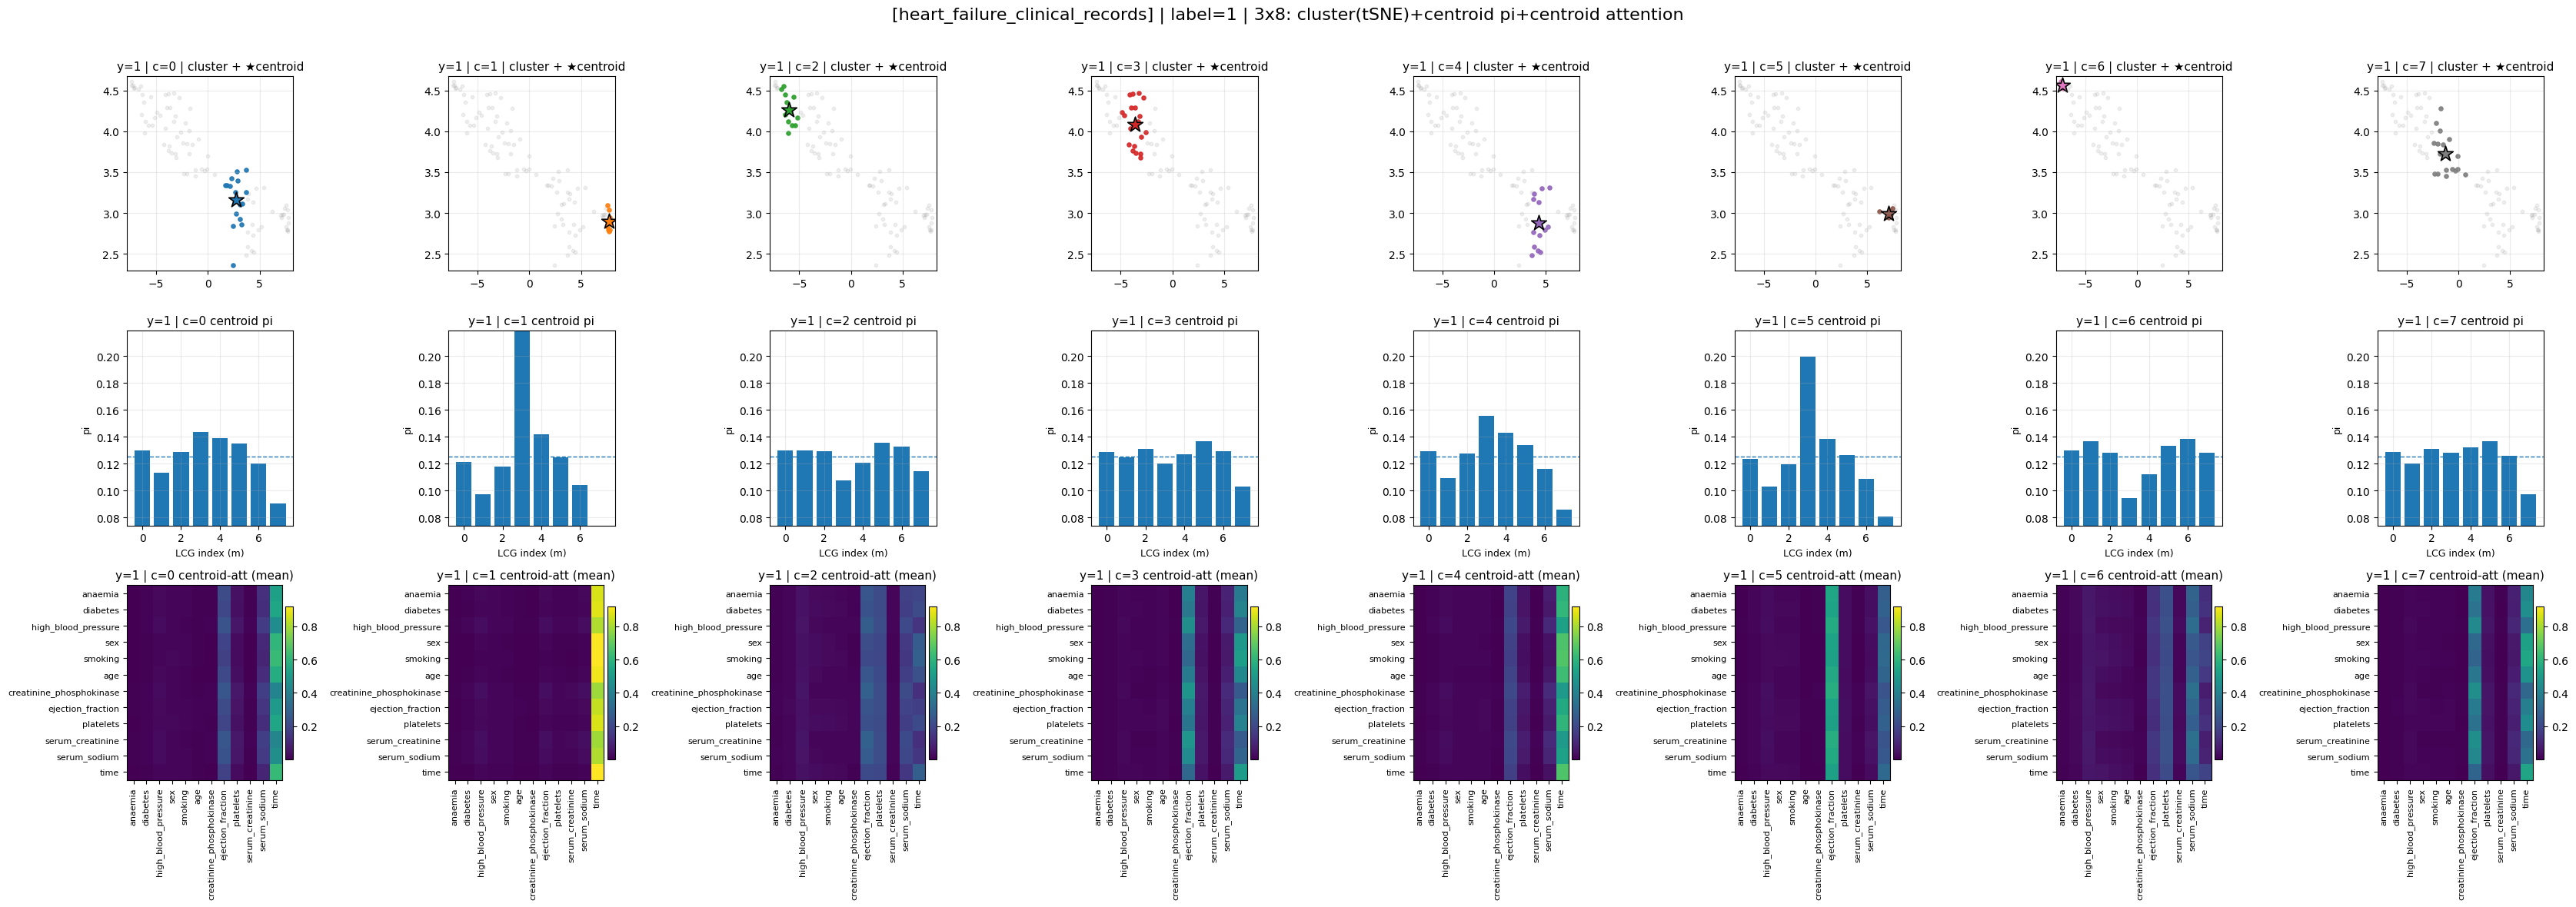

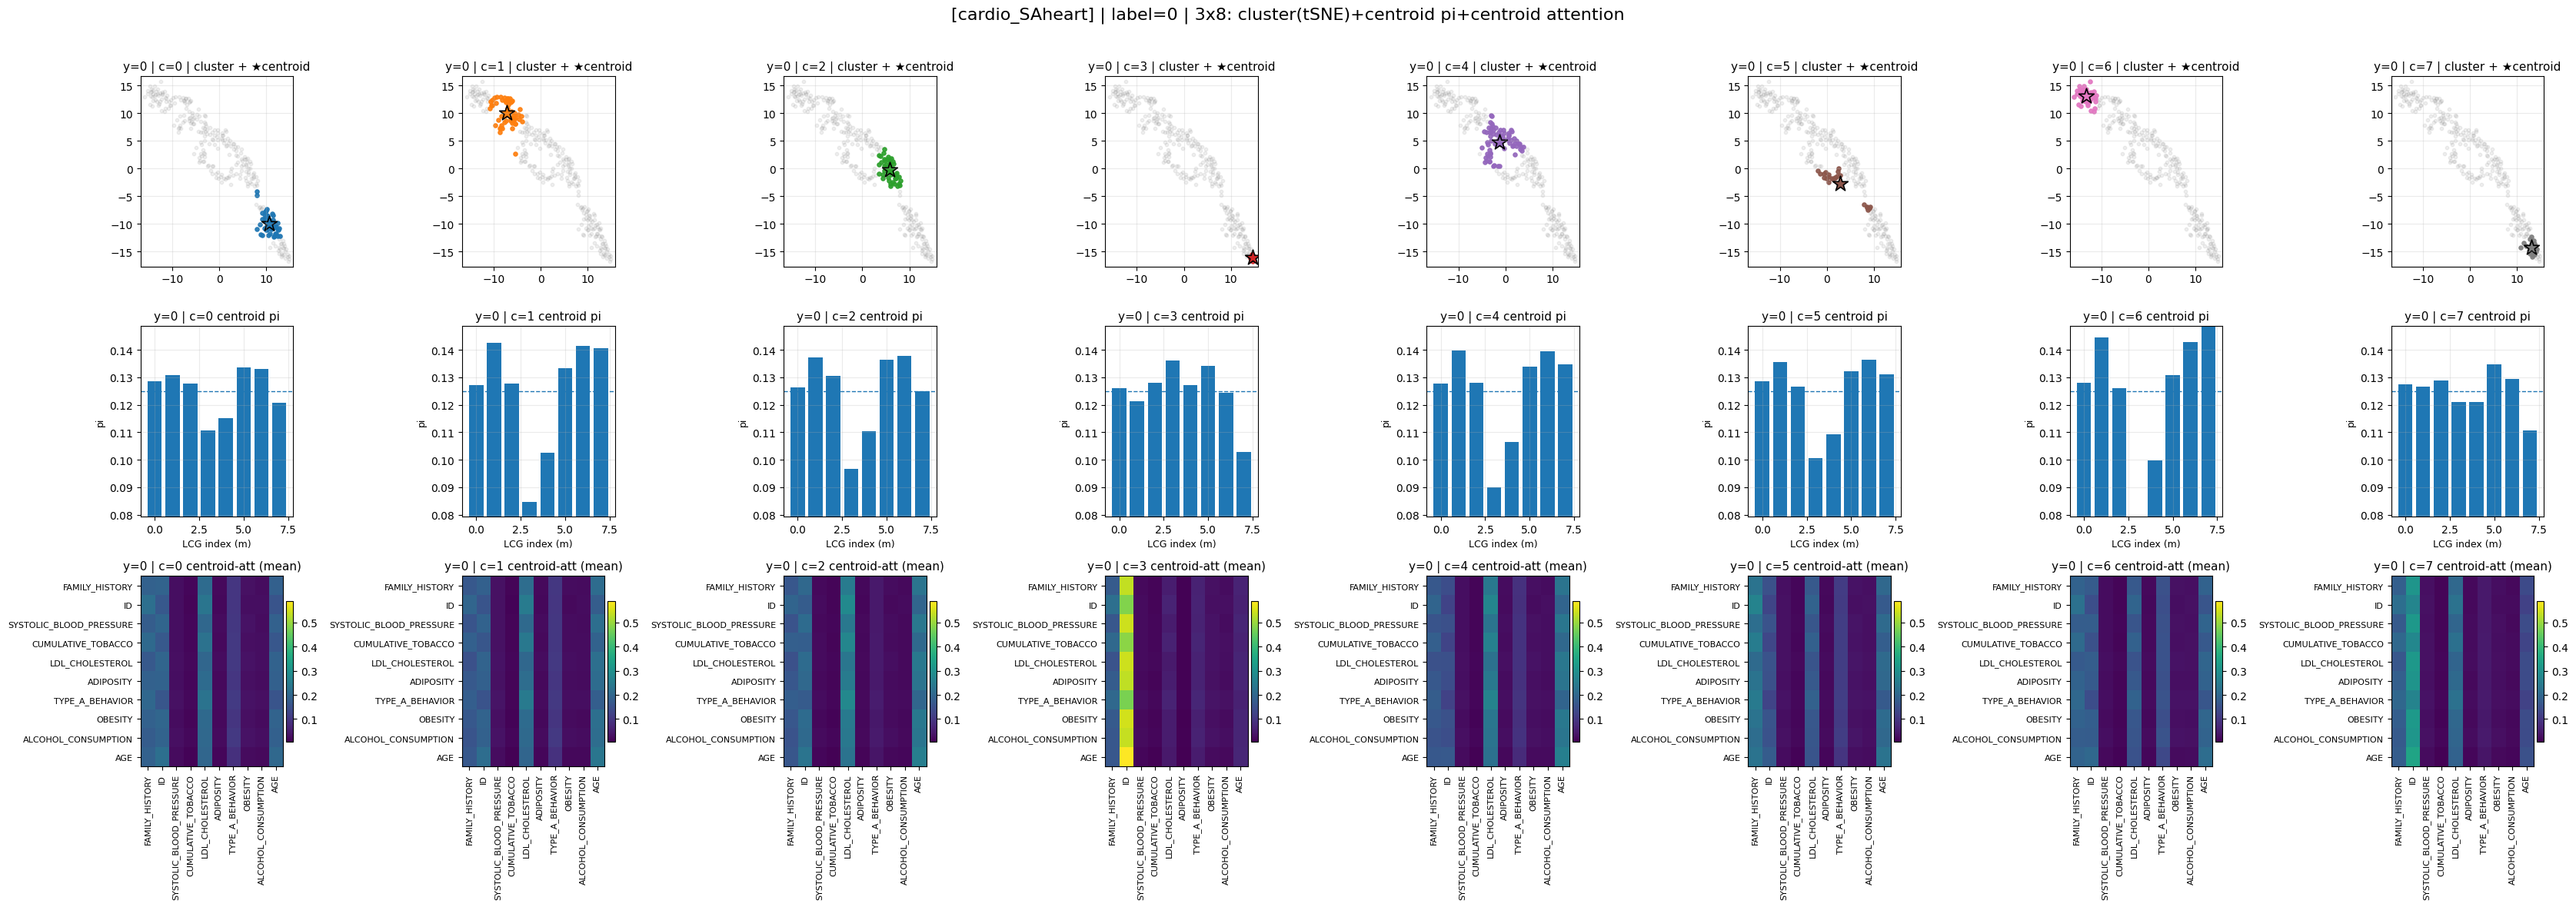

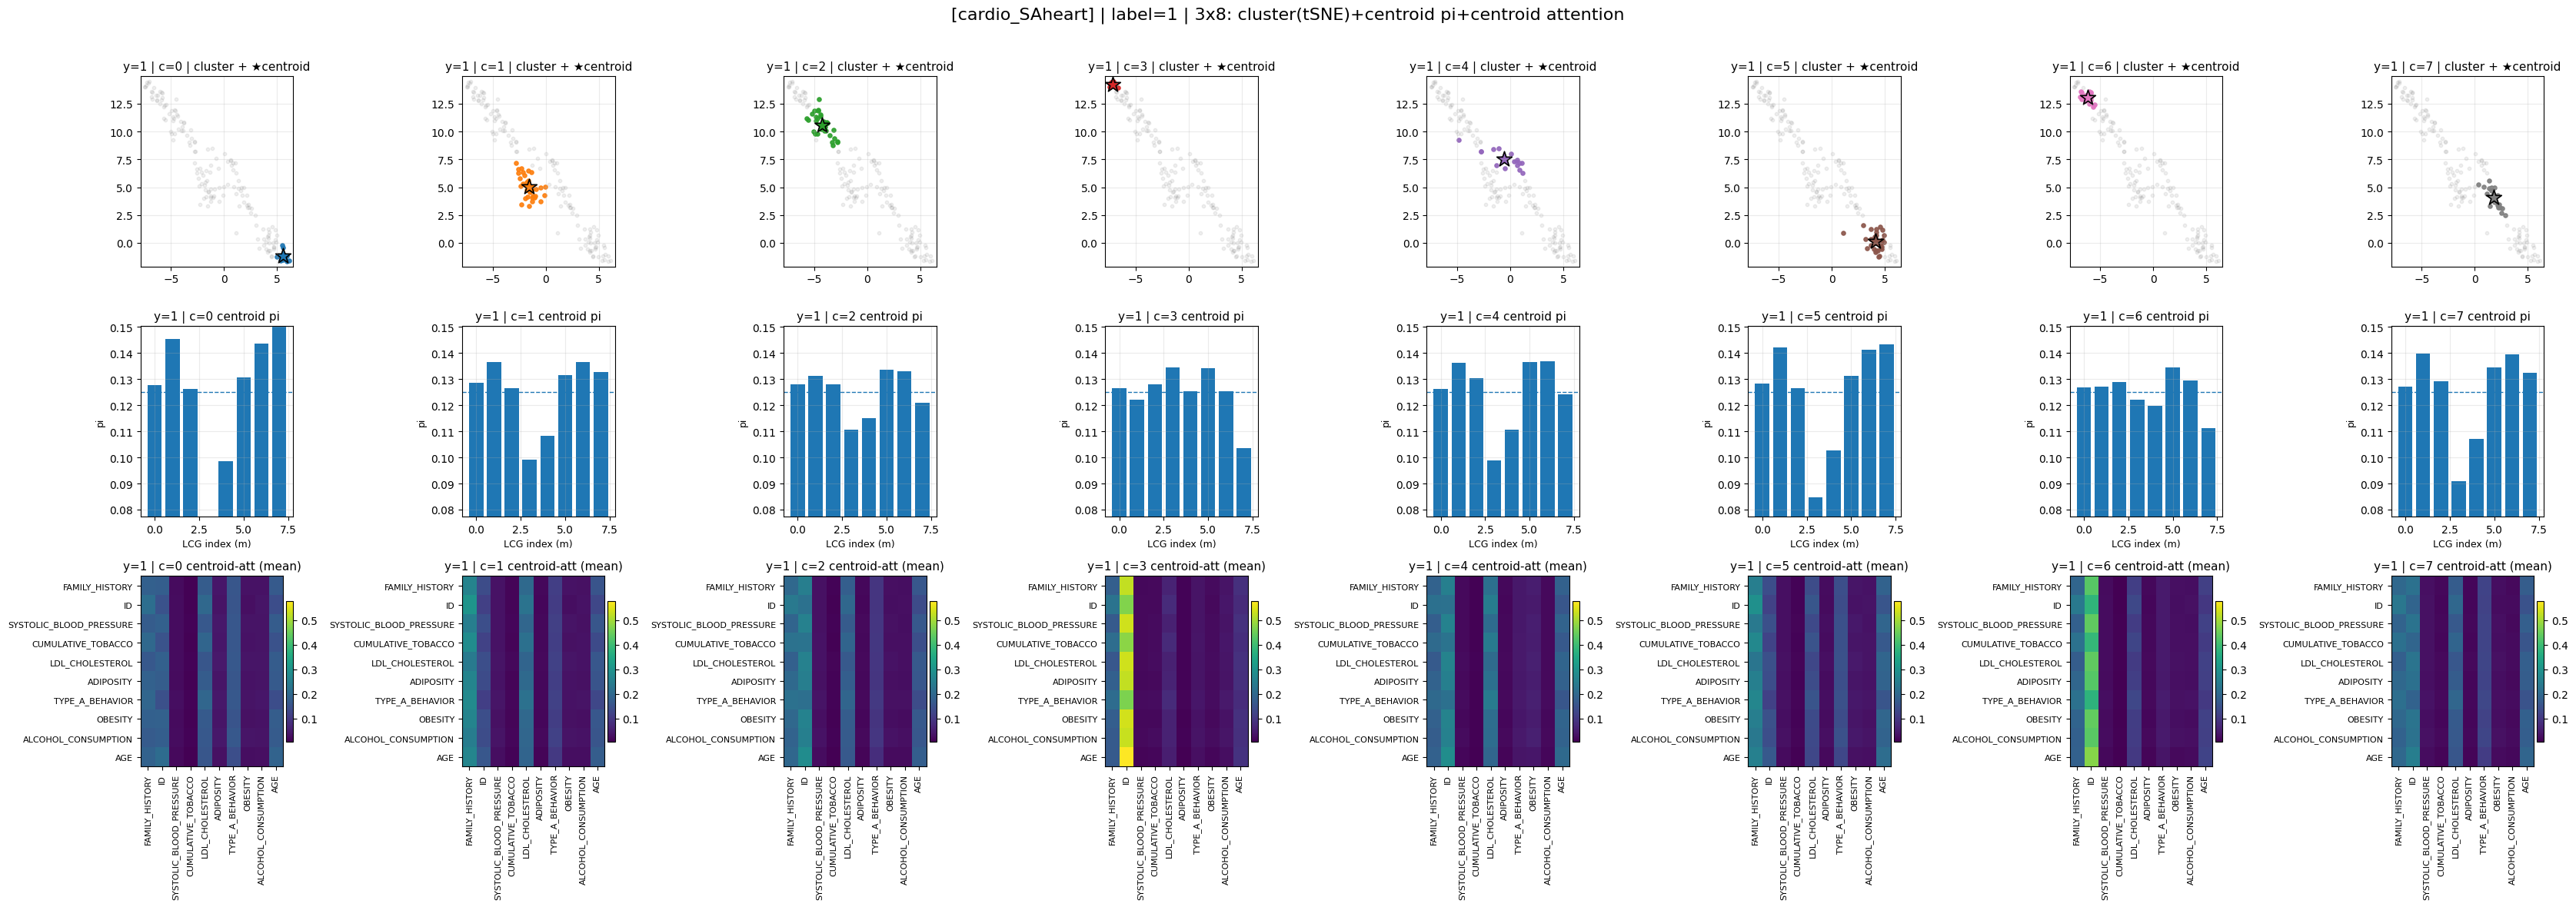

In [29]:
# args.source_data 기준으로 source들을 순회하면서,
# 각 source별로 (pis, ys, affs, names) 만들고 -> plot 호출

def run_centroid_pages_by_args_source_data(
    args, model, loaders, device,
    K=8, seed=42,
    title_prefix_fmt="[{}]"
):
    # args.source_data가 문자열 하나로 들어올 수도 있으니 방어적으로 처리
    src_list = args.source_data
    if isinstance(src_list, str):
        src_list = [src_list]

    for src_key in src_list:
        # loaders 키가 src_key랑 정확히 일치한다고 가정 (다르면 너가 쓰던 get_loader_by_key 써도 됨)
        assert src_key in loaders, f"loader not found: {src_key}, available={list(loaders.keys())}"
        loader = loaders[src_key]

        # 네가 이미 쓰던 수집 함수 사용 (이름만 맞춰)
        # return: pis(list/np), ys(list/np), affs(list), names(list)
        pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, loader, device)

        # numpy로 정리 (이미 numpy면 그대로 통과)
        pis = np.asarray(pis)
        ys  = np.asarray(ys)

        # label=0 한 장 + label=1 한 장
        plot_3xK_two_pages_by_label(
            pis, ys, affs, names,
            K=K, seed=seed,
            title_prefix=title_prefix_fmt.format(src_key)
        )

# ---- 실행 예시 ----
run_centroid_pages_by_args_source_data(
    args=args,
    model=model,
    loaders=loaders,
    device=device,
    K=8, seed=50,
    title_prefix_fmt="[{}]"
)


In [30]:
from copy import deepcopy
from torch.utils.data import ConcatDataset, DataLoader

args2 = deepcopy(args)
fix_seed(args2.random_seed)

loaders = {}

# ----------------------------
# 1) target 먼저 (full: train+val+test)
# ----------------------------
tgt = args2.target_data
if tgt is not None and str(tgt).strip() != "":
    print(f"Loading dataloader for TARGET: {tgt}")
    res = prepare_embedding_dataloaders(args2, tgt)
    tr, va, te = res["loaders"]

    ds_tgt = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    loaders[str(tgt)] = DataLoader(
        ds_tgt,
        batch_size=32,
        shuffle=False,
        drop_last=False,
        num_workers=0,      # 필요하면 늘려
        pin_memory=True     # GPU면 켜두는게 보통 유리
    )
else:
    print("WARNING: args2.target_data is empty/None. target loader will not be created.")

# ----------------------------
# 2) sources (full: train+val+test)
# ----------------------------
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]
sources = [s for s in sources if s is not None and str(s).strip() != ""]

for src in sources:
    # target과 중복이면 skip (원하면 주석처리)
    if str(src) in loaders:
        continue

    print(f"Loading dataloader for SOURCE: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res["loaders"]

    ds_src = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    loaders[str(src)] = DataLoader(
        ds_src,
        batch_size=32,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=True
    )

print("Available loaders:", list(loaders.keys()))


>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for TARGET: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 791
Validation data size: 264
Test data size: 264
Loading dataloader for SOURCE: heart
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 550
Validation data size: 184
Test data size: 184
Loading dataloader for SOURCE: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 600
Validation data size: 200
Test data size: 200
Loa

### Target

In [31]:
# Target 모델 로드


target_ckpt = torch.load(target_rr_ckpt_path, map_location=device)
target_args = target_ckpt['args']

print("=== Target Checkpoint Info ===")
print(f"Epoch: {target_ckpt.get('epoch', 'unknown')}")
print(f"Val AUC: {target_ckpt.get('val_auc', 'unknown')}")
print(f"Threshold: {target_ckpt.get('threshold', 'unknown')}")
print(f"Keys: {list(target_ckpt.keys())}")

# Target 모델 초기화
target_rr_model = Model(
    target_args,
    target_args.input_dim,
    target_args.hidden_dim,
    target_args.output_dim,
    target_args.dropout_rate,
    target_args.llm_model,
    experiment_id="target_viz",
    mode="Few"
).to(device)

target_sd = target_ckpt['model_state_dict']
missing, unexpected = target_rr_model.load_state_dict(target_sd, strict=False)
print("\nTarget Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

target_rr_model.eval()

=== Target Checkpoint Info ===
Epoch: 82
Val AUC: 0.9061365286855483
Threshold: 0.37038224935531616
Keys: ['model_state_dict', 'epoch', 'val_auc', 'val_auprc', 'threshold', 'args']

Target Model Loaded
Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=192, bias=True)
    (k_proj): Linear(in_features=768, out_features=192, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.2, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_

In [32]:
# Target 데이터 준비 - 간단하게
target_name = target_args.target_data
print(f"\nTarget dataset: {target_name}")

# loaders dict 확인
print(f"Available loaders: {list(loaders.keys())}")

# Target loader 찾기
if target_name in loaders:
    target_loader = loaders[target_name]
    print(f"✓ Found target loader: {target_name}")
else:
    print(f"✗ Target '{target_name}' not in loaders")
    print("Available sources:", list(loaders.keys()))
    # 아무거나 하나 쓰거나 물어보자
    target_loader = list(loaders.values())[0]
    print(f"Using first available loader instead")


Target dataset: Medicaldataset
Available loaders: ['Medicaldataset', 'heart', 'Cardiovascular_Disease_Dataset', 'Heart_disease_statlog', 'Erbil_Cardiovascular_Health_Dataset', 'heart_failure_clinical_records', 'cardio_SAheart']
✓ Found target loader: Medicaldataset


In [33]:
# Target 데이터 로드
from dataset.data_dataloaders import prepare_embedding_dataloaders

print(f"\nLoading target dataset: {target_args.target_data}")

r_t = prepare_embedding_dataloaders(target_args, target_args.target_data)
train_loader_t, val_loader_t, test_loader_t = r_t['loaders']
num_classes_t = r_t['num_classes']

print(f"✓ Target loaded")
print(f"  Num classes: {num_classes_t}")

# Test loader 사용
target_loader = test_loader_t
print(f"  Test samples: {len(test_loader_t.dataset)}")
# Target 샘플 수집
print("\nCollecting target samples...")
target_embeddings, target_affinities, target_labels, target_feature_names = collect_all_samples_from_source(
    target_rr_model, target_loader, target_args.target_data
)

print(f"Total collected: {len(target_embeddings)}")
print(f"Label 0: {(np.array(target_labels) == 0).sum()}")
print(f"Label 1: {(np.array(target_labels) == 1).sum()}")


Loading target dataset: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 791
Validation data size: 264
Test data size: 264
✓ Target loaded
  Num classes: 2
  Test samples: 264

Total collected: 264
Label 0: 102
Label 1: 162


In [34]:
# Frobenius distance 계산
print("\nComputing Frobenius distances...")
target_emb_distances, target_aff_distances = compute_frobenius_distances(
    target_embeddings, target_affinities
)


Computing Frobenius distances...


In [35]:
# Reference, Similar, Different 선택
target_ref_idx = 0

target_sim_idx, target_diff_idx = find_most_similar_and_different_by_label(
    target_ref_idx, target_aff_distances, target_labels
)

print(f"\n=== Target Sample Selection ===")
print(f"Reference: idx={target_ref_idx}, label={target_labels[target_ref_idx]}")
print(f"Similar (same label): idx={target_sim_idx}, label={target_labels[target_sim_idx]}")
print(f"  → Affinity Frob: {target_aff_distances[target_ref_idx, target_sim_idx]:.4f}")
print(f"Different (other label): idx={target_diff_idx}, label={target_labels[target_diff_idx]}")
print(f"  → Affinity Frob: {target_aff_distances[target_ref_idx, target_diff_idx]:.4f}")


=== Target Sample Selection ===
Reference: idx=0, label=1
Similar (same label): idx=8, label=1
  → Affinity Frob: 0.0982
Different (other label): idx=68, label=0
  → Affinity Frob: 2.0611



Computing transport plans...

=== Target Pi (Coordinates) ===
Reference: [0.12199894 0.13407834 0.13483925 0.10652715 0.11335506 0.1402557
 0.13371556 0.11523   ]
Similar: [0.12186448 0.13740142 0.13367    0.10156197 0.11085247 0.13922644
 0.13638858 0.11903468]
Different: [0.12360319 0.12141854 0.13634591 0.14037178 0.12994866 0.13680294
 0.12309583 0.08841318]


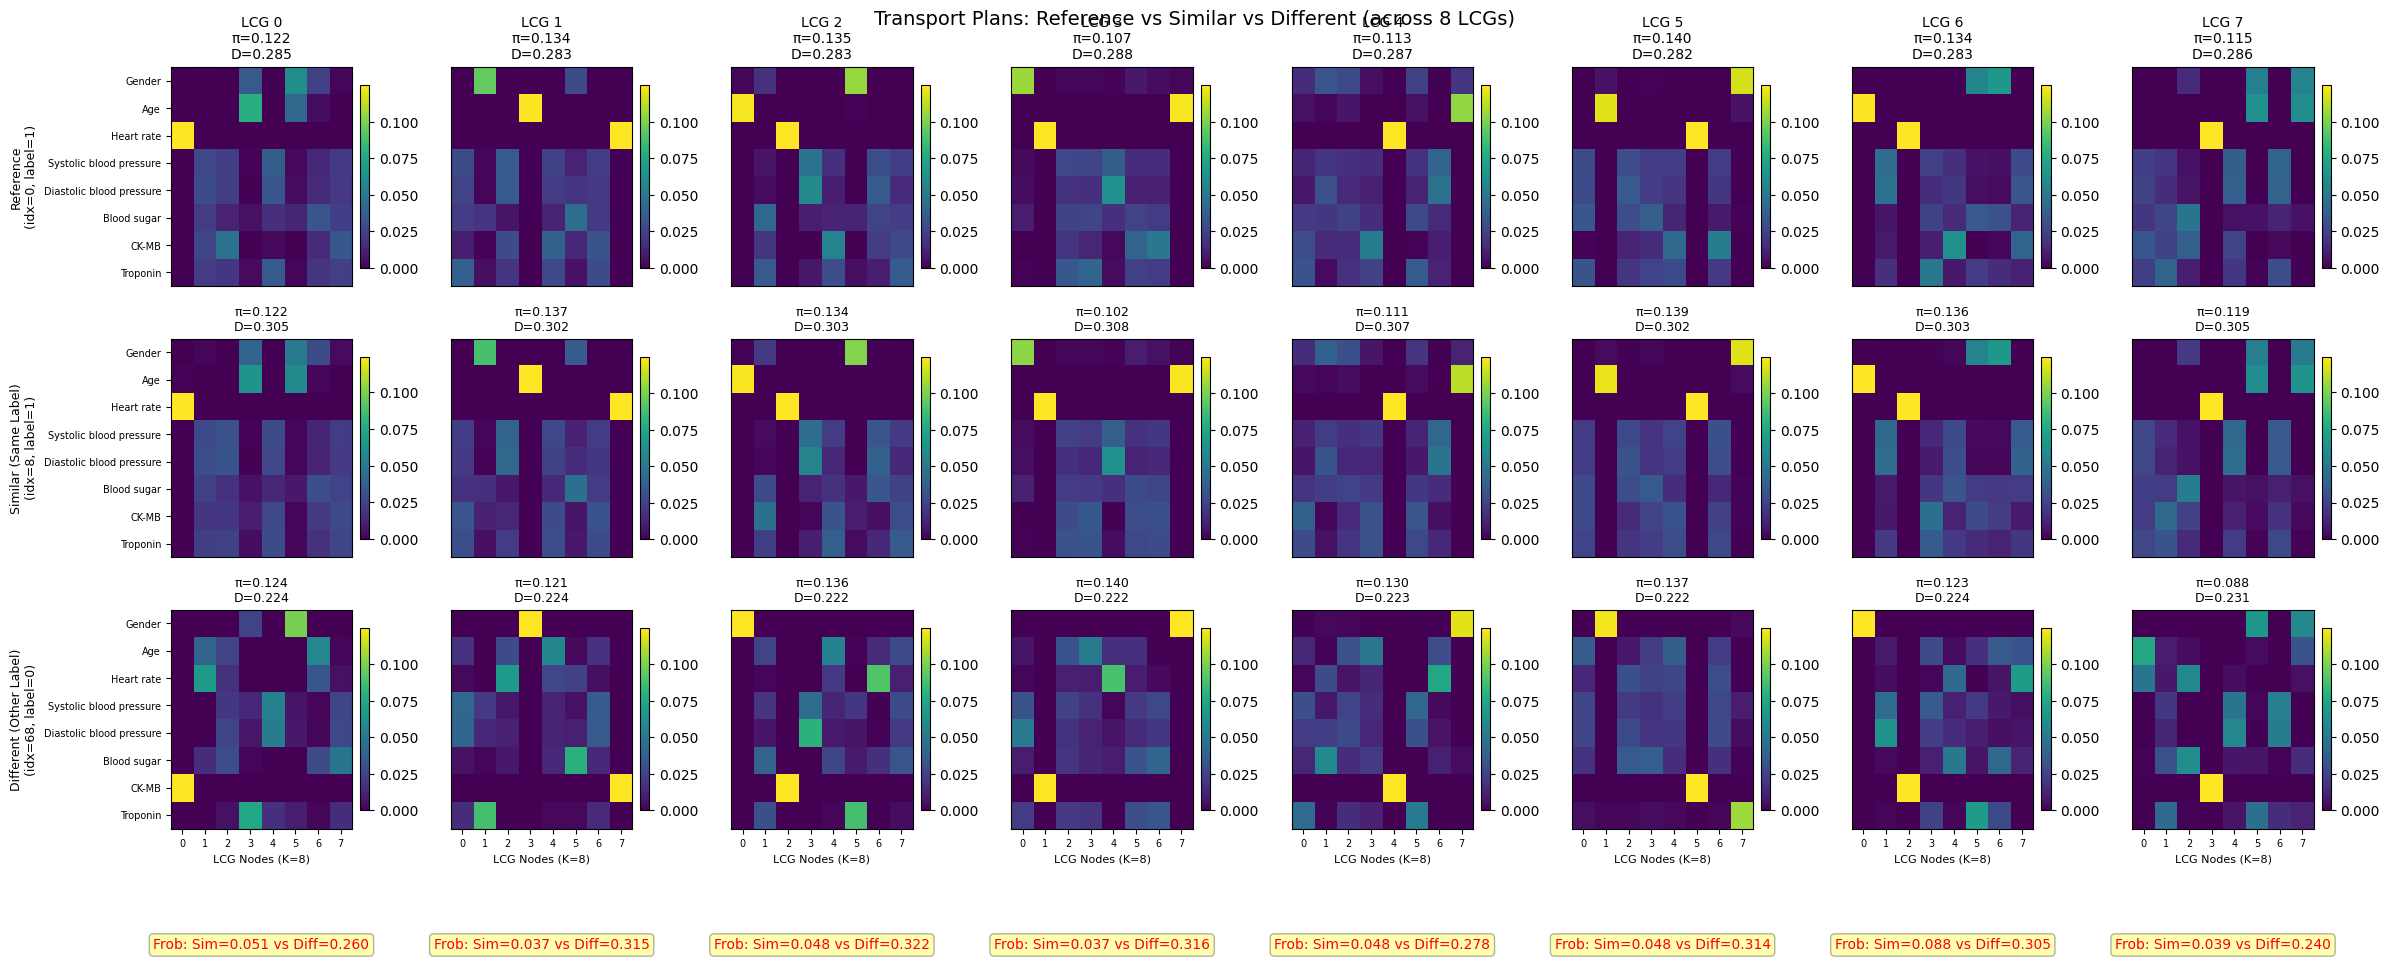

In [36]:
# Transport Plans 계산
print("\nComputing transport plans...")
target_sample_indices = [target_ref_idx, target_sim_idx, target_diff_idx]

target_plans, target_distances, target_coordinates = compute_transport_plans_for_samples(
    target_rr_model, target_sample_indices, target_embeddings, target_affinities
)

print("\n=== Target Pi (Coordinates) ===")
print("Reference:", target_coordinates[0])
print("Similar:", target_coordinates[1])
print("Different:", target_coordinates[2])
# Transport Plans 시각화
plot_transport_plans_grid(
    target_plans, target_coordinates, target_distances,
    target_sample_indices, target_labels, target_feature_names[0]
)

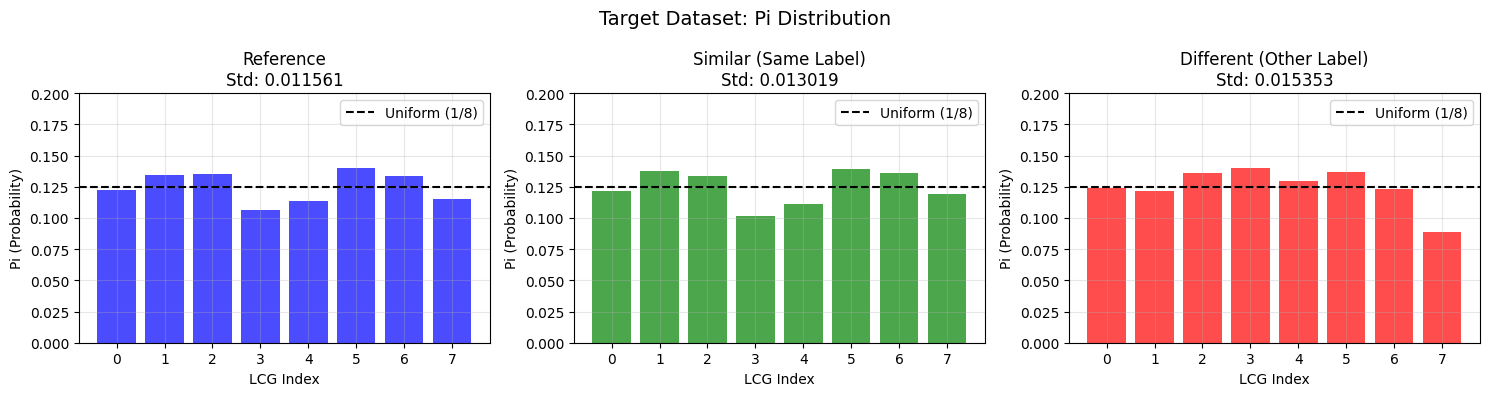

In [37]:
# Pi 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(target_coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Target Dataset: Pi Distribution', fontsize=14)
plt.tight_layout()
plt.show()

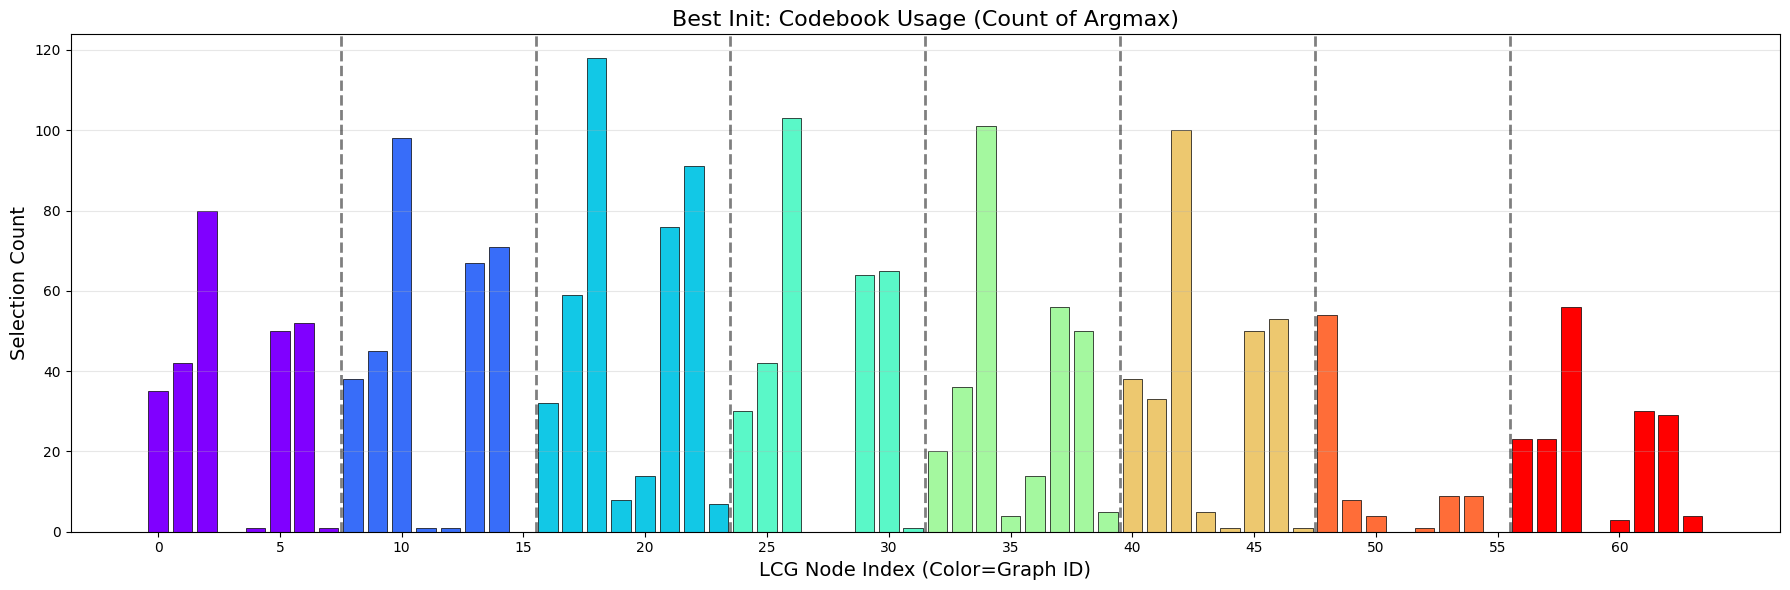


=== Codebook Usage Statistics (Argmax) ===
Total assignments: 2112
LCG 0:   261 (12.4%)
  → Most used node: 2 (80 times)
LCG 1:   321 (15.2%)
  → Most used node: 2 (98 times)
LCG 2:   405 (19.2%)
  → Most used node: 2 (118 times)
LCG 3:   305 (14.4%)
  → Most used node: 2 (103 times)
LCG 4:   286 (13.5%)
  → Most used node: 2 (101 times)
LCG 5:   281 (13.3%)
  → Most used node: 2 (100 times)
LCG 6:    85 (4.0%)
  → Most used node: 0 (54 times)
LCG 7:   168 (8.0%)
  → Most used node: 2 (56 times)


In [38]:
# Codebook Usage (Argmax)
print("\nCollecting codebook usage for target...")
target_assignments, target_source_labels = collect_all_source_assignments(
    target_rr_model, {target_args.target_data: target_loader}, 
    [target_args.target_data], device
)

plot_codebook_usage_argmax(
    target_assignments, target_source_labels, 
    [target_args.target_data], M=8, K=8
)

In [39]:
@torch.no_grad()
def collect_all_cls_embeddings(model, loaders, device):
    """
    모든 loader의 CLS embeddings 수집
    
    Returns:
        cls_embeddings: [N_total, D] - 모든 CLS embeddings
    """
    all_cls_tokens = []
    model.eval()
    
    for src_name, loader in loaders.items():
        print(f"   - Collecting CLS from: {src_name}")
        for batch in loader:
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                    for k, v in batch.items()}
            
            # name/value embeddings
            name_embs, val_embs = [], []
            if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
            if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
            if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
            if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
            
            if not name_embs: continue
            
            name = torch.cat(name_embs, dim=1)
            val = torch.cat(val_embs, dim=1)
            
            # CLS + value
            x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
            
            # GAT forward
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, _ = model.basis_layers[l](name, norm_x)
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
            
            # CLS token
            cls_token = x_basis[:, 0, :].cpu().numpy()
            all_cls_tokens.append(cls_token)
    
    return np.concatenate(all_cls_tokens, axis=0)

[Medicaldataset] N=264 | M=8 | n(y=0)=102 | n(y=1)=162
- L2(pi, uniform) | y=0: mean=0.048895, std=0.014562 | y=1: mean=0.041674, std=0.013600
- Entropy(pi)     | y=0: mean=2.068415, std=0.006480 | y=1: mean=2.071342, std=0.005372
- Max(pi)         | y=0: mean=0.143293, std=0.006302 | y=1: mean=0.140689, std=0.004497


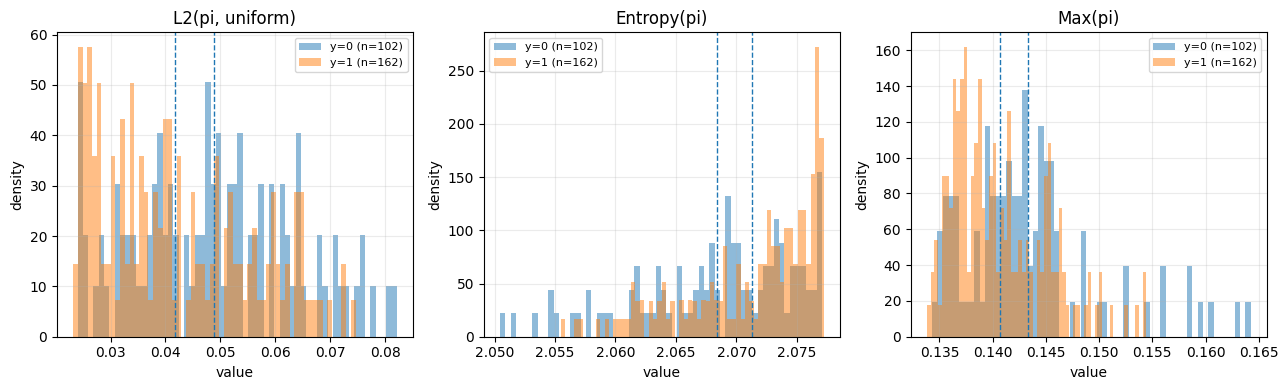

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def summarize_pi_by_label(pis, ys, title_prefix="[Medicaldataset]"):
    pis = np.asarray(pis)          # [N, M]
    ys  = np.asarray(ys).astype(int)

    M = pis.shape[1]
    u = np.ones(M) / M
    eps = 1e-12

    # vector -> scalar summaries
    l2_to_uniform = np.linalg.norm(pis - u[None, :], axis=1)                 # [N]
    entropy = -np.sum(pis * np.log(np.clip(pis, eps, 1.0)), axis=1)          # [N]
    maxprob = np.max(pis, axis=1)                                            # [N]

    def stats(arr):
        return arr.mean(), arr.std()

    metrics = [
        ("L2(pi, uniform)", l2_to_uniform),
        ("Entropy(pi)", entropy),
        ("Max(pi)", maxprob),
    ]

    # print mean/std
    print(f"{title_prefix} N={len(ys)} | M={M} | n(y=0)={(ys==0).sum()} | n(y=1)={(ys==1).sum()}")
    for name, arr in metrics:
        m0, s0 = stats(arr[ys==0])
        m1, s1 = stats(arr[ys==1])
        print(f"- {name:15s} | y=0: mean={m0:.6f}, std={s0:.6f} | y=1: mean={m1:.6f}, std={s1:.6f}")

    # plot distributions (3 panels)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    for ax, (name, arr) in zip(axes, metrics):
        a0 = arr[ys==0]; a1 = arr[ys==1]
        bins = 60

        ax.hist(a0, bins=bins, density=True, alpha=0.5, label=f"y=0 (n={len(a0)})")
        ax.hist(a1, bins=bins, density=True, alpha=0.5, label=f"y=1 (n={len(a1)})")

        m0, s0 = a0.mean(), a0.std()
        m1, s1 = a1.mean(), a1.std()

        ax.axvline(m0, linestyle="--", linewidth=1)
        ax.axvline(m1, linestyle="--", linewidth=1)

        ax.set_title(name)
        ax.set_xlabel("value"); ax.set_ylabel("density")
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=True, fontsize=8)

    plt.tight_layout()
    plt.show()

# 사용:
pis_tgt, ys_tgt, _, _ = collect_pi_and_affinity_for_one_source(model, target_loader, device)
summarize_pi_by_label(pis_tgt, ys_tgt, title_prefix="[Medicaldataset]")



[TARGET:Medicaldataset] N=1319 | M=8 | n(y=0)=509 | n(y=1)=810
- L2(pi, uniform) | y=0: mean=0.046337, std=0.014068 | y=1: mean=0.042017, std=0.013056
- Entropy(pi)     | y=0: mean=2.069524, std=0.005901 | y=1: mean=2.071289, std=0.005167
- Max(pi)         | y=0: mean=0.142295, std=0.005055 | y=1: mean=0.140764, std=0.004322


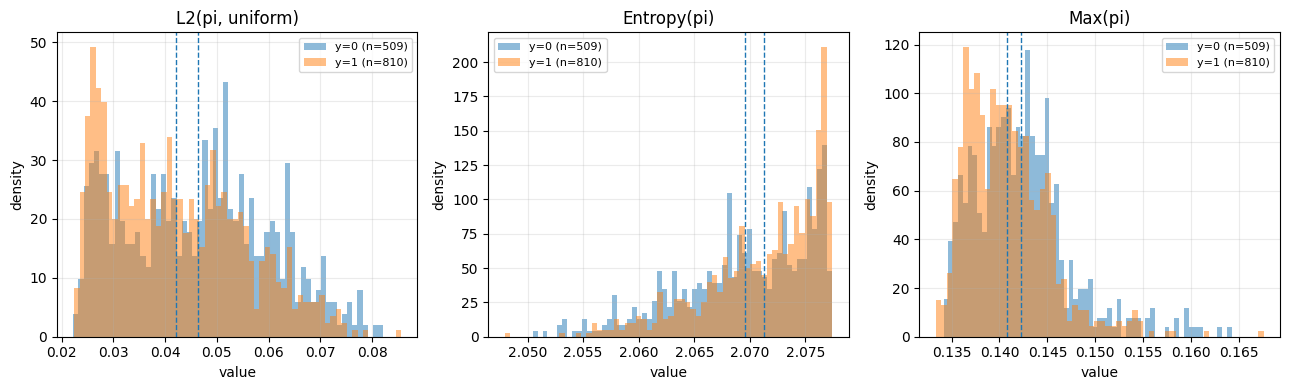

In [41]:
tgt_key, tgt_loader = get_loader_by_key(loaders, args2.target_data)
pis_t, ys_t, affs_t, names_t = collect_pi_and_affinity_for_one_source(model, tgt_loader, device)
summarize_pi_by_label(pis_t, ys_t, title_prefix=f"[TARGET:{tgt_key}]")


## Target-only coordinates

## Target K-medoids Stratification

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# robust summaries (scalar / vector)
# ----------------------------
def _trimmed_mean_1d(x, trim=0.1):
    x = np.asarray(x).reshape(-1)
    n = len(x)
    if n == 0:
        return np.nan
    k = int(np.floor(n * trim))
    xs = np.sort(x)
    if 2*k >= n:
        return np.median(xs)
    return xs[k:n-k].mean()

def _trimmed_mean_2d(X, trim=0.1):
    X = np.asarray(X)  # [n, d]
    n, d = X.shape
    k = int(np.floor(n * trim))
    Xs = np.sort(X, axis=0)  # sort over samples, per-dim
    if 2*k >= n:
        return np.median(Xs, axis=0)
    return Xs[k:n-k].mean(axis=0)

def robust_center(x, method="median", trim=0.1):
    x = np.asarray(x)
    if x.ndim == 1:
        return np.median(x) if method == "median" else _trimmed_mean_1d(x, trim=trim)
    else:
        return np.median(x, axis=0) if method == "median" else _trimmed_mean_2d(x, trim=trim)

def robust_spread_mad(x):
    x = np.asarray(x).reshape(-1)
    med = np.median(x)
    return np.median(np.abs(x - med))

# ----------------------------
# C1'') Δpi bar: center(pi)[high] - center(pi)[low]  (no medoid-1point)
# ----------------------------
def plot_delta_pi_kmedoids_robust(pis, phat, label, n_bins=5, seed=0, center="median", trim=0.1):
    pis = np.asarray(pis)
    phat = np.asarray(phat).reshape(-1)
    M = pis.shape[1]
    uniform = 1.0 / M

    clusters, medoids = stratify_kmedoids_1d(phat, n_bins=n_bins, seed=seed)

    pi_low  = robust_center(pis[clusters[0]],  method=center, trim=trim)
    pi_high = robust_center(pis[clusters[-1]], method=center, trim=trim)
    d = pi_high - pi_low

    fig, ax = plt.subplots(1, 1, figsize=(10, 3.2))
    ax.bar(np.arange(M), d)
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xticks(range(M))
    ax.set_xticklabels([str(i) for i in range(M)], fontsize=9)
    ax.set_yticks([])
    ax.grid(True, alpha=0.2)

    txt = f"label={label} | Δpi = {center}(high_bin) - {center}(low_bin) | n_low={len(clusters[0])}, n_high={len(clusters[-1])}"
    fig.text(0.01, 0.98, txt, va="top", ha="left", fontsize=10)
    fig.text(0.01, 0.02, f"uniform=1/M={uniform:.4f}", va="bottom", ha="left", fontsize=9)

    plt.tight_layout()
    plt.show()

# ----------------------------
# C2'') scatter + cluster centers line (median/trimmed mean), NOT medoid points
# ----------------------------
def plot_risk_scatter_metrics_kmedoids_robust(pis, phat, label, n_bins=5, seed=0, center="median", trim=0.1):
    pis = np.asarray(pis)
    phat = np.asarray(phat).reshape(-1)
    met = compute_pi_summaries(pis)

    clusters, _ = stratify_kmedoids_1d(phat, n_bins=n_bins, seed=seed)

    cx = np.array([robust_center(phat[idx], method=center, trim=trim) for idx in clusters])
    c_l2  = np.array([robust_center(met["l2"][idx],  method=center, trim=trim) for idx in clusters])
    c_ent = np.array([robust_center(met["ent"][idx], method=center, trim=trim) for idx in clusters])
    c_max = np.array([robust_center(met["max"][idx], method=center, trim=trim) for idx in clusters])

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
    keys = [("l2", "L2(pi, uniform)"), ("ent", "Entropy(pi)"), ("max", "Max(pi)")]
    centers = [c_l2, c_ent, c_max]

    for ax, (k, name), cv in zip(axes, keys, centers):
        ax.scatter(phat, met[k], s=14, alpha=0.35)
        ax.plot(cx, cv, marker="o")  # robust center line
        ax.set_xlabel("p_hat (risk)")
        ax.set_ylabel(name)
        ax.grid(True, alpha=0.25)

    fig.text(0.01, 0.98, f"label={label} | k-medoids bins + {center} centers", va="top", ha="left", fontsize=10)
    plt.tight_layout()
    plt.show()

# ----------------------------
# C3'') cluster curves: center ± MAD (robust spread)
# ----------------------------
def plot_cluster_curves_center_mad(pis, phat, label, n_bins=5, seed=0, center="median", trim=0.1):
    pis = np.asarray(pis)
    phat = np.asarray(phat).reshape(-1)
    met = compute_pi_summaries(pis)

    clusters, _ = stratify_kmedoids_1d(phat, n_bins=n_bins, seed=seed)
    x = np.arange(n_bins)

    def center_and_mad(arr):
        mu = np.array([robust_center(arr[idx], method=center, trim=trim) for idx in clusters])
        md = np.array([robust_spread_mad(arr[idx]) for idx in clusters])
        return mu, md

    l2_mu, l2_mad = center_and_mad(met["l2"])
    en_mu, en_mad = center_and_mad(met["ent"])
    mx_mu, mx_mad = center_and_mad(met["max"])

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
    axes[0].errorbar(x, l2_mu, yerr=l2_mad, marker="o", capsize=3)
    axes[1].errorbar(x, en_mu, yerr=en_mad, marker="o", capsize=3)
    axes[2].errorbar(x, mx_mu, yerr=mx_mad, marker="o", capsize=3)

    axes[0].set_ylabel("L2(pi, uniform)")
    axes[1].set_ylabel("Entropy(pi)")
    axes[2].set_ylabel("Max(pi)")
    for ax in axes:
        ax.set_xlabel(f"k-medoids bin (low → high)")
        ax.set_xticks(x)
        ax.grid(True, alpha=0.25)

    bin_risk = [robust_center(phat[idx], method=center, trim=trim) for idx in clusters]
    fig.text(0.01, 0.02, f"{center} bin risk: " + ", ".join([f"{v:.3f}" for v in bin_risk]),
             va="bottom", ha="left", fontsize=9)

    fig.text(0.01, 0.98, f"label={label} | k-medoids bins + {center}±MAD", va="top", ha="left", fontsize=10)
    plt.tight_layout()
    plt.show()

def run_stratification_viz_kmedoids_A(pis, ys, phats, label, n_bins=5, seed=0, center="median", trim=0.1):
    pis = np.asarray(pis)
    ys = np.asarray(ys).astype(int)
    phats = np.asarray(phats).reshape(-1)

    idx = np.where(ys == label)[0]
    if len(idx) < n_bins:
        print(f"[warn] label={label} too few samples: n={len(idx)} (n_bins={n_bins})")
        return

    pis_l = pis[idx]
    ph_l = phats[idx]

    plot_delta_pi_kmedoids_robust(pis_l, ph_l, label=label, n_bins=n_bins, seed=seed, center=center, trim=trim)
    plot_risk_scatter_metrics_kmedoids_robust(pis_l, ph_l, label=label, n_bins=n_bins, seed=seed, center=center, trim=trim)
    plot_cluster_curves_center_mad(pis_l, ph_l, label=label, n_bins=n_bins, seed=seed, center=center, trim=trim)


In [ ]:
for lab in [0, 1]:
    run_stratification_viz_kmedoids_A(pis_t, ys_t, phats_t, label=lab, n_bins=5, seed=0, center="median")
    # 필요하면 trimmed mean:
    # run_stratification_viz_kmedoids_A(..., center="trimmed", trim=0.1)


In [45]:
def stratify_by_risk(phat_sub, n_bins=5):
    """
    quantile 대신 '정렬 후 동일 개수 split' (ties 많아도 안정적)
    Returns: list of index arrays (local indices)
    """
    order = np.argsort(phat_sub)
    bins = np.array_split(order, n_bins)
    return bins

def top_edges_from_delta(delta, var_names, topk=10):
    V = delta.shape[0]
    # upper triangle only (i<j)
    vals = []
    for i in range(V):
        for j in range(i+1, V):
            vals.append((i, j, delta[i, j]))
    vals = sorted(vals, key=lambda x: abs(x[2]), reverse=True)[:topk]
    out = []
    for i, j, dv in vals:
        out.append((var_names[i], var_names[j], float(dv)))
    return out

def top_vars_from_delta(delta, var_names, topk=8):
    # 변수별 "증가" / "감소" 점수 (행/열 합)
    # symmetric라면 행합만으로도 충분하지만 그냥 abs/pos/neg 같이 뽑아줌
    d = delta.copy()
    np.fill_diagonal(d, 0.0)
    pos = np.maximum(d, 0.0).sum(axis=1)
    neg = np.minimum(d, 0.0).sum(axis=1)  # negative
    inc = sorted([(var_names[i], float(pos[i])) for i in range(len(var_names))], key=lambda x: x[1], reverse=True)[:topk]
    dec = sorted([(var_names[i], float(neg[i])) for i in range(len(var_names))], key=lambda x: x[1])[:topk]  # most negative
    return inc, dec

def delta_attention_by_label(ys, phats, atts, names, label, n_bins=5, topk_edges=12, topk_vars=8):
    mask = (ys == label)
    idx = np.where(mask)[0]
    if len(idx) < n_bins:
        raise ValueError(f"label={label} 샘플이 너무 적음: n={len(idx)}")

    ph = phats[idx]
    bins_local = stratify_by_risk(ph, n_bins=n_bins)

    # attention mean per bin
    mean_atts = []
    bin_info = []
    for b, loc_ids in enumerate(bins_local):
        gids = idx[loc_ids]  # global ids
        A = np.stack([atts[g] for g in gids], axis=0)  # [n,V,V]
        meanA = A.mean(axis=0)
        mean_atts.append(meanA)
        bin_info.append({
            "bin": b,
            "n": len(gids),
            "risk_mean": float(phats[gids].mean()),
            "risk_min": float(phats[gids].min()),
            "risk_max": float(phats[gids].max()),
        })

    low = 0
    high = n_bins - 1
    delta = mean_atts[high] - mean_atts[low]   # [V,V]

    # names (하나만 쓰기) : 보통 모든 샘플 동일
    var_names = names[idx[0]]
    if delta.shape[0] != len(var_names):
        # 혹시 mismatch면 attention 크기에 맞춰 자르기(최소한 터지진 않게)
        V = delta.shape[0]
        var_names = var_names[:V]

    # 출력용 랭킹
    edges = top_edges_from_delta(delta, var_names, topk=topk_edges)
    inc_vars, dec_vars = top_vars_from_delta(delta, var_names, topk=topk_vars)

    return delta, var_names, bin_info, edges, inc_vars, dec_vars

def plot_delta_attention(delta, var_names):
    V = delta.shape[0]
    vmax = float(np.abs(delta).max())
    vmax = max(vmax, 1e-9)

    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(delta, cmap="coolwarm", vmin=-vmax, vmax=vmax, aspect="auto")

    ax.set_xticks(range(V))
    ax.set_yticks(range(V))
    ax.set_xticklabels(var_names, rotation=90, fontsize=8)
    ax.set_yticklabels(var_names, fontsize=8)
    ax.tick_params(length=0)

    # colorbar 오른쪽에 고정
    plt.subplots_adjust(left=0.22, bottom=0.30, right=0.88, top=0.98)
    cax = fig.add_axes([0.90, 0.30, 0.02, 0.65])
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Δattention (high - low)")

    plt.show()


In [46]:
import numpy as np
import matplotlib.pyplot as plt

def _median_mad(x, axis=0):
    """
    x: [n, ...]
    return:
      med: [...]
      mad: [...]  (median absolute deviation around med)
    """
    med = np.median(x, axis=axis)
    mad = np.median(np.abs(x - np.expand_dims(med, axis=axis)), axis=axis)
    return med, mad


def plot_att_bins_2x5_and_delta_1x2(ys, phats, atts, names, n_bins=5, clip_q=(2, 98)):
    ys = np.asarray(ys).astype(int)
    phats = np.asarray(phats).reshape(-1)

    # atts: list([V,V]) -> [N,V,V]
    if isinstance(atts, (list, tuple)):
        atts = np.stack(atts, axis=0)
    else:
        atts = np.asarray(atts)

    assert atts.ndim == 3, f"atts shape must be [N,V,V], got {atts.shape}"
    N, V, _ = atts.shape

    # var names
    var_names = names[0] if isinstance(names, (list, tuple)) and len(names) > 0 else [str(i) for i in range(V)]
    if len(var_names) != V:
        var_names = [str(i) for i in range(V)]

    # ----------------------------
    # 1) label별 bin 만들고 (median, MAD) attention 계산
    # ----------------------------
    bins_info = {}  # lab -> list of dicts
    for lab in [0, 1]:
        idx_lab = np.where(ys == lab)[0]
        if len(idx_lab) == 0:
            bins_info[lab] = []
            continue

        order = idx_lab[np.argsort(phats[idx_lab])]  # low -> high
        chunks = np.array_split(order, n_bins)

        lab_bins = []
        for bi, ch in enumerate(chunks):
            if len(ch) == 0:
                lab_bins.append({
                    "bin": bi, "idx": ch, "n": 0,
                    "risk_med": np.nan, "risk_mad": np.nan,
                    "att_med": np.full((V, V), np.nan),
                    "att_mad": np.full((V, V), np.nan),
                })
            else:
                # risk: median ± MAD
                r = phats[ch]
                r_med = float(np.median(r))
                r_mad = float(np.median(np.abs(r - r_med)))

                # attention: median ± MAD (element-wise)
                A = atts[ch]  # [n,V,V]
                A_med, A_mad = _median_mad(A, axis=0)

                lab_bins.append({
                    "bin": bi, "idx": ch, "n": int(len(ch)),
                    "risk_med": r_med, "risk_mad": r_mad,
                    "att_med": A_med, "att_mad": A_mad,
                })
        bins_info[lab] = lab_bins

    # ----------------------------
    # 2) 공통 스케일(vmin/vmax): median attention들에 대해 percentile clip
    # ----------------------------
    med_mats = []
    for lab in [0, 1]:
        for b in bins_info.get(lab, []):
            if b["n"] > 0:
                med_mats.append(b["att_med"])
    if len(med_mats) == 0:
        print("모든 bin이 비었음.")
        return

    med_stack = np.stack(med_mats, axis=0)
    vmin = float(np.nanpercentile(med_stack, clip_q[0]))
    vmax = float(np.nanpercentile(med_stack, clip_q[1]))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = 0.0, 1.0

    # ----------------------------
    # Figure 1: 2 x n_bins (median attention)
    # ----------------------------
    fig, axes = plt.subplots(2, n_bins, figsize=(2.6*n_bins, 6.0))
    if n_bins == 1:
        axes = np.array(axes).reshape(2, 1)

    last_im = None
    for r, lab in enumerate([0, 1]):
        for c in range(n_bins):
            ax = axes[r, c]
            if c >= len(bins_info[lab]) or bins_info[lab][c]["n"] == 0:
                ax.axis("off")
                continue

            mat = bins_info[lab][c]["att_med"]
            last_im = ax.imshow(mat, vmin=vmin, vmax=vmax, aspect="equal")

            ax.set_xticks(range(V))
            ax.set_yticks(range(V))

            if r == 1:
                ax.set_xticklabels(var_names, rotation=45, ha="right", fontsize=8)
            else:
                ax.set_xticklabels([])

            if c == 0:
                ax.set_yticklabels(var_names, fontsize=8)
            else:
                ax.set_yticklabels([])

            ax.tick_params(length=0)

            n = bins_info[lab][c]["n"]
            r_med = bins_info[lab][c]["risk_med"]
            r_mad = bins_info[lab][c]["risk_mad"]
            ax.set_xlabel(f"bin{c}\n(n={n})\nmed={r_med:.3f}±{r_mad:.3f}", fontsize=9)

            if c == 0:
                ax.text(-0.22, 0.5, f"label={lab}",
                        transform=ax.transAxes, rotation=90,
                        va="center", ha="center", fontsize=11)

    fig.subplots_adjust(left=0.08, right=0.90, top=0.98, bottom=0.18, wspace=0.30, hspace=0.35)
    cax = fig.add_axes([0.92, 0.22, 0.015, 0.62])
    cb = fig.colorbar(last_im, cax=cax)
    cb.set_label("attention (median)")
    plt.show()

    # ----------------------------
    # Figure 2: 1 x 2 (delta: median(bin_high) - median(bin_low))
    # ----------------------------
    deltas = {}
    for lab in [0, 1]:
        if len(bins_info[lab]) < n_bins:
            continue
        b0 = bins_info[lab][0]["att_med"]
        bh = bins_info[lab][n_bins-1]["att_med"]
        if np.isnan(b0).any() or np.isnan(bh).any():
            continue
        deltas[lab] = (bh - b0)

    if len(deltas) == 0:
        print("delta를 만들 수 없음 (bin이 비었거나 NaN).")
        return

    dstack = np.stack([deltas[k] for k in deltas.keys()], axis=0)
    dabs = float(np.nanpercentile(np.abs(dstack), 99))
    dabs = max(dabs, 1e-9)
    dvmin, dvmax = -dabs, dabs

    fig2, axes2 = plt.subplots(1, 2, figsize=(7.0, 3.5))
    last_im2 = None
    for j, lab in enumerate([0, 1]):
        ax = axes2[j]
        if lab not in deltas:
            ax.axis("off")
            continue
        last_im2 = ax.imshow(deltas[lab], vmin=dvmin, vmax=dvmax, aspect="equal")
        ax.set_xticks(range(V)); ax.set_yticks(range(V))
        ax.set_xticklabels(var_names, rotation=45, ha="right", fontsize=8)
        if j == 0:
            ax.set_yticklabels(var_names, fontsize=8)
        else:
            ax.set_yticklabels([])
        ax.tick_params(length=0)
        ax.set_xlabel(f"Δatt (med bin{n_bins-1} - med bin0)\nlabel={lab}", fontsize=10)

    fig2.subplots_adjust(left=0.10, right=0.88, top=0.98, bottom=0.25, wspace=0.35)
    cax2 = fig2.add_axes([0.90, 0.30, 0.02, 0.55])
    cb2 = fig2.colorbar(last_im2, cax=cax2)
    cb2.set_label("Δ attention (median)")
    plt.show()


# =========================
# RUN (이미 ys_t, phats_t, atts_t, names_t 수집된 상태 가정)
# =========================
plot_att_bins_2x5_and_delta_1x2(ys_t, phats_t, atts_t, names_t, n_bins=5)


NameError: name 'phats_t' is not defined

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def _median_att_by_bins(phats_sub, atts_sub, n_bins=5):
    """
    phats_sub: [n]
    atts_sub:  [n, V, V]
    return: list of median attention per bin (len=n_bins), each [V,V]
    """
    order = np.argsort(phats_sub)                 # low -> high
    chunks = np.array_split(order, n_bins)

    meds = []
    for ch in chunks:
        if len(ch) == 0:
            meds.append(None)
        else:
            meds.append(np.median(atts_sub[ch], axis=0))  # [V,V]
    return meds

def compute_delta_median_for_label(ys, phats, atts, label, n_bins=5):
    """
    returns: delta [V,V], plus bin med risks
    """
    ys = np.asarray(ys).astype(int)
    phats = np.asarray(phats).reshape(-1)
    atts = np.asarray(atts)  # [N,V,V]

    idx = np.where(ys == label)[0]
    ph = phats[idx]
    A  = atts[idx]

    meds = _median_att_by_bins(ph, A, n_bins=n_bins)
    if meds[0] is None or meds[-1] is None:
        return None

    delta = meds[-1] - meds[0]

    # 참고용: bin별 risk median
    order = np.argsort(ph)
    chunks = np.array_split(order, n_bins)
    risk_meds = [float(np.median(ph[ch])) if len(ch)>0 else np.nan for ch in chunks]
    return delta, risk_meds

def permutation_test_delta_norm(ys, phats, atts, label, n_bins=5, n_perm=200, seed=0):
    """
    label 내부에서 phat만 셔플해서 null 분포 생성.
    비교 스칼라: Frobenius norm ||Δ||_F
    """
    rng = np.random.default_rng(seed)

    ys = np.asarray(ys).astype(int)
    phats = np.asarray(phats).reshape(-1)
    atts = np.asarray(atts)

    idx = np.where(ys == label)[0]
    ph = phats[idx].copy()
    A  = atts[idx]  # [n,V,V]

    # observed
    obs = _median_att_by_bins(ph, A, n_bins=n_bins)
    if obs[0] is None or obs[-1] is None:
        raise RuntimeError("빈 bin이 생겨 delta 계산 불가 (샘플 수/ n_bins 확인).")
    delta_obs = obs[-1] - obs[0]
    stat_obs = float(np.linalg.norm(delta_obs))   # ||Δ||_F

    # null
    stats_null = np.zeros(n_perm, dtype=float)
    for t in range(n_perm):
        ph_perm = ph.copy()
        rng.shuffle(ph_perm)  # ✅ label 내부에서 phat만 랜덤
        meds = _median_att_by_bins(ph_perm, A, n_bins=n_bins)
        d = meds[-1] - meds[0]
        stats_null[t] = float(np.linalg.norm(d))

    # p-value (one-sided: null >= obs)
    pval = (1.0 + np.sum(stats_null >= stat_obs)) / (n_perm + 1.0)

    # plot
    plt.figure(figsize=(6.2, 3.6))
    plt.hist(stats_null, bins=25, alpha=0.8)
    plt.axvline(stat_obs, linestyle="--", linewidth=2)
    plt.grid(True, alpha=0.25)
    plt.xlabel(r"$||\Delta||_F$  where  $\Delta=\mathrm{med}(bin_{high})-\mathrm{med}(bin_{low})$")
    plt.ylabel("count")
    plt.title(f"Permutation test (label={label}) | n_perm={n_perm} | p={pval:.4f}")
    plt.tight_layout()
    plt.show()

    return {
        "label": label,
        "delta_obs": delta_obs,
        "stat_obs": stat_obs,
        "stats_null": stats_null,
        "pval": pval,
    }

# -----------------------
# 사용 예시
# -----------------------
# atts_t가 list([V,V])라면, 한 번만 stack해서 넘기면 빨라짐
atts_np = np.stack(atts_t, axis=0) if isinstance(atts_t, (list, tuple)) else np.asarray(atts_t)

for lab in [0, 1]:
    out = permutation_test_delta_norm(
        ys_t, phats_t, atts_np,
        label=lab, n_bins=5, n_perm=300, seed=42
    )
    print(f"[label={lab}] ||Δ||_F={out['stat_obs']:.4f}  p={out['pval']:.4f}")


NameError: name 'atts_t' is not defined

Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 791
Validation data size: 264
Test data size: 264

===== TARGET: Medicaldataset (thr=0.5) =====

[Entropy(pi)]
  TN (y=0,yhat=0): n= 413 | mean=2.0689 | med=2.0695 | std=0.0061
  FP (y=0,yhat=1): n=  96 | mean=2.0721 | med=2.0727 | std=0.0040
  FN (y=1,yhat=0): n= 386 | mean=2.0704 | med=2.0711 | std=0.0056
  TP (y=1,yhat=1): n= 424 | mean=2.0721 | med=2.0735 | std=0.0046

[Max(pi)]
  TN (y=0,yhat=0): n= 413 | mean=0.1428 | med=0.1424 | std=0.0053
  FP (y=0,yhat=1): n=  96 | mean=0.1401 | med=0.1399 | std=0.0032
  FN (y=1,yhat=0): n= 386 | mean=0.1417 | med=0.1409 | std=0.0048
  TP (y=1,yhat=1): n= 424 | mean=0.1399 | med=0.1395 | std=0.0037

[L2(pi, uniform)]
  TN (y=0,yhat=0): n= 413 | mean=0.0477 | med=0.0486 | std=0.0144
  FP (y=0,yhat=1): n=  96 | mean=0.0404 | med=0.0405 |

/tmp/ipykernel_3362805/1111169249.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=[g.split()[0] for g in gnames], showfliers=False)
/tmp/ipykernel_3362805/1111169249.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=[g.split()[0] for g in gnames], showfliers=False)
/tmp/ipykernel_3362805/1111169249.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=[g.split()[0] for g in gnames], showfliers=False)


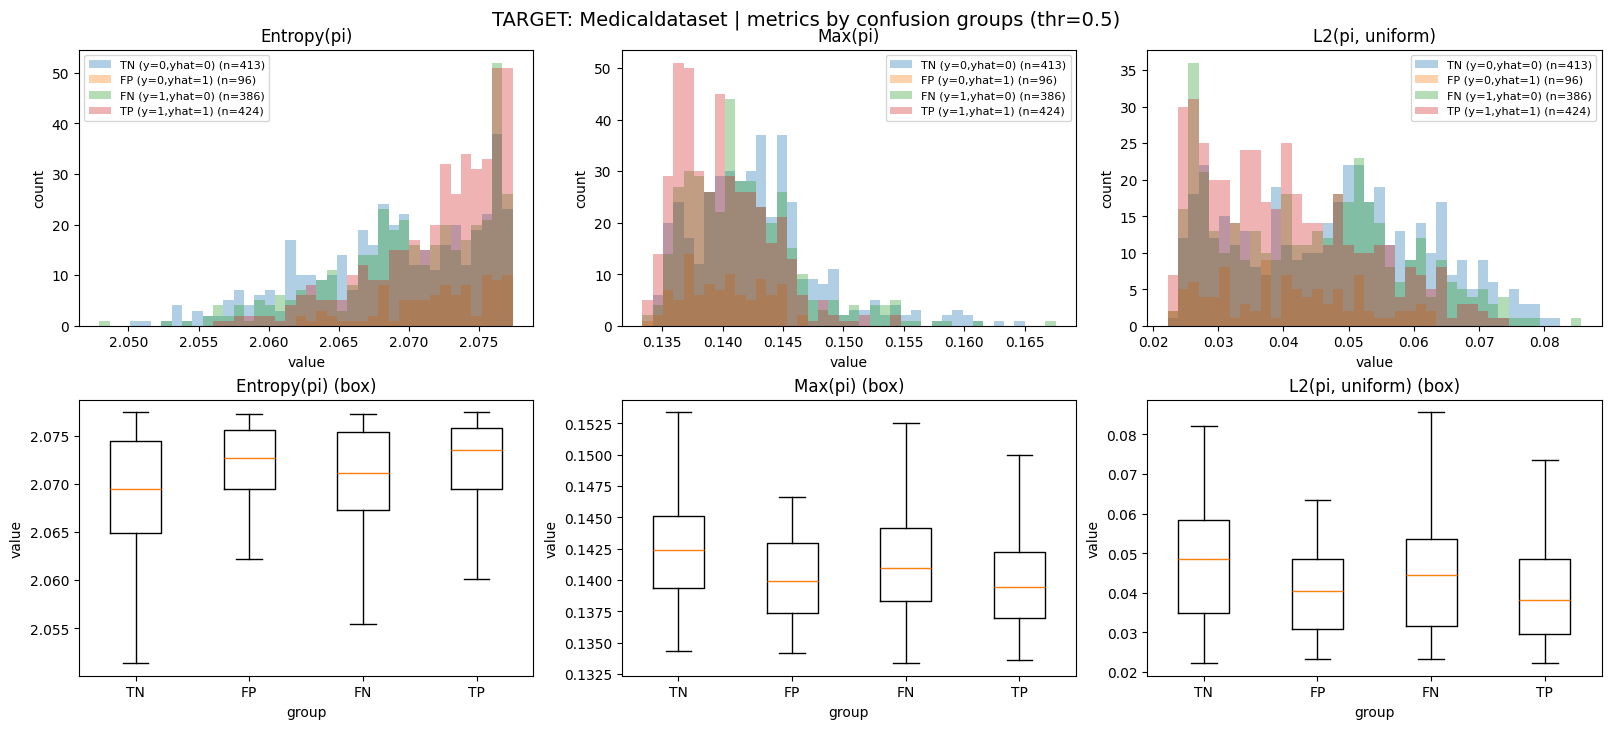

Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 550
Validation data size: 184
Test data size: 184

===== SOURCE: heart (thr=0.5) =====

[Entropy(pi)]
  TN (y=0,yhat=0): n= 350 | mean=2.0685 | med=2.0683 | std=0.0049
  FP (y=0,yhat=1): n=  60 | mean=2.0736 | med=2.0750 | std=0.0050
  FN (y=1,yhat=0): n=  66 | mean=2.0710 | med=2.0705 | std=0.0053
  TP (y=1,yhat=1): n= 442 | mean=2.0740 | med=2.0750 | std=0.0042

[Max(pi)]
  TN (y=0,yhat=0): n= 350 | mean=0.1431 | med=0.1422 | std=0.0061
  FP (y=0,yhat=1): n=  60 | mean=0.1371 | med=0.1354 | std=0.0056
  FN (y=1,yhat=0): n=  66 | mean=0.1410 | med=0.1402 | std=0.0068
  TP (y=1,yhat=1): n= 442 | mean=0.1368 | med=0.1357 | std=0.0047

[L2(pi, uniform)]
  TN (y=0,yhat=0): n= 350 | mean=0.0491 | med=0.0509 | std=0.0126
  FP (y=0,yhat=1): n=  60 | mean=0.0339 | med=0.0326 | std=0.0153
  FN (

/tmp/ipykernel_3362805/1111169249.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=[g.split()[0] for g in gnames], showfliers=False)
/tmp/ipykernel_3362805/1111169249.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=[g.split()[0] for g in gnames], showfliers=False)
/tmp/ipykernel_3362805/1111169249.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=[g.split()[0] for g in gnames], showfliers=False)


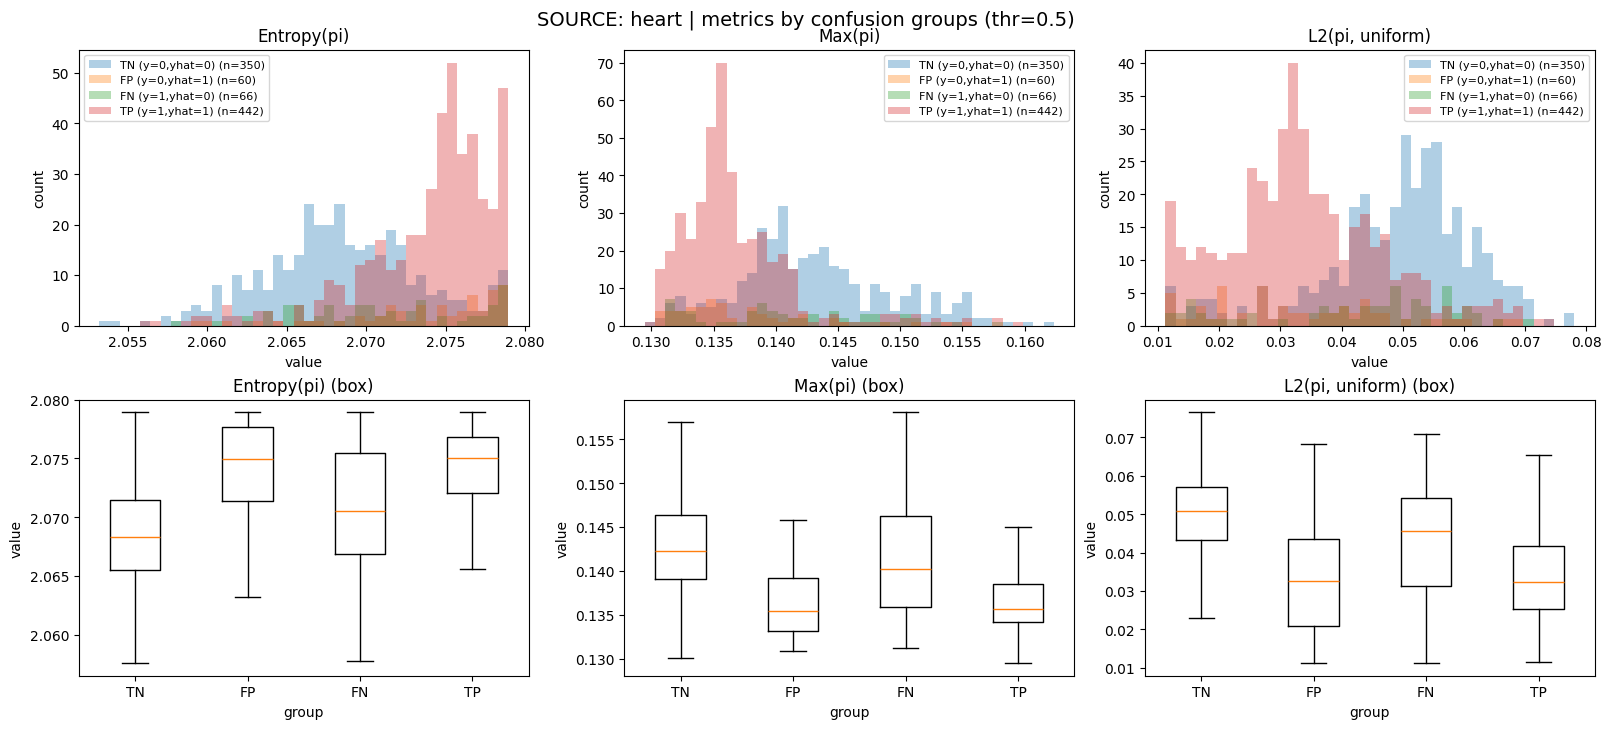

({'Entropy(pi)': array([2.0756   , 2.064249 , 2.0701587, 2.0646114, 2.0728135, 2.0693069,
         2.0728052, 2.0763829, 2.0648239, 2.0753477, 2.068769 , 2.0729666,
         2.078872 , 2.0631661, 2.0699077, 2.0679293, 2.0748777, 2.0695372,
         2.075924 , 2.074523 , 2.0658593, 2.074738 , 2.0736535, 2.078528 ,
         2.074512 , 2.0763223, 2.067074 , 2.0764027, 2.073237 , 2.0717454,
         2.0784926, 2.0648966, 2.0664735, 2.0661445, 2.0779643, 2.0671654,
         2.066805 , 2.0686896, 2.076375 , 2.072535 , 2.0732596, 2.0717192,
         2.0709543, 2.0732348, 2.073833 , 2.0604565, 2.0769825, 2.0608437,
         2.0650818, 2.0670872, 2.075674 , 2.0788455, 2.070089 , 2.0594556,
         2.066196 , 2.070344 , 2.0787442, 2.0667868, 2.0782535, 2.0656412,
         2.0691123, 2.0657036, 2.0681496, 2.0732636, 2.0741067, 2.0731993,
         2.0743833, 2.0771904, 2.0604799, 2.0760677, 2.0735974, 2.0672424,
         2.0721736, 2.0741289, 2.0736835, 2.078474 , 2.066679 , 2.0697744,
         2

In [48]:
import numpy as np
import torch
from torch.utils.data import ConcatDataset, DataLoader
import matplotlib.pyplot as plt

# -------------------------
# 0) small utils
# -------------------------
def _to_numpy_1d(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().view(-1).numpy()
    else:
        x = np.asarray(x).reshape(-1)
    return x

def _ensure_tensor_2d(x, device=None):
    if torch.is_tensor(x):
        t = x
    else:
        t = torch.as_tensor(x)
    if t.dim() == 1:
        t = t.unsqueeze(0)
    if device is not None:
        t = t.to(device)
    return t

# -------------------------
# 1) make loader (concat tr/va/te)
# -------------------------
def make_concat_loader(args, dataset_key, batch_size=32, shuffle=False):
    res = prepare_embedding_dataloaders(args, dataset_key)
    tr, va, te = res["loaders"]
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

# -------------------------
# 2) pi metrics
# -------------------------
def compute_pi_metrics(pis, eps=1e-12):
    """
    pis: [N, K] torch or np
    returns dict of numpy arrays: entropy, max, l2u
    """
    pi = _ensure_tensor_2d(pis).float()
    # normalize just in case (should already sum to 1)
    pi = pi / (pi.sum(dim=1, keepdim=True) + eps)

    K = pi.size(1)
    uni = torch.full((K,), 1.0 / K, device=pi.device)

    entropy = -(pi * (pi + eps).log()).sum(dim=1)              # [N]
    maxv    = pi.max(dim=1).values                             # [N]
    l2u     = torch.norm(pi - uni.unsqueeze(0), dim=1, p=2)    # [N]

    return {
        "Entropy(pi)": _to_numpy_1d(entropy),
        "Max(pi)": _to_numpy_1d(maxv),
        "L2(pi, uniform)": _to_numpy_1d(l2u),
    }

# -------------------------
# 3) confusion split
# -------------------------
def confusion_groups(ys, phats, thr=0.5):
    y = _to_numpy_1d(ys).astype(int)
    p = _to_numpy_1d(phats).astype(float)
    yhat = (p >= thr).astype(int)

    groups = {}
    groups["TN (y=0,yhat=0)"] = np.where((y==0) & (yhat==0))[0]
    groups["FP (y=0,yhat=1)"] = np.where((y==0) & (yhat==1))[0]
    groups["FN (y=1,yhat=0)"] = np.where((y==1) & (yhat==0))[0]
    groups["TP (y=1,yhat=1)"] = np.where((y==1) & (yhat==1))[0]
    return groups

def print_group_summary(metrics, groups, title=""):
    print(f"\n===== {title} =====")
    for mname, arr in metrics.items():
        print(f"\n[{mname}]")
        for gname, idx in groups.items():
            if len(idx) == 0:
                print(f"  {gname}: n=0")
                continue
            v = arr[idx]
            print(f"  {gname}: n={len(idx):4d} | mean={v.mean():.4f} | med={np.median(v):.4f} | std={v.std(ddof=1):.4f}")

# -------------------------
# 4) plotting: hist + box
# -------------------------
def plot_metrics_by_confusion(pis, ys, phats, title, thr=0.5, bins=40):
    metrics = compute_pi_metrics(pis)
    groups  = confusion_groups(ys, phats, thr=thr)

    # print summary first (이게 제일 잘 보임)
    print_group_summary(metrics, groups, title=f"{title} (thr={thr})")

    # figure: 2 rows x 3 cols (top=hist, bottom=box)
    fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
    fig.suptitle(f"{title} | metrics by confusion groups (thr={thr})", y=1.02, fontsize=14)

    gnames = list(groups.keys())

    for j, (mname, arr) in enumerate(metrics.items()):
        # --- (A) hist overlay
        ax = axes[0, j]
        # common range for fair compare
        vmin, vmax = np.min(arr), np.max(arr)
        for gname in gnames:
            idx = groups[gname]
            if len(idx) == 0:
                continue
            ax.hist(arr[idx], bins=bins, range=(vmin, vmax), alpha=0.35, label=f"{gname} (n={len(idx)})")
        ax.set_title(mname)
        ax.set_xlabel("value")
        ax.set_ylabel("count")
        ax.legend(fontsize=8)

        # --- (B) boxplot (훨씬 비교가 쉬움)
        ax2 = axes[1, j]
        data = [arr[groups[g]] for g in gnames]
        ax2.boxplot(data, labels=[g.split()[0] for g in gnames], showfliers=False)
        ax2.set_title(f"{mname} (box)")
        ax2.set_xlabel("group")
        ax2.set_ylabel("value")

    plt.show()
    return metrics, groups

# -------------------------
# 5) run: TARGET + SOURCE(heart only)
# -------------------------
# (1) TARGET
tgt_key = args2.target_data
tgt_loader = make_concat_loader(args2, tgt_key, batch_size=32, shuffle=False)
pis_t, ys_t, phats_t = collect_pi_y_phat(model, tgt_loader, device)

plot_metrics_by_confusion(pis_t, ys_t, phats_t, title=f"TARGET: {tgt_key}", thr=0.5)

# (2) SOURCE: heart only
src_key = "heart"   # <- 여기만 heart로 고정
src_loader = make_concat_loader(args2, src_key, batch_size=32, shuffle=False)
pis_s, ys_s, phats_s = collect_pi_y_phat(model, src_loader, device)

plot_metrics_by_confusion(pis_s, ys_s, phats_s, title=f"SOURCE: {src_key}", thr=0.5)
